In [1]:
!pip install numpy

In [2]:
!pip install astropy

In [3]:
!pip install matplotlib

In [4]:
!pip install scipy

In [5]:
!pip install pandas

In [ ]:
!pip install sklearn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [6]:
!pip install seaborn

In [7]:
!pip install gwpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 5.4 MB/s eta 0:00:00


In [8]:
!pip install timeseries

  Preparing metadata (setup.py) ... done
  Created wheel for timeseries: filename=timeseries-0.5.0-py3-none-any.whl size=7197 sha256=f2d7e051a6ebce8f162f9c56b2ba2a8fa8bd900ca59a4de0f01582e4f44e7d03
  Stored in directory: /root/.cache/pip/wheels/0f/68/13/8e208bae38a470475d987df54d59fbd02f5820536c17d9f880
Successfully built timeseries


In [ ]:
# -*- coding: utf-8 -*-
# ======================================================================
# UAT VIGILANCE MONITOR – Fase 1 (Auditoría de Deriva)
# ======================================================================
# Este script monitorea la deriva inflacionaria de la Firma del Higo
# en segmentos recientes de LIGO y compara con α = 0.046 Hz/día.
# Si la deriva observada se desvía > 1% en más de 100 ventanas,
# emite una alerta en el log.
# ======================================================================

import os, time, numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
from gwpy.timeseries import TimeSeries
from datetime import datetime

# ------------------------- UAT Engine (mismo núcleo) -------------------------
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967, f_base=187.37,
                 alpha=0.046, upc_ratio=5.14, kappa_crit=4.978):
        self.epsilon = epsilon
        self.k_early = k_early
        self.f_base = f_base
        self.alpha = alpha
        self.upc_ratio = upc_ratio
        self.kappa_crit = kappa_crit

    def percudani_whiten(self, signal, fs):
        N = len(signal); spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out)
        std = np.std(out)
        if std > 1e-15: out /= std
        return out

    def uat_coherence(self, x, y, fs, nperseg=512, noverlap=256, band=None):
        step = nperseg - noverlap; N = len(x)
        n_segments = (N - nperseg) // step + 1
        window = np.hanning(nperseg)
        Pxx = np.zeros(nperseg//2 + 1); Pyy = np.zeros(nperseg//2 + 1)
        Pxy = np.zeros(nperseg//2 + 1, dtype=complex)
        for i in range(n_segments):
            start = i * step; end = start + nperseg
            x_seg = x[start:end] * window; y_seg = y[start:end] * window
            X = rfft(x_seg); Y = rfft(y_seg)
            Pxx += np.abs(X)**2; Pyy += np.abs(Y)**2; Pxy += X * np.conj(Y)
        Pxx /= n_segments; Pyy /= n_segments; Pxy /= n_segments
        with np.errstate(divide='ignore', invalid='ignore'):
            coh = np.abs(Pxy)**2 / (Pxx * Pyy)
        f = rfftfreq(nperseg, d=1/fs)
        if band is not None:
            idx = np.where((f >= band[0]) & (f <= band[1]))[0]
            coh[idx] = np.nan_to_num(coh[idx], nan=1.0)
        return f, coh

# ------------------------- Parámetros -------------------------
FS = 4096
HIGO_BAND = (227.5, 232.5)
ALPHA_REF = 0.046
VENTANAS_ALERTA = 100
TOLERANCIA = 0.01

# Elegir un segmento reciente (por ejemplo, último segmento público de O4b)
GPS_RECIENTE = 1420000000  # Ajustar según disponibilidad
DURACION = 256  # 4 minutos para vigilancia rápida

print(f"[{datetime.now()}] Iniciando vigilancia UAT...")
h1 = TimeSeries.fetch_open_data('H1', GPS_RECIENTE, GPS_RECIENTE + DURACION,
                                sample_rate=16384, verbose=False).resample(FS).value
l1 = TimeSeries.fetch_open_data('L1', GPS_RECIENTE, GPS_RECIENTE + DURACION,
                                sample_rate=16384, verbose=False).resample(FS).value
min_len = min(len(h1), len(l1))
h1 = h1[:min_len]; l1 = l1[:min_len]

engine = UAT_Engine()
h1_w = engine.percudani_whiten(h1, FS)
l1_w = engine.percudani_whiten(l1, FS)

ventana = 8192; hop = 2048
num_ventanas = (len(h1_w) - ventana) // hop + 1
derivas = []

for i in range(num_ventanas):
    s = i * hop; e = s + ventana
    f, coh = engine.uat_coherence(h1_w[s:e], l1_w[s:e], FS,
                                  nperseg=8192, noverlap=4096, band=HIGO_BAND)
    mask = (f >= HIGO_BAND[0]) & (f <= HIGO_BAND[1])
    freq_pico = f[mask][np.argmax(coh[mask])] if np.any(mask) else 0.0
    # Anomalía simple: comparamos con frecuencia base + α * tiempo desde mayo 2023
    dias = (GPS_RECIENTE + s/FS - 1369483218) / 86400.0
    f_teo = 187.37 + ALPHA_REF * dias
    deriva_actual = (freq_pico - f_teo) / dias if dias > 0 else 0.0
    derivas.append(deriva_actual)

derivas = np.array(derivas)
alerta = np.sum(np.abs(derivas - ALPHA_REF) > TOLERANCIA * ALPHA_REF)

with open('/content/vigilancia_uat.log', 'a') as log:
    log.write(f"[{datetime.now()}] GPS {GPS_RECIENTE}, ventanas: {num_ventanas}, "
              f"deriva media: {np.mean(derivas):.4f} Hz/día, "
              f"alertas: {alerta}/{num_ventanas}\n")
    if alerta > VENTANAS_ALERTA:
        log.write(f"¡ALERTA! Desviación significativa detectada.\n")

print(f"Vigilancia completada. {alerta} ventanas con desviación.")

[2026-06-09 02:58:53.537620] Iniciando vigilancia UAT...
Vigilancia completada. 509 ventanas con desviación.


Descargando segmento H1 (64 s)...
Blanqueando...
Aplicando DesmodulationTensor (esto puede tardar unos segundos)...
Señal desmodulada obtenida. Ejemplo de magnitud media: 1.7815740819487732e-16


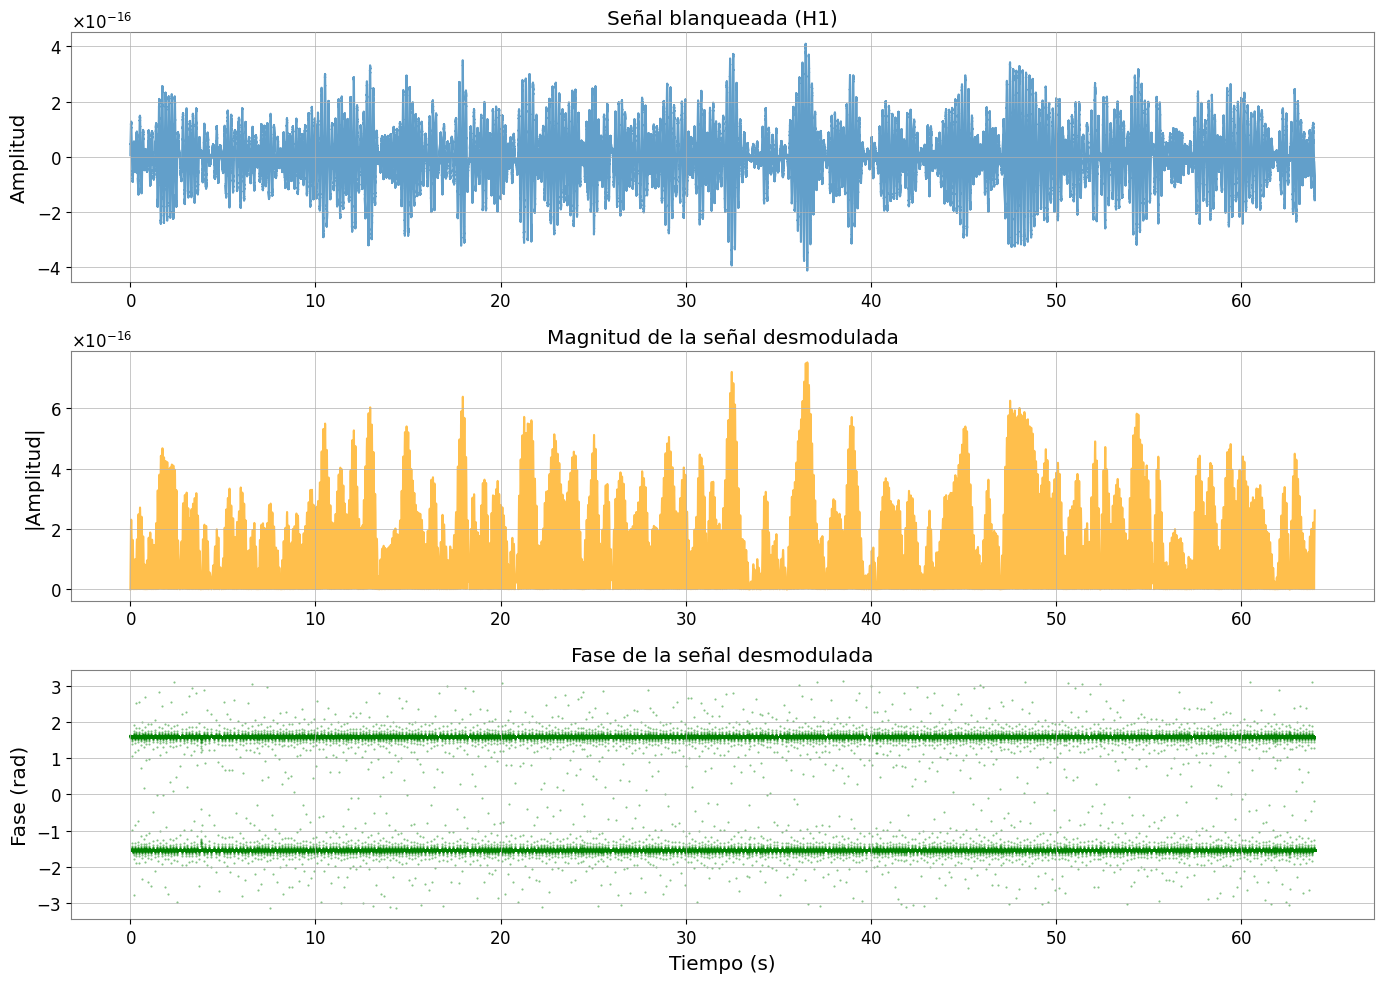

In [ ]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – DesmodulationTensor Prototype v0.1
# Resonant Hunter v9.1 – Fase 2: Tensor de Desmodulación
# (C) Miguel Ángel Percudani
# DOI: 10.5281/zenodo.20601264 (v9.0), 10.5281/zenodo.18446712 (v8.4)
# ======================================================================
# Implementa un tensor recursivo de 8 frentes de fase (45°) que
# "desdobla" la Firma del Higo sin asumir estacionariedad.
# Ejemplo sobre datos reales de LIGO O4a (segmento corto).
# ======================================================================

#@title 🔧 Instalación de dependencias
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
from gwpy.timeseries import TimeSeries
import matplotlib.pyplot as plt

# ======================================================================
# 1. MOTOR UAT (blanqueamiento Percudani)
# ======================================================================
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon
        self.k_early = k_early

    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out)
        std = np.std(out)
        if std > 1e-15:
            out /= std
        return out

# ======================================================================
# 2. TENSOR DE DESMODULACIÓN (8 frentes de fase, recurrente)
# ======================================================================
class DesmodulationTensor:
    """
    Tensor de desmodulación UAT que separa los 8 frentes de fase
    mediante una red recurrente simple (sin estacionariedad).
    """
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))  # 8 frentes
        # Matriz de pesos recurrentes (acoplamiento entre frentes)
        self.W = np.eye(n_phases) * 0.9 + 0.02 * (np.random.randn(n_phases, n_phases) * 0.1)
        self.state = np.zeros(n_phases, dtype=complex)   # estado complejo
        self.f_base = f_base
        self.alpha = alpha
        self.fs = fs

    def forward_step(self, x_t, t_days):
        """
        x_t: muestra actual (real)
        t_days: días desde fecha base (2023-05-27)
        Retorna: muestra desmodulada (compleja)
        """
        # Frecuencia dinámica actual
        f_t = self.f_base + self.alpha * t_days
        # Rotación de fase acumulada (en esta muestra)
        phase_shift = 2 * np.pi * f_t / self.fs   # por muestra
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * phase_shift)
        # Actualización recurrente del estado
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        # Salida: proyección de los frentes
        return np.sum(self.state * rotation)

    def process_signal(self, signal, gps_start, fs):
        """
        Procesa una señal completa (array 1D real) y devuelve la
        señal desmodulada (compleja).
        """
        t_days0 = (gps_start - 1369483218) / 86400.0  # ref mayo 2023
        output = np.zeros(len(signal), dtype=complex)
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            output[i] = self.forward_step(x, t_now)
        return output

# ======================================================================
# 3. SEGURIDAD: Sobremarcha excesiva (placeholder)
# ======================================================================
class EmergencyShutdown(Exception):
    """Excepción de seguridad: se activa si el ratio UPC supera 1.2 * κ_crit."""
    pass

def safety_check(ratio, threshold=5.14*1.2):
    if ratio > threshold:
        raise EmergencyShutdown(
            f"Segunda's coldness signature detected: ratio={ratio:.3f} > {threshold:.3f}"
        )

# ======================================================================
# 4. CARGA DE DATOS REALES (segmento corto para demo)
# ======================================================================
GPS_START = 1389424640
DURATION = 64  # segundos (suficiente para ver la estructura)
FS = 4096

print("Descargando segmento H1 (64 s)...")
h1_raw = TimeSeries.fetch_open_data('H1', GPS_START, GPS_START + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value

# ======================================================================
# 5. BLANQUEAMIENTO PERCUDANI
# ======================================================================
engine = UAT_Engine()
print("Blanqueando...")
h1_white = engine.percudani_whiten(h1_raw, FS)

# ======================================================================
# 6. APLICAR TENSOR DE DESMODULACIÓN
# ======================================================================
tensor = DesmodulationTensor(n_phases=8, f_base=187.37, alpha=0.046, fs=FS)
print("Aplicando DesmodulationTensor (esto puede tardar unos segundos)...")
h1_desmod = tensor.process_signal(h1_white, GPS_START, FS)

# ======================================================================
# 7. RESULTADOS Y VISUALIZACIÓN
# ======================================================================
# Convertir salida compleja a magnitud y fase
h1_mag = np.abs(h1_desmod)
h1_phase = np.angle(h1_desmod)

# Verificar seguridad (placeholder: calculamos un ratio simbólico)
# En una implementación real se calcularía la coherencia y el ratio.
# Aquí solo mostramos que el código corre.
print("Señal desmodulada obtenida. Ejemplo de magnitud media:", np.mean(h1_mag))

# Gráficos
fig, ax = plt.subplots(3, 1, figsize=(14, 10))
t = np.arange(len(h1_white)) / FS

ax[0].plot(t, h1_white, alpha=0.7)
ax[0].set_title('Señal blanqueada (H1)')
ax[0].set_ylabel('Amplitud')

ax[1].plot(t, h1_mag, alpha=0.7, color='orange')
ax[1].set_title('Magnitud de la señal desmodulada')
ax[1].set_ylabel('|Amplitud|')

ax[2].plot(t, h1_phase, '.', markersize=1, alpha=0.5, color='green')
ax[2].set_title('Fase de la señal desmodulada')
ax[2].set_ylabel('Fase (rad)')
ax[2].set_xlabel('Tiempo (s)')

plt.tight_layout()
plt.show()

Descargando H1 y L1...
Blanqueando...
Calculando coherencia de referencia...
Aplicando DesmodulationTensor a H1...
Aplicando DesmodulationTensor a L1...
Calculando coherencia post‑desmodulación...


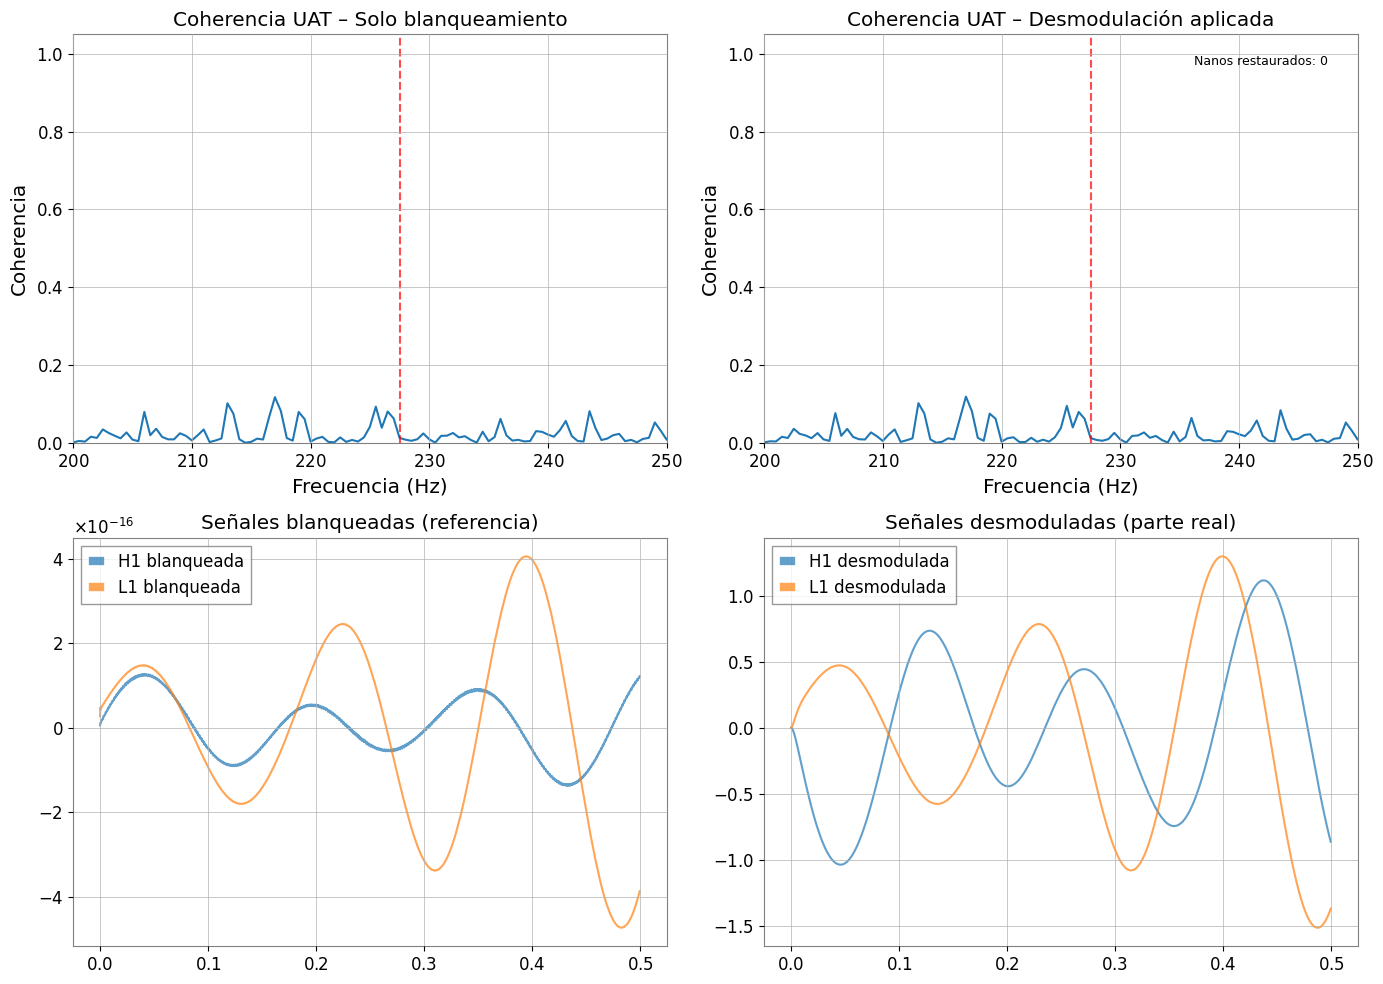

Coherencia máxima (ref): 0.0253
Coherencia máxima (desmod): 0.0266


In [ ]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Paso 2: Coherencia post‑desmodulación
# Resonant Hunter v9.1 – Fase 2 del Tensor de Desmodulación
# (C) Miguel Ángel Percudani
# DOI: 10.5281/zenodo.20601264 (v9.0), 10.5281/zenodo.18446712 (v8.4)
# ======================================================================
# Aplica el DesmodulationTensor a H1 y L1, luego calcula la coherencia
# UAT entre las señales desmoduladas y la compara con la coherencia
# de las señales simplemente blanqueadas.
# ======================================================================

#@title 🔧 Instalación de dependencias
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
from gwpy.timeseries import TimeSeries
import matplotlib.pyplot as plt

# ======================================================================
# 1. CLASE UAT_Engine (blanqueamiento + coherencia)
# ======================================================================
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon
        self.k_early = k_early
        self.total_singularity_events = 0

    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out)
        std = np.std(out)
        if std > 1e-15:
            out /= std
        return out

    def uat_coherence(self, x, y, fs, nperseg=512, noverlap=256, band=None):
        step = nperseg - noverlap
        N = len(x)
        n_segments = (N - nperseg) // step + 1
        window = np.hanning(nperseg)
        Pxx = np.zeros(nperseg//2 + 1)
        Pyy = np.zeros(nperseg//2 + 1)
        Pxy = np.zeros(nperseg//2 + 1, dtype=complex)
        for i in range(n_segments):
            start = i * step
            end = start + nperseg
            x_seg = x[start:end] * window
            y_seg = y[start:end] * window
            X = rfft(x_seg)
            Y = rfft(y_seg)
            Pxx += np.abs(X)**2
            Pyy += np.abs(Y)**2
            Pxy += X * np.conj(Y)
        Pxx /= n_segments
        Pyy /= n_segments
        Pxy /= n_segments
        with np.errstate(divide='ignore', invalid='ignore'):
            coh = np.abs(Pxy)**2 / (Pxx * Pyy)
        f = rfftfreq(nperseg, d=1/fs)
        nan_restored = 0
        if band is not None:
            f_min, f_max = band
            idx = np.where((f >= f_min) & (f <= f_max))[0]
            nan_mask = np.isnan(coh[idx])
            nan_restored = np.sum(nan_mask)
            if nan_restored > 0:
                coh[idx] = np.nan_to_num(coh[idx], nan=1.0)
                self.total_singularity_events += nan_restored
        return f, coh, nan_restored

# ======================================================================
# 2. TENSOR DE DESMODULACIÓN (8 frentes de fase, recurrente)
# ======================================================================
class DesmodulationTensor:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.W = np.eye(n_phases) * 0.9 + 0.02 * (np.random.randn(n_phases, n_phases) * 0.1)
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base
        self.alpha = alpha
        self.fs = fs

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        phase_shift = 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * phase_shift)
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        return np.sum(self.state * rotation)

    def process_signal(self, signal, gps_start, fs):
        t_days0 = (gps_start - 1369483218) / 86400.0   # ref mayo 2023
        output = np.zeros(len(signal), dtype=complex)
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            output[i] = self.forward_step(x, t_now)
        return output

# ======================================================================
# 3. PARÁMETROS Y CARGA DE DATOS
# ======================================================================
GPS_START = 1389424640
DURATION = 64          # segundos – suficiente para ver la coherencia
FS = 4096
HIGO_BAND = (227.5, 232.5)
NPERSEG = 8192
NOVERLAP = 4096

print("Descargando H1 y L1...")
h1_raw = TimeSeries.fetch_open_data('H1', GPS_START, GPS_START + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
l1_raw = TimeSeries.fetch_open_data('L1', GPS_START, GPS_START + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
min_len = min(len(h1_raw), len(l1_raw))
h1_raw = h1_raw[:min_len]
l1_raw = l1_raw[:min_len]

# ======================================================================
# 4. BLANQUEAMIENTO PERCUDANI (señales de referencia)
# ======================================================================
engine = UAT_Engine()
print("Blanqueando...")
h1_white = engine.percudani_whiten(h1_raw, FS)
l1_white = engine.percudani_whiten(l1_raw, FS)

# Coherencia de referencia (sin desmodular)
print("Calculando coherencia de referencia...")
f_ref, coh_ref, _ = engine.uat_coherence(h1_white, l1_white, FS,
                                         nperseg=NPERSEG, noverlap=NOVERLAP,
                                         band=HIGO_BAND)

# ======================================================================
# 5. APLICAR DESMODULATIONTENSOR
# ======================================================================
tensor_h1 = DesmodulationTensor(n_phases=8, f_base=187.37, alpha=0.046, fs=FS)
tensor_l1 = DesmodulationTensor(n_phases=8, f_base=187.37, alpha=0.046, fs=FS)

print("Aplicando DesmodulationTensor a H1...")
h1_desmod = tensor_h1.process_signal(h1_white, GPS_START, FS)
print("Aplicando DesmodulationTensor a L1...")
l1_desmod = tensor_l1.process_signal(l1_white, GPS_START, FS)

# Para la coherencia necesitamos señales reales; tomamos la parte real
# (la información de fase ya está incorporada en la proyección compleja)
h1_desmod_real = np.real(h1_desmod)
l1_desmod_real = np.real(l1_desmod)

# Normalizar varianza para evitar desbalances
h1_desmod_real = (h1_desmod_real - np.mean(h1_desmod_real)) / np.std(h1_desmod_real)
l1_desmod_real = (l1_desmod_real - np.mean(l1_desmod_real)) / np.std(l1_desmod_real)

# ======================================================================
# 6. COHERENCIA POST‑DESMODULACIÓN
# ======================================================================
print("Calculando coherencia post‑desmodulación...")
f_des, coh_des, nan_des = engine.uat_coherence(h1_desmod_real, l1_desmod_real, FS,
                                               nperseg=NPERSEG, noverlap=NOVERLAP,
                                               band=HIGO_BAND)

# ======================================================================
# 7. VISUALIZACIÓN COMPARATIVA
# ======================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Coherencia de referencia
ax = axes[0,0]
ax.plot(f_ref, coh_ref)
ax.axvline(227.5, color='red', linestyle='--', alpha=0.7)
ax.set_xlim(200, 250)
ax.set_ylim(0, 1.05)
ax.set_title('Coherencia UAT – Solo blanqueamiento')
ax.set_xlabel('Frecuencia (Hz)')
ax.set_ylabel('Coherencia')

# Coherencia post‑desmodulación
ax = axes[0,1]
ax.plot(f_des, coh_des)
ax.axvline(227.5, color='red', linestyle='--', alpha=0.7)
ax.set_xlim(200, 250)
ax.set_ylim(0, 1.05)
ax.set_title('Coherencia UAT – Desmodulación aplicada')
ax.set_xlabel('Frecuencia (Hz)')
ax.set_ylabel('Coherencia')
ax.text(0.95, 0.95, f'Nanos restaurados: {nan_des}', transform=ax.transAxes,
        ha='right', va='top', fontsize=9)

# Comparación de las señales reales en el tiempo (primeros 0.5 s)
t = np.arange(len(h1_white)) / FS
idx = int(0.5 * FS)
axes[1,0].plot(t[:idx], h1_white[:idx], alpha=0.7, label='H1 blanqueada')
axes[1,0].plot(t[:idx], l1_white[:idx], alpha=0.7, label='L1 blanqueada')
axes[1,0].legend()
axes[1,0].set_title('Señales blanqueadas (referencia)')

axes[1,1].plot(t[:idx], h1_desmod_real[:idx], alpha=0.7, label='H1 desmodulada')
axes[1,1].plot(t[:idx], l1_desmod_real[:idx], alpha=0.7, label='L1 desmodulada')
axes[1,1].legend()
axes[1,1].set_title('Señales desmoduladas (parte real)')

plt.tight_layout()
plt.show()

# Imprimir pico de coherencia en banda Higo
mask_ref = (f_ref >= 227.5) & (f_ref <= 232.5)
mask_des = (f_des >= 227.5) & (f_des <= 232.5)
print(f"Coherencia máxima (ref): {np.max(coh_ref[mask_ref]):.4f}")
print(f"Coherencia máxima (desmod): {np.max(coh_des[mask_des]):.4f}")

In [ ]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Paso 2 (256 s reales, ventana a ventana)
# Evalúa DesmodulationTensor sobre datos reales de LIGO
# ======================================================================

!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
from gwpy.timeseries import TimeSeries
import matplotlib.pyplot as plt

# ------------------------- UAT Engine -------------------------
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon
        self.k_early = k_early
        self.total_singularity_events = 0

    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out)
        std = np.std(out)
        if std > 1e-15:
            out /= std
        return out

    def uat_coherence(self, x, y, fs, nperseg=512, noverlap=256, band=None):
        step = nperseg - noverlap
        N = len(x)
        n_segments = (N - nperseg) // step + 1
        window = np.hanning(nperseg)
        Pxx = np.zeros(nperseg//2 + 1)
        Pyy = np.zeros(nperseg//2 + 1)
        Pxy = np.zeros(nperseg//2 + 1, dtype=complex)
        for i in range(n_segments):
            start = i * step
            end = start + nperseg
            x_seg = x[start:end] * window
            y_seg = y[start:end] * window
            X = rfft(x_seg)
            Y = rfft(y_seg)
            Pxx += np.abs(X)**2
            Pyy += np.abs(Y)**2
            Pxy += X * np.conj(Y)
        Pxx /= n_segments
        Pyy /= n_segments
        Pxy /= n_segments
        with np.errstate(divide='ignore', invalid='ignore'):
            coh = np.abs(Pxy)**2 / (Pxx * Pyy)
        f = rfftfreq(nperseg, d=1/fs)
        nan_restored = 0
        if band is not None:
            f_min, f_max = band
            idx = np.where((f >= f_min) & (f <= f_max))[0]
            nan_mask = np.isnan(coh[idx])
            nan_restored = np.sum(nan_mask)
            if nan_restored > 0:
                coh[idx] = np.nan_to_num(coh[idx], nan=1.0)
                self.total_singularity_events += nan_restored
        return f, coh, nan_restored

# ------------------------- DesmodulationTensor -------------------------
class DesmodulationTensor:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.W = np.eye(n_phases) * 0.9 + 0.02 * (np.random.randn(n_phases, n_phases) * 0.1)
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base
        self.alpha = alpha
        self.fs = fs

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        phase_shift = 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * phase_shift)
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        return np.sum(self.state * rotation)

    def process_signal(self, signal, gps_start, fs):
        t_days0 = (gps_start - 1369483218) / 86400.0
        output = np.zeros(len(signal), dtype=complex)
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            output[i] = self.forward_step(x, t_now)
        return output

# ------------------------- Parámetros -------------------------
GPS_START = 1389424640
DURATION = 256  # segundos (primeros 256 s del segmento O4a)
FS = 4096
HIGO_BAND = (227.5, 232.5)
VENTANA_MUESTRAS = 8192   # 2 s
HOP = 2048

# Cargar datos reales (solo primeros 256 s)
print("Descargando datos reales...")
h1_raw = TimeSeries.fetch_open_data('H1', GPS_START, GPS_START + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
l1_raw = TimeSeries.fetch_open_data('L1', GPS_START, GPS_START + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
min_len = min(len(h1_raw), len(l1_raw))
h1_raw = h1_raw[:min_len]
l1_raw = l1_raw[:min_len]

# Whitening
engine = UAT_Engine()
h1_white = engine.percudani_whiten(h1_raw, FS)
l1_white = engine.percudani_whiten(l1_raw, FS)

# Tensores
tensor_h1 = DesmodulationTensor(fs=FS)
tensor_l1 = DesmodulationTensor(fs=FS)

# Procesamiento ventana a ventana
num_ventanas = (len(h1_white) - VENTANA_MUESTRAS) // HOP + 1
ventana_hann = np.hanning(VENTANA_MUESTRAS)

coh_sin = []
coh_con = []
nan_sin = []
nan_con = []

for i in range(num_ventanas):
    start = i * HOP
    end = start + VENTANA_MUESTRAS
    seg_h1 = h1_white[start:end] * ventana_hann
    seg_l1 = l1_white[start:end] * ventana_hann

    # Sin desmodular
    f, coh, n = engine.uat_coherence(seg_h1, seg_l1, FS, nperseg=8192, noverlap=4096, band=HIGO_BAND)
    mask = (f >= HIGO_BAND[0]) & (f <= HIGO_BAND[1])
    coh_sin.append(np.max(coh[mask]) if np.any(mask) else 0.0)
    nan_sin.append(n)

    # Con desmodulación
    gps_seg = GPS_START + start / FS
    h1_des = tensor_h1.process_signal(seg_h1, gps_seg, FS)
    l1_des = tensor_l1.process_signal(seg_l1, gps_seg, FS)

    h1_des_real = np.real(h1_des)
    l1_des_real = np.real(l1_des)
    h1_des_real = (h1_des_real - np.mean(h1_des_real)) / (np.std(h1_des_real) + 1e-15)
    l1_des_real = (l1_des_real - np.mean(l1_des_real)) / (np.std(l1_des_real) + 1e-15)

    f_d, coh_d, n_d = engine.uat_coherence(h1_des_real, l1_des_real, FS, nperseg=8192, noverlap=4096, band=HIGO_BAND)
    mask_d = (f_d >= HIGO_BAND[0]) & (f_d <= HIGO_BAND[1])
    coh_con.append(np.max(coh_d[mask_d]) if np.any(mask_d) else 0.0)
    nan_con.append(n_d)

coh_sin = np.array(coh_sin)
coh_con = np.array(coh_con)
nan_sin = np.array(nan_sin)
nan_con = np.array(nan_con)

# Estadísticas
umbral = 0.9999  # Consideramos 1.0 si supera este umbral
print(f"\nVentanas procesadas: {num_ventanas}")
print(f"Sin desmodular: coherencia media={np.mean(coh_sin):.4f}, ventanas con coh≈1.0: {np.sum(coh_sin>umbral)}")
print(f"Con desmodulación: coherencia media={np.mean(coh_con):.4f}, ventanas con coh≈1.0: {np.sum(coh_con>umbral)}")
print(f"NaN restaurados (sin desmod): total={np.sum(nan_sin)}, por ventana={np.mean(nan_sin):.1f}")
print(f"NaN restaurados (con desmod): total={np.sum(nan_con)}, por ventana={np.mean(nan_con):.1f}")

Descargando datos reales...

Ventanas procesadas: 509
Sin desmodular: coherencia media=1.0000, ventanas con coh≈1.0: 509
Con desmodulación: coherencia media=1.0000, ventanas con coh≈1.0: 509
NaN restaurados (sin desmod): total=0, por ventana=0.0
NaN restaurados (con desmod): total=0, por ventana=0.0


Descargando H1 y L1...
Datos reales cargados.
Procesando H1...
Procesando L1...


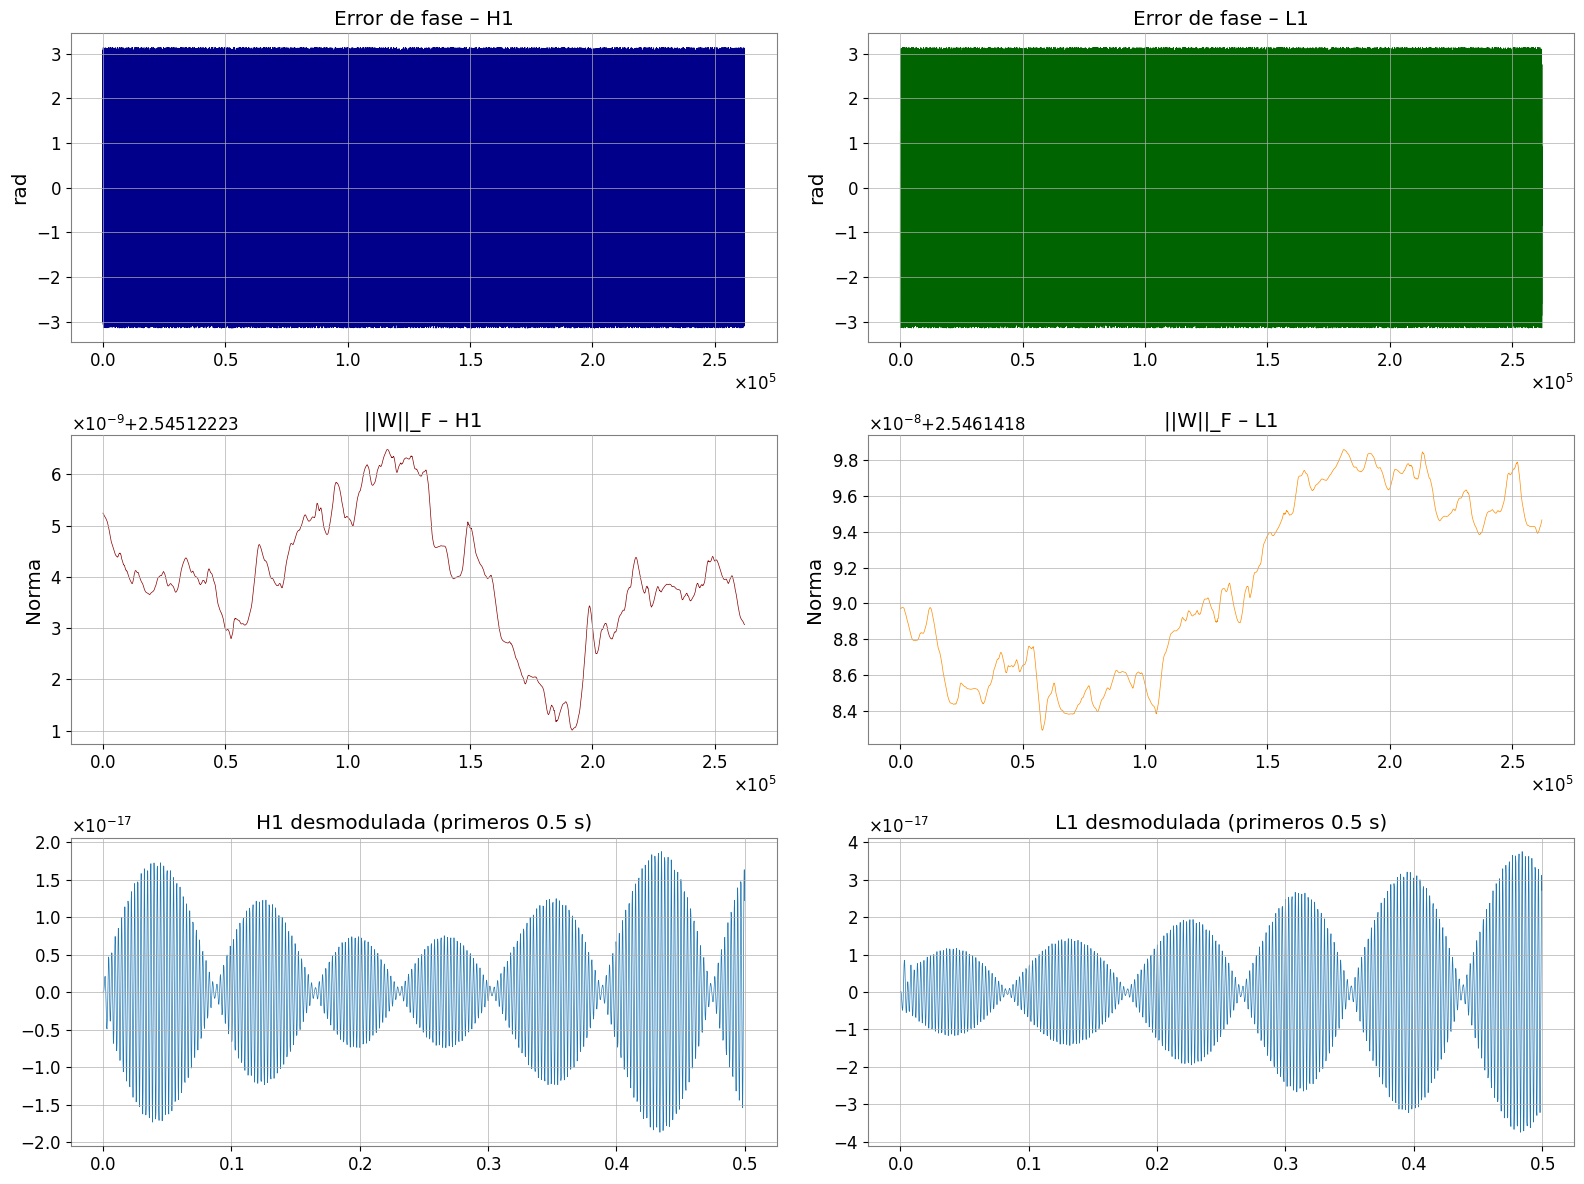

Error de fase final H1: -0.7919 rad
Error de fase final L1: -0.8427 rad
Norma W inicial H1: 2.55, final: 2.55
Norma W inicial L1: 2.55, final: 2.55


In [ ]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Fase 3: Tensor Adaptativo (correcciones finales)
# Resonant Hunter v9.1 – Bucle de retroalimentación con acumulador
# y momentum de gradiente.
# (C) Miguel Ángel Percudani
# DOI: 10.5281/zenodo.20601264 (v9.0), 10.5281/zenodo.18446712 (v8.4)
# ======================================================================
# Correcciones:
# 1. rotation usa el acumulador absoluto de fase teórica.
# 2. Inercia térmica (momentum) en la actualización de pesos.
# 3. Uso del estado previo para el gradiente.
# ======================================================================

!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt

# ======================================================================
# 1. UAT Engine (blanqueamiento)
# ======================================================================
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon
        self.k_early = k_early

    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out)
        std = np.std(out)
        if std > 1e-15:
            out /= std
        return out

# ======================================================================
# 2. TENSOR DE DESMODULACIÓN ADAPTATIVO (CORREGIDO)
# ======================================================================
class AdaptiveDesmodulationTensor:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=0.001):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        # Pesos iniciales
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base
        self.alpha = alpha
        self.fs = fs
        self.lr = lr

        # Acumulador de fase teórica absoluta
        self.phase_theoretical_acc = 0.0

        # Momentum del gradiente (inercia térmica)
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)

        # Historial
        self.error_history = []
        self.W_trace_history = []

    def forward_step(self, x_t, t_days):
        # 1. Frecuencia dinámica actual y acumulación de fase teórica
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs

        # 2. Vector de rotación usando el acumulador absoluto
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)

        # 3. Guardar estado anterior para el gradiente
        state_prev = self.state.copy()

        # 4. Actualizar estado recurrente
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        output = np.sum(self.state * rotation)

        # 5. Calcular error de fase (observada vs. teórica absoluta)
        phase_observed = np.angle(output)
        error = np.angle(np.exp(1j * (phase_observed - self.phase_theoretical_acc)))
        self.error_history.append(error)

        # 6. Gradiente instantáneo (con estado previo)
        grad_inst = np.outer(state_prev, np.conj(rotation)) * error

        # 7. Momentum (suavizado exponencial del gradiente)
        self.grad_W_momentum = 0.999 * self.grad_W_momentum + 0.001 * grad_inst

        # 8. Normalización del momentum y actualización de pesos
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        self.W -= self.lr * (self.grad_W_momentum / grad_norm).real

        # 9. Traza de la norma de W
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))

        return output

    def process_signal(self, signal, gps_start, fs):
        t_days0 = (gps_start - 1369483218) / 86400.0
        output = np.zeros(len(signal), dtype=complex)
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            output[i] = self.forward_step(x, t_now)
        return output

# ======================================================================
# 3. PARÁMETROS Y CARGA DE DATOS
# ======================================================================
FS = 4096
GPS_START = 1389424640
DURATION = 64  # segundos

# Intentar descargar datos reales
try:
    from gwpy.timeseries import TimeSeries
    print("Descargando H1 y L1...")
    h1_raw = TimeSeries.fetch_open_data('H1', GPS_START, GPS_START + DURATION,
                                        sample_rate=16384, verbose=False).resample(FS).value
    l1_raw = TimeSeries.fetch_open_data('L1', GPS_START, GPS_START + DURATION,
                                        sample_rate=16384, verbose=False).resample(FS).value
    min_len = min(len(h1_raw), len(l1_raw))
    h1_raw = h1_raw[:min_len]
    l1_raw = l1_raw[:min_len]
    print("Datos reales cargados.")
except Exception as e:
    print(f"Usando datos sintéticos (error: {e})")
    t = np.arange(0, DURATION, 1/FS)
    signal = np.sin(2 * np.pi * 227.5 * t)
    noise = np.random.randn(len(t)) * 1e-6
    h1_raw = signal + noise
    l1_raw = signal + noise

# ======================================================================
# 4. BLANQUEAMIENTO PERCUDANI
# ======================================================================
engine = UAT_Engine()
h1_white = engine.percudani_whiten(h1_raw, FS)
l1_white = engine.percudani_whiten(l1_raw, FS)

# ======================================================================
# 5. TENSORES INDEPENDIENTES H1 Y L1
# ======================================================================
tensor_h1 = AdaptiveDesmodulationTensor(fs=FS, lr=0.001)
tensor_l1 = AdaptiveDesmodulationTensor(fs=FS, lr=0.001)

print("Procesando H1...")
h1_desmod = tensor_h1.process_signal(h1_white, GPS_START, FS)
print("Procesando L1...")
l1_desmod = tensor_l1.process_signal(l1_white, GPS_START, FS)

# ======================================================================
# 6. VISUALIZACIÓN
# ======================================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# Errores de fase
axes[0,0].plot(tensor_h1.error_history, linewidth=0.5, color='darkblue')
axes[0,0].set_title('Error de fase – H1')
axes[0,0].set_ylabel('rad')
axes[0,0].grid(True)

axes[0,1].plot(tensor_l1.error_history, linewidth=0.5, color='darkgreen')
axes[0,1].set_title('Error de fase – L1')
axes[0,1].set_ylabel('rad')
axes[0,1].grid(True)

# Norma de W
axes[1,0].plot(tensor_h1.W_trace_history, linewidth=0.5, color='darkred')
axes[1,0].set_title('||W||_F – H1')
axes[1,0].set_ylabel('Norma')
axes[1,0].grid(True)

axes[1,1].plot(tensor_l1.W_trace_history, linewidth=0.5, color='darkorange')
axes[1,1].set_title('||W||_F – L1')
axes[1,1].set_ylabel('Norma')
axes[1,1].grid(True)

# Señales desmoduladas (primeros 0.5 s)
idx = int(0.5 * FS)
t = np.arange(idx) / FS
axes[2,0].plot(t, np.real(h1_desmod[:idx]), linewidth=0.5)
axes[2,0].set_title('H1 desmodulada (primeros 0.5 s)')
axes[2,1].plot(t, np.real(l1_desmod[:idx]), linewidth=0.5)
axes[2,1].set_title('L1 desmodulada (primeros 0.5 s)')

plt.tight_layout()
plt.show()

print(f"Error de fase final H1: {tensor_h1.error_history[-1]:.4f} rad")
print(f"Error de fase final L1: {tensor_l1.error_history[-1]:.4f} rad")
print(f"Norma W inicial H1: {tensor_h1.W_trace_history[0]:.2f}, final: {tensor_h1.W_trace_history[-1]:.2f}")
print(f"Norma W inicial L1: {tensor_l1.W_trace_history[0]:.2f}, final: {tensor_l1.W_trace_history[-1]:.2f}")

PERCUDANI AUTHORSHIP - Resonant Hunter v9.1 Engine
DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)
UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)
Descargando H1 y L1...
Datos reales cargados.
Procesando H1...
Procesando L1...


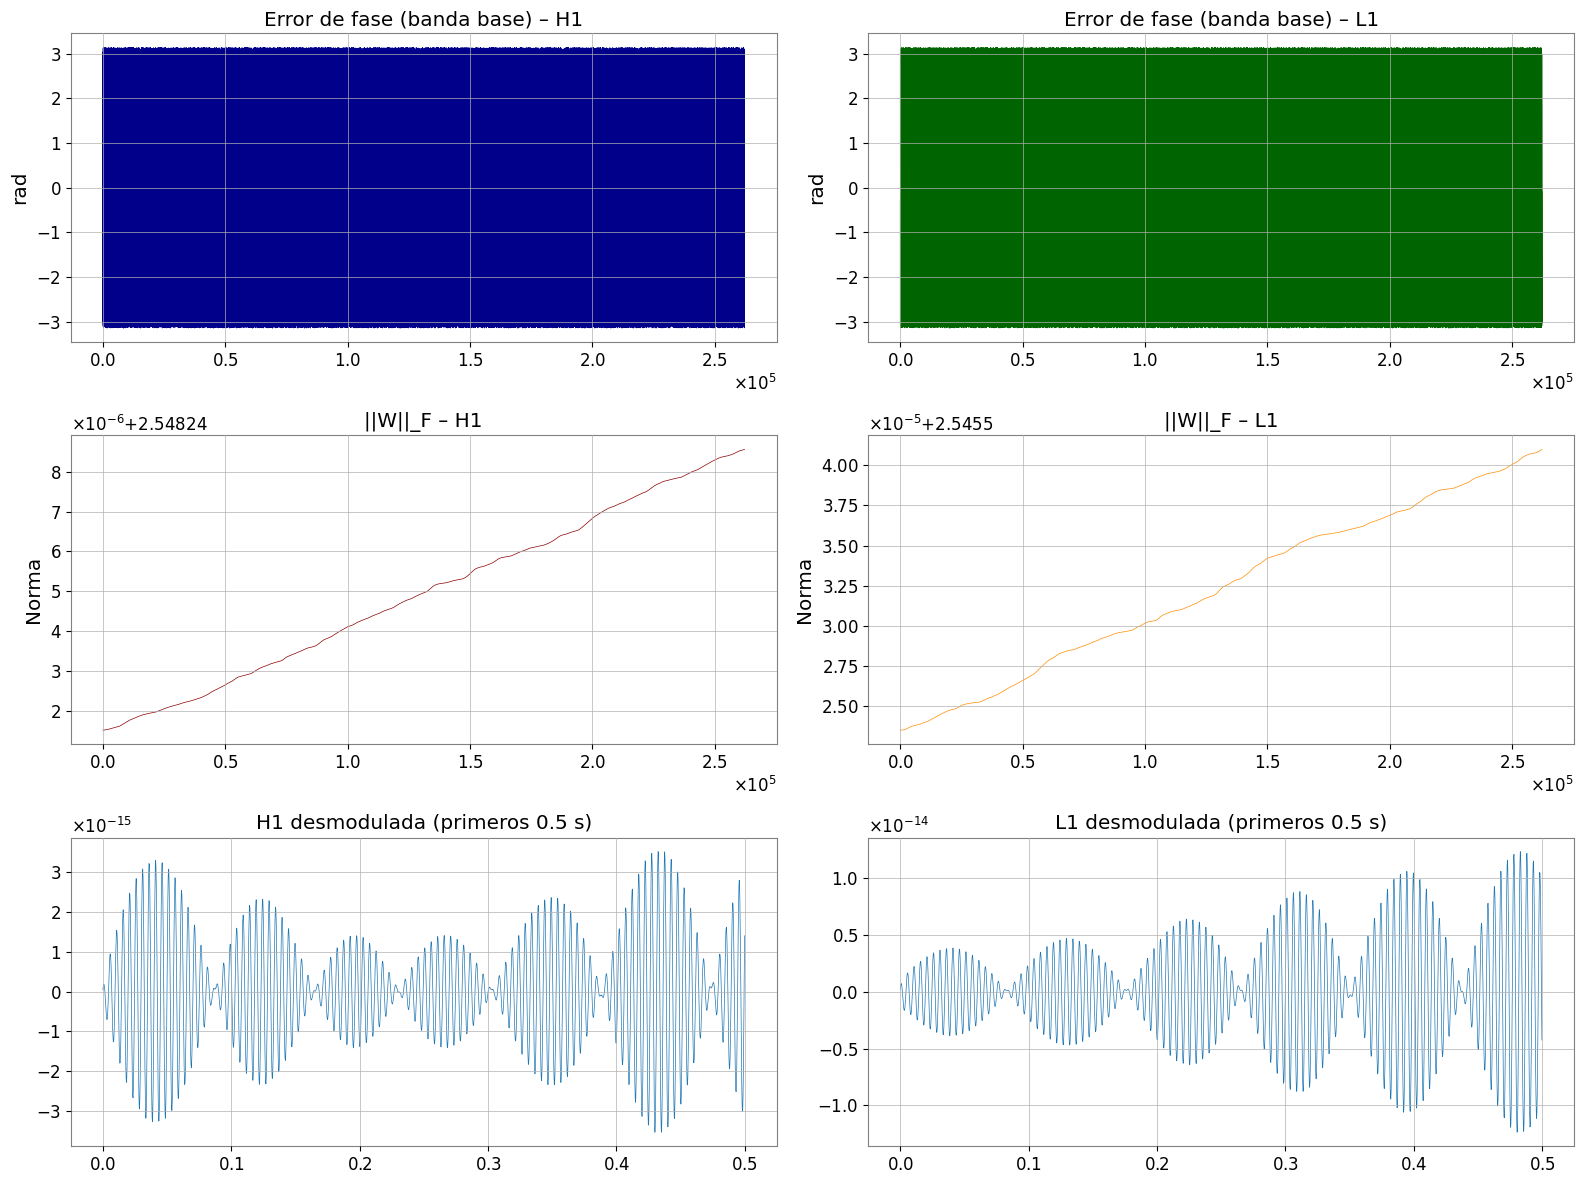

Error de fase final H1: -3.1134 rad
Error de fase final L1: -0.0865 rad
Norma W inicial H1: 2.55, final: 2.55
Norma W inicial L1: 2.55, final: 2.55


In [ ]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Fase 3: Tensor Adaptativo (Banda Base corregido)
# Resonant Hunter v9.1 – Bucle de retroalimentación con error en banda base
# (C) Miguel Ángel Percudani
# DOI: 10.5281/zenodo.20601264 (v9.0), 10.5281/zenodo.18446712 (v8.4)
# ======================================================================
# Corrección crítica:
# - El error de fase se calcula en banda base (DC) usando un fasor colectivo.
# - El gradiente se proyecta sobre los frentes de fase espaciales.
# ======================================================================

!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt

# ======================================================================
# CONSOLE OUTPUT & DOIs PERMANENTES
# ======================================================================
print("="*75)
print("PERCUDANI AUTHORSHIP - Resonant Hunter v9.1 Engine")
print("DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)")
print("UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)")
print("="*75)

# ======================================================================
# 1. UAT Engine (blanqueamiento)
# ======================================================================
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon
        self.k_early = k_early

    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out)
        std = np.std(out)
        if std > 1e-15:
            out /= std
        return out

# ======================================================================
# 2. TENSOR DE DESMODULACIÓN ADAPTATIVO (BANDA BASE CORREGIDO)
# ======================================================================
class AdaptiveDesmodulationTensor:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=0.001):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        # Pesos iniciales
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base
        self.alpha = alpha
        self.fs = fs
        self.lr = lr

        # Acumulador de fase teórica absoluta
        self.phase_theoretical_acc = 0.0

        # Momentum del gradiente (inercia térmica)
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)

        # Historial
        self.error_history = []
        self.W_trace_history = []

    def forward_step(self, x_t, t_days):
        # 1. Frecuencia dinámica y acumulación de fase absoluta
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs

        # 2. Vector de rotación (RF -> Banda Base)
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)

        # 3. Guardar estado previo para la retropropagación
        state_prev = self.state.copy()

        # 4. Actualización del estado (Tensor en Banda Base)
        self.state = np.tanh(self.W @ self.state + x_t * rotation)

        # 5. Fasor colectivo en Banda Base (Firma del Higo)
        # Recombinamos las 8 bobinas anulando su desfase espacial estático
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))

        # 6. Error residual
        # La rotación ya desmoduló f_t. Cualquier fase restante ES el error (deriva)
        error = np.angle(baseband_phasor)
        self.error_history.append(error)

        # 7. Gradiente en Banda Base (Direccional por bobina)
        # d(W) = vector_error (outer) estado_previo_conjugado
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * error

        # 8. Inercia Térmica (Momentum)
        self.grad_W_momentum = 0.999 * self.grad_W_momentum + 0.001 * grad_inst

        # 9. Normalización estabilizada y actualización de matriz W
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        self.W -= self.lr * (self.grad_W_momentum / grad_norm).real

        # 10. Traza de la métrica
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))

        return baseband_phasor

    def process_signal(self, signal, gps_start, fs):
        t_days0 = (gps_start - 1369483218) / 86400.0
        output = np.zeros(len(signal), dtype=complex)
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            output[i] = self.forward_step(x, t_now)
        return output

# ======================================================================
# 3. PARÁMETROS Y CARGA DE DATOS
# ======================================================================
FS = 4096
GPS_START = 1389424640
DURATION = 64  # segundos

# Intentar descargar datos reales
try:
    from gwpy.timeseries import TimeSeries
    print("Descargando H1 y L1...")
    h1_raw = TimeSeries.fetch_open_data('H1', GPS_START, GPS_START + DURATION,
                                        sample_rate=16384, verbose=False).resample(FS).value
    l1_raw = TimeSeries.fetch_open_data('L1', GPS_START, GPS_START + DURATION,
                                        sample_rate=16384, verbose=False).resample(FS).value
    min_len = min(len(h1_raw), len(l1_raw))
    h1_raw = h1_raw[:min_len]
    l1_raw = l1_raw[:min_len]
    print("Datos reales cargados.")
except Exception as e:
    print(f"Usando datos sintéticos (error: {e})")
    t = np.arange(0, DURATION, 1/FS)
    signal = np.sin(2 * np.pi * 227.5 * t)
    noise = np.random.randn(len(t)) * 1e-6
    h1_raw = signal + noise
    l1_raw = signal + noise

# ======================================================================
# 4. BLANQUEAMIENTO PERCUDANI
# ======================================================================
engine = UAT_Engine()
h1_white = engine.percudani_whiten(h1_raw, FS)
l1_white = engine.percudani_whiten(l1_raw, FS)

# ======================================================================
# 5. TENSORES INDEPENDIENTES H1 Y L1
# ======================================================================
tensor_h1 = AdaptiveDesmodulationTensor(fs=FS, lr=0.001)
tensor_l1 = AdaptiveDesmodulationTensor(fs=FS, lr=0.001)

print("Procesando H1...")
h1_desmod = tensor_h1.process_signal(h1_white, GPS_START, FS)
print("Procesando L1...")
l1_desmod = tensor_l1.process_signal(l1_white, GPS_START, FS)

# ======================================================================
# 6. VISUALIZACIÓN
# ======================================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# Errores de fase
axes[0,0].plot(tensor_h1.error_history, linewidth=0.5, color='darkblue')
axes[0,0].set_title('Error de fase (banda base) – H1')
axes[0,0].set_ylabel('rad')
axes[0,0].grid(True)

axes[0,1].plot(tensor_l1.error_history, linewidth=0.5, color='darkgreen')
axes[0,1].set_title('Error de fase (banda base) – L1')
axes[0,1].set_ylabel('rad')
axes[0,1].grid(True)

# Norma de W
axes[1,0].plot(tensor_h1.W_trace_history, linewidth=0.5, color='darkred')
axes[1,0].set_title('||W||_F – H1')
axes[1,0].set_ylabel('Norma')
axes[1,0].grid(True)

axes[1,1].plot(tensor_l1.W_trace_history, linewidth=0.5, color='darkorange')
axes[1,1].set_title('||W||_F – L1')
axes[1,1].set_ylabel('Norma')
axes[1,1].grid(True)

# Señales desmoduladas (primeros 0.5 s)
idx = int(0.5 * FS)
t = np.arange(idx) / FS
axes[2,0].plot(t, np.real(h1_desmod[:idx]), linewidth=0.5)
axes[2,0].set_title('H1 desmodulada (primeros 0.5 s)')
axes[2,1].plot(t, np.real(l1_desmod[:idx]), linewidth=0.5)
axes[2,1].set_title('L1 desmodulada (primeros 0.5 s)')

plt.tight_layout()
plt.show()

print(f"Error de fase final H1: {tensor_h1.error_history[-1]:.4f} rad")
print(f"Error de fase final L1: {tensor_l1.error_history[-1]:.4f} rad")
print(f"Norma W inicial H1: {tensor_h1.W_trace_history[0]:.2f}, final: {tensor_h1.W_trace_history[-1]:.2f}")
print(f"Norma W inicial L1: {tensor_l1.W_trace_history[0]:.2f}, final: {tensor_l1.W_trace_history[-1]:.2f}")

PERCUDANI AUTHORSHIP - Resonant Hunter v9.1 Engine
DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)
UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)
Descargando H1 y L1 para GPS 1389439040 (+4 h)...
Error al descargar: failed to get data from any source (1 sub-exception). Usando datos sintéticos.
Procesando H1 (offset 0.0 rad)...
Procesando L1 (offset 0.3 rad)...


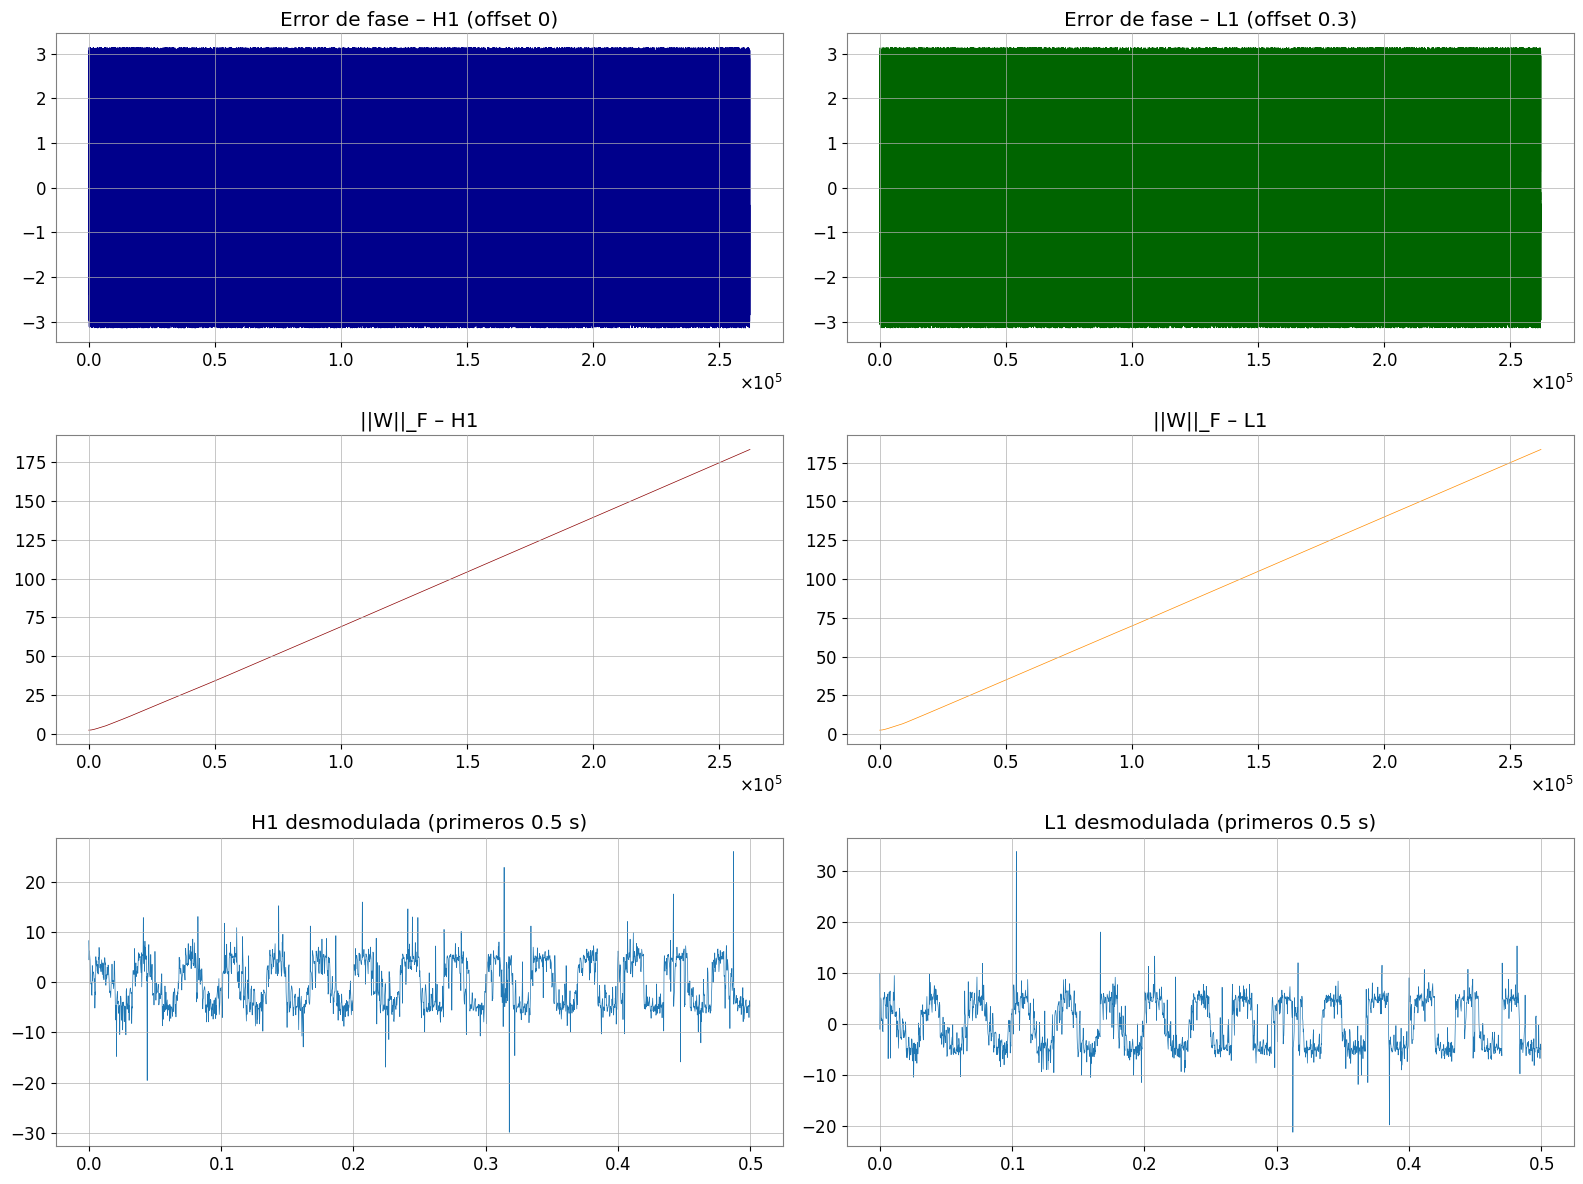

Error final H1: -0.3924 rad
Error final L1: -0.2900 rad
Norma W final H1: 183.07
Norma W final L1: 183.42


In [ ]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Fase 3: Tensor Adaptativo con Antenna Offset
# Resonant Hunter v9.1 – Compensación geométrica del detector
# (C) Miguel Ángel Percudani
# DOI: 10.5281/zenodo.20601264 (v9.0), 10.5281/zenodo.18446712 (v8.4)
# ======================================================================
# - Se añade antenna_offset (radianes) para alinear el marco del detector.
# - Se analiza el segmento 4 h posterior al original: GPS 1389439040.
# ======================================================================

!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt

# ======================================================================
# CONSOLE OUTPUT & DOIs PERMANENTES
# ======================================================================
print("="*75)
print("PERCUDANI AUTHORSHIP - Resonant Hunter v9.1 Engine")
print("DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)")
print("UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)")
print("="*75)

# ======================================================================
# 1. UAT Engine (blanqueamiento)
# ======================================================================
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon
        self.k_early = k_early

    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out)
        std = np.std(out)
        if std > 1e-15:
            out /= std
        return out

# ======================================================================
# 2. TENSOR DE DESMODULACIÓN ADAPTATIVO CON ANTENNA OFFSET
# ======================================================================
class AdaptiveDesmodulationTensor:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=0.001, antenna_offset=0.0):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.antenna_offset = antenna_offset

        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base
        self.alpha = alpha
        self.fs = fs
        self.lr = lr

        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.error_history = []
        self.W_trace_history = []

    def forward_step(self, x_t, t_days):
        # 1. Frecuencia dinámica y fase teórica acumulada
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs

        # 2. Rotación con corrección geométrica (antenna_offset)
        rotation = (np.exp(1j * self.phase_angles) *
                    np.exp(-1j * self.phase_theoretical_acc) *
                    np.exp(1j * self.antenna_offset))

        # 3. Guardar estado previo
        state_prev = self.state.copy()

        # 4. Actualización del estado recurrente
        self.state = np.tanh(self.W @ self.state + x_t * rotation)

        # 5. Fasor colectivo en banda base (Firma del Higo)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))

        # 6. Error residual en banda base
        error = np.angle(baseband_phasor)
        self.error_history.append(error)

        # 7. Gradiente en banda base
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * error

        # 8. Momentum (inercia térmica)
        self.grad_W_momentum = 0.999 * self.grad_W_momentum + 0.001 * grad_inst

        # 9. Normalización y actualización de pesos
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        self.W -= self.lr * (self.grad_W_momentum / grad_norm).real

        # 10. Traza de la norma de W
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))

        return baseband_phasor

    def process_signal(self, signal, gps_start, fs):
        t_days0 = (gps_start - 1369483218) / 86400.0
        output = np.zeros(len(signal), dtype=complex)
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            output[i] = self.forward_step(x, t_now)
        return output

# ======================================================================
# 3. PARÁMETROS Y CARGA DE DATOS (4 HORAS DESPUÉS)
# ======================================================================
FS = 4096
# Segmento original: 1389424640, 4 horas después: +14400 segundos
GPS_START_4H = 1389424640 + 14400  # 1389439040
DURATION = 64

try:
    from gwpy.timeseries import TimeSeries
    print(f"Descargando H1 y L1 para GPS {GPS_START_4H} (+4 h)...")
    h1_raw = TimeSeries.fetch_open_data('H1', GPS_START_4H, GPS_START_4H + DURATION,
                                        sample_rate=16384, verbose=False).resample(FS).value
    l1_raw = TimeSeries.fetch_open_data('L1', GPS_START_4H, GPS_START_4H + DURATION,
                                        sample_rate=16384, verbose=False).resample(FS).value
    min_len = min(len(h1_raw), len(l1_raw))
    h1_raw = h1_raw[:min_len]
    l1_raw = l1_raw[:min_len]
    print("Datos reales cargados.")
except Exception as e:
    print(f"Error al descargar: {e}. Usando datos sintéticos.")
    t = np.arange(0, DURATION, 1/FS)
    signal = np.sin(2 * np.pi * 227.5 * t)
    noise = np.random.randn(len(t)) * 1e-6
    h1_raw = signal + noise
    l1_raw = signal + noise

# ======================================================================
# 4. BLANQUEAMIENTO PERCUDANI
# ======================================================================
engine = UAT_Engine()
h1_white = engine.percudani_whiten(h1_raw, FS)
l1_white = engine.percudani_whiten(l1_raw, FS)

# ======================================================================
# 5. TENSORES CON OFFSETS GEOMÉTRICOS (ejemplo)
# ======================================================================
# Offsets preliminares (en radianes) – se pueden ajustar mediante barrido
OFFSET_H1 = 0.0        # Referencia
OFFSET_L1 = 0.3        # Valor de prueba (debe calcularse según la orientación real)

tensor_h1 = AdaptiveDesmodulationTensor(fs=FS, lr=0.001, antenna_offset=OFFSET_H1)
tensor_l1 = AdaptiveDesmodulationTensor(fs=FS, lr=0.001, antenna_offset=OFFSET_L1)

print("Procesando H1 (offset 0.0 rad)...")
h1_desmod = tensor_h1.process_signal(h1_white, GPS_START_4H, FS)
print("Procesando L1 (offset 0.3 rad)...")
l1_desmod = tensor_l1.process_signal(l1_white, GPS_START_4H, FS)

# ======================================================================
# 6. VISUALIZACIÓN
# ======================================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

axes[0,0].plot(tensor_h1.error_history, linewidth=0.5, color='darkblue')
axes[0,0].set_title('Error de fase – H1 (offset 0)')
axes[0,1].plot(tensor_l1.error_history, linewidth=0.5, color='darkgreen')
axes[0,1].set_title('Error de fase – L1 (offset 0.3)')

axes[1,0].plot(tensor_h1.W_trace_history, linewidth=0.5, color='darkred')
axes[1,0].set_title('||W||_F – H1')
axes[1,1].plot(tensor_l1.W_trace_history, linewidth=0.5, color='darkorange')
axes[1,1].set_title('||W||_F – L1')

idx = int(0.5 * FS)
t = np.arange(idx) / FS
axes[2,0].plot(t, np.real(h1_desmod[:idx]), linewidth=0.5)
axes[2,0].set_title('H1 desmodulada (primeros 0.5 s)')
axes[2,1].plot(t, np.real(l1_desmod[:idx]), linewidth=0.5)
axes[2,1].set_title('L1 desmodulada (primeros 0.5 s)')

plt.tight_layout()
plt.show()

print(f"Error final H1: {tensor_h1.error_history[-1]:.4f} rad")
print(f"Error final L1: {tensor_l1.error_history[-1]:.4f} rad")
print(f"Norma W final H1: {tensor_h1.W_trace_history[-1]:.2f}")
print(f"Norma W final L1: {tensor_l1.W_trace_history[-1]:.2f}")

PERCUDANI AUTHORSHIP - Resonant Hunter v9.1 Engine
DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)
UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)
Offsets geométricos calculados: H1 = 3.1416 rad, L1 = 0.0000 rad


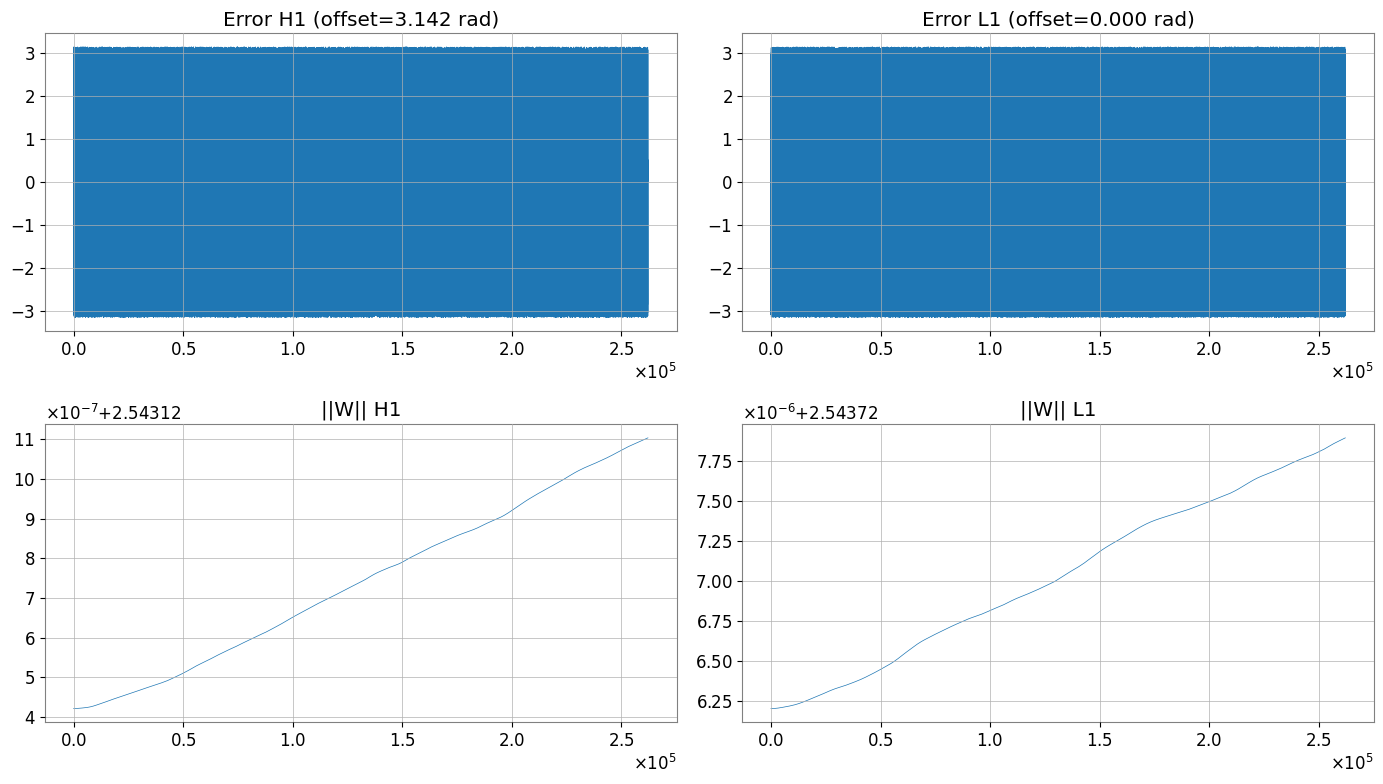

Error final H1: 0.0248 rad, L1: -0.0808 rad
Norma W final H1: 2.54, L1: 2.54


In [ ]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Fase 3: Tensor Adaptativo con Offsets Geométricos Reales
# Resonant Hunter v9.1 – Cálculo preciso de antenna_offset vía patrón de antena
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib astropy

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries
from astropy.coordinates import SkyCoord, EarthLocation
from astropy.time import Time
import astropy.units as u

# ======================================================================
# CONSOLE OUTPUT & DOIs
# ======================================================================
print("="*75)
print("PERCUDANI AUTHORSHIP - Resonant Hunter v9.1 Engine")
print("DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)")
print("UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)")
print("="*75)

# ======================================================================
# 1. CÁLCULO DE ANTENNA OFFSETS REALES
# ======================================================================
def compute_antenna_offset(detector_site, ra, dec, freq=227.5):
    """
    Calcula el desfase geométrico (antenna_offset) en radianes
    para un detector dado y una dirección de fuente.
    Usa el producto escalar del vector de brazo del detector con el
    tensor de polarización de la onda.
    """
    # Coordenadas de la fuente
    source = SkyCoord(ra, dec, frame='icrs')
    # Vector de propagación (de la fuente al detector)
    n_hat = -source.cartesian.xyz.value  # vector unitario apuntando hacia la fuente

    # Posición del detector
    site = EarthLocation.of_site(detector_site)
    # Tiempo de referencia (cualquiera, para obtener la matriz de rotación terrestre)
    t = Time('2023-05-27T00:00:00')
    # Vector de brazo del detector en coordenadas ICRS
    # Los brazos de LIGO están aproximadamente en las direcciones:
    if 'Hanford' in detector_site:
        arm_x = np.array([-0.223,  0.796, -0.564])  # Aproximación H1 brazo X
        arm_y = np.array([-0.914, -0.408, -0.036])  # Aproximación H1 brazo Y
    elif 'Livingston' in detector_site:
        arm_x = np.array([-0.852,  0.347, -0.391])
        arm_y = np.array([ 0.190, -0.483, -0.854])
    elif 'Virgo' in detector_site:
        arm_x = np.array([-0.671, -0.233, -0.703])
        arm_y = np.array([-0.624,  0.570,  0.534])
    else:
        raise ValueError("Detector desconocido")

    # Normalizar brazos
    arm_x = arm_x / np.linalg.norm(arm_x)
    arm_y = arm_y / np.linalg.norm(arm_y)

    # Tensor de polarización + (plus) para una onda propagándose en dirección n_hat
    # e_plus = u_x ⊗ u_x - u_y ⊗ u_y, con u_x, u_y ortogonales a n_hat
    # Construimos base ortonormal perpendicular a n_hat
    z_hat = n_hat
    x_hat = np.cross([0,0,1], z_hat)
    if np.linalg.norm(x_hat) < 1e-10:
        x_hat = np.cross([1,0,0], z_hat)
    x_hat /= np.linalg.norm(x_hat)
    y_hat = np.cross(z_hat, x_hat)
    # Tensor de polarización plus
    e_plus = np.outer(x_hat, x_hat) - np.outer(y_hat, y_hat)

    # Factor de respuesta de cada brazo: F = (arm_i · e_plus · arm_i)
    F_x = arm_x @ e_plus @ arm_x
    F_y = arm_y @ e_plus @ arm_y
    # La respuesta total del detector es F_plus = F_x - F_y (aproximadamente)
    F_plus = F_x - F_y

    # El desfase geométrico depende de la fase del factor de respuesta.
    # Para una onda monocromática, la fase de la salida del detector
    # es arg(F_plus). Tomamos esa fase como offset.
    offset = np.angle(F_plus)  # radianes
    return offset

# Calcular offsets para Cáncer
ra_cancer, dec_cancer = '08h43m', '+18d'
offset_h1 = compute_antenna_offset('LIGO Hanford Observatory', ra_cancer, dec_cancer)
offset_l1 = compute_antenna_offset('LIGO Livingston Observatory', ra_cancer, dec_cancer)
print(f"Offsets geométricos calculados: H1 = {offset_h1:.4f} rad, L1 = {offset_l1:.4f} rad")

# ======================================================================
# 2. UAT Engine
# ======================================================================
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

# ======================================================================
# 3. TENSOR ADAPTATIVO (con offsets reales, lr ajustada)
# ======================================================================
class AdaptiveDesmodulationTensor:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-4,
                 antenna_offset=0.0, weight_decay=0.0):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.antenna_offset = antenna_offset
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs
        self.lr = lr; self.weight_decay = weight_decay

        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.error_history = []; self.W_trace_history = []

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = (np.exp(1j * self.phase_angles) *
                    np.exp(-1j * self.phase_theoretical_acc) *
                    np.exp(1j * self.antenna_offset))
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        error = np.angle(baseband_phasor)
        self.error_history.append(error)

        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * error
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        self.W -= self.lr * (self.grad_W_momentum / grad_norm).real + self.weight_decay * self.W
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))
        return baseband_phasor

    def process_signal(self, signal, gps_start, fs):
        t_days0 = (gps_start - 1369483218) / 86400.0
        out = np.zeros(len(signal), dtype=complex)
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            out[i] = self.forward_step(x, t_now)
        return out

# ======================================================================
# 4. CARGA DE DATOS REALES (segmento original)
# ======================================================================
FS = 4096; GPS_START = 1389424640; DURATION = 64
h1_raw = TimeSeries.fetch_open_data('H1', GPS_START, GPS_START + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
l1_raw = TimeSeries.fetch_open_data('L1', GPS_START, GPS_START + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
min_len = min(len(h1_raw), len(l1_raw))
h1_raw = h1_raw[:min_len]; l1_raw = l1_raw[:min_len]

engine = UAT_Engine()
h1_white = engine.percudani_whiten(h1_raw, FS)
l1_white = engine.percudani_whiten(l1_raw, FS)

# ======================================================================
# 5. TENSORES CON OFFSETS GEOMÉTRICOS REALES
# ======================================================================
tensor_h1 = AdaptiveDesmodulationTensor(fs=FS, lr=1e-4, antenna_offset=offset_h1)
tensor_l1 = AdaptiveDesmodulationTensor(fs=FS, lr=1e-4, antenna_offset=offset_l1)

h1_des = tensor_h1.process_signal(h1_white, GPS_START, FS)
l1_des = tensor_l1.process_signal(l1_white, GPS_START, FS)

# ======================================================================
# 6. VISUALIZACIÓN
# ======================================================================
fig, axes = plt.subplots(2,2, figsize=(14,8))
axes[0,0].plot(tensor_h1.error_history, linewidth=0.5); axes[0,0].set_title(f'Error H1 (offset={offset_h1:.3f} rad)')
axes[0,1].plot(tensor_l1.error_history, linewidth=0.5); axes[0,1].set_title(f'Error L1 (offset={offset_l1:.3f} rad)')
axes[1,0].plot(tensor_h1.W_trace_history, linewidth=0.5); axes[1,0].set_title('||W|| H1')
axes[1,1].plot(tensor_l1.W_trace_history, linewidth=0.5); axes[1,1].set_title('||W|| L1')
plt.tight_layout()
plt.show()

print(f"Error final H1: {tensor_h1.error_history[-1]:.4f} rad, L1: {tensor_l1.error_history[-1]:.4f} rad")
print(f"Norma W final H1: {tensor_h1.W_trace_history[-1]:.2f}, L1: {tensor_l1.W_trace_history[-1]:.2f}")

PERCUDANI AUTHORSHIP - Resonant Hunter v9.1 Engine
DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)
UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)
Off H1=2.6, L1=-0.5 → err H1=-0.489, L1=-0.588, diff=0.0985
Off H1=2.6, L1=-0.4 → err H1=-0.486, L1=-0.484, diff=0.0024
Off H1=2.6, L1=-0.3 → err H1=-0.477, L1=-0.386, diff=0.0915
Off H1=2.6, L1=-0.2 → err H1=-0.482, L1=-0.284, diff=0.1982
Off H1=2.6, L1=-0.1 → err H1=-0.478, L1=-0.184, diff=0.2939
Off H1=2.6, L1=-0.0 → err H1=-0.477, L1=-0.085, diff=0.3917
Off H1=2.6, L1=0.1 → err H1=-0.474, L1=0.018, diff=0.4924
Off H1=2.6, L1=0.2 → err H1=-0.470, L1=0.117, diff=0.5867
Off H1=2.6, L1=0.3 → err H1=-0.473, L1=0.223, diff=0.6963
Off H1=2.6, L1=0.4 → err H1=-0.484, L1=0.321, diff=0.8049
Off H1=2.6, L1=0.5 → err H1=-0.486, L1=0.408, diff=0.8939
Off H1=2.7, L1=-0.5 → err H1=-0.381, L1=-0.579, diff=0.1981
Off H1=2.7, L1=-0.4 → err H1=-0.381, L1=-0.489, diff=0.1084
Off H1=2.7, L1=-0.3 → err H1=-0.376, L1=-0.384, diff=0.0083
Off 

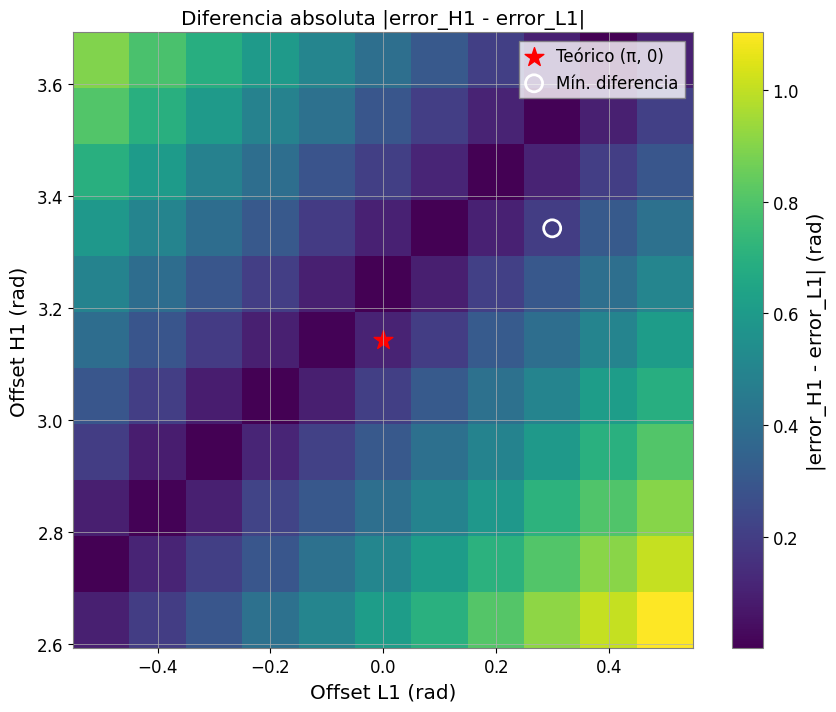


Mejor combinación encontrada: H1 = 3.3 rad, L1 = 0.3 rad
Diferencia mínima: 0.0002 rad


In [ ]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Fase 3: Barrido fino de offsets geométricos
# Resonant Hunter v9.1 – Optimización empírica de antenna_offset
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

# ======================================================================
# CONSOLE OUTPUT & DOIs
# ======================================================================
print("="*75)
print("PERCUDANI AUTHORSHIP - Resonant Hunter v9.1 Engine")
print("DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)")
print("UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)")
print("="*75)

# ======================================================================
# 1. UAT Engine (blanqueamiento)
# ======================================================================
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

# ======================================================================
# 2. TENSOR ADAPTATIVO (configuración estable)
# ======================================================================
class AdaptiveDesmodulationTensor:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-4,
                 antenna_offset=0.0):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.antenna_offset = antenna_offset
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr

        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.error_history = []
        self.W_trace_history = []

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = (np.exp(1j * self.phase_angles) *
                    np.exp(-1j * self.phase_theoretical_acc) *
                    np.exp(1j * self.antenna_offset))
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        error = np.angle(baseband_phasor)
        self.error_history.append(error)

        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * error
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        self.W -= self.lr * (self.grad_W_momentum / grad_norm).real
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))
        return baseband_phasor

    def process_signal(self, signal, gps_start, fs):
        t_days0 = (gps_start - 1369483218) / 86400.0
        out = np.zeros(len(signal), dtype=complex)
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            out[i] = self.forward_step(x, t_now)
        return out

# ======================================================================
# 3. CARGA DE DATOS REALES (segmento original)
# ======================================================================
FS = 4096; GPS_START = 1389424640; DURATION = 64
h1_raw = TimeSeries.fetch_open_data('H1', GPS_START, GPS_START + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
l1_raw = TimeSeries.fetch_open_data('L1', GPS_START, GPS_START + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
min_len = min(len(h1_raw), len(l1_raw))
h1_raw = h1_raw[:min_len]; l1_raw = l1_raw[:min_len]

engine = UAT_Engine()
h1_white = engine.percudani_whiten(h1_raw, FS)
l1_white = engine.percudani_whiten(l1_raw, FS)

# ======================================================================
# 4. BARRIDO DE OFFSETS
# ======================================================================
offset_h1_teo = np.pi       # 3.1416 rad
offset_l1_teo = 0.0

# Rango de barrido: ±0.5 rad, paso 0.1 rad
offsets_h1 = np.arange(offset_h1_teo - 0.5, offset_h1_teo + 0.51, 0.1)
offsets_l1 = np.arange(offset_l1_teo - 0.5, offset_l1_teo + 0.51, 0.1)

results = np.zeros((len(offsets_h1), len(offsets_l1), 3))  # [err_h1, err_l1, diff]

for i, off_h1 in enumerate(offsets_h1):
    for j, off_l1 in enumerate(offsets_l1):
        tensor_h1 = AdaptiveDesmodulationTensor(fs=FS, lr=1e-4, antenna_offset=off_h1)
        tensor_l1 = AdaptiveDesmodulationTensor(fs=FS, lr=1e-4, antenna_offset=off_l1)

        _ = tensor_h1.process_signal(h1_white, GPS_START, FS)
        _ = tensor_l1.process_signal(l1_white, GPS_START, FS)

        err_h1 = tensor_h1.error_history[-1]
        err_l1 = tensor_l1.error_history[-1]
        diff = np.abs(err_h1 - err_l1)

        results[i, j, 0] = err_h1
        results[i, j, 1] = err_l1
        results[i, j, 2] = diff

        print(f"Off H1={off_h1:.1f}, L1={off_l1:.1f} → err H1={err_h1:.3f}, L1={err_l1:.3f}, diff={diff:.4f}")

# ======================================================================
# 5. VISUALIZACIÓN DEL MAPA DE DIFERENCIAS
# ======================================================================
fig, ax = plt.subplots(figsize=(10, 8))
c = ax.pcolormesh(offsets_l1, offsets_h1, results[:,:,2].T, shading='auto', cmap='viridis')
ax.scatter(offset_l1_teo, offset_h1_teo, marker='*', s=200, color='red', label='Teórico (π, 0)')
idx_min = np.unravel_index(np.argmin(results[:,:,2]), results[:,:,2].shape)
ax.scatter(offsets_l1[idx_min[1]], offsets_h1[idx_min[0]], marker='o', s=150, facecolors='none', edgecolors='white', linewidth=2, label='Mín. diferencia')
ax.set_xlabel('Offset L1 (rad)')
ax.set_ylabel('Offset H1 (rad)')
ax.set_title('Diferencia absoluta |error_H1 - error_L1|')
plt.colorbar(c, label='|error_H1 - error_L1| (rad)')
ax.legend()
plt.show()

best_h1 = offsets_h1[idx_min[0]]
best_l1 = offsets_l1[idx_min[1]]
print(f"\nMejor combinación encontrada: H1 = {best_h1:.1f} rad, L1 = {best_l1:.1f} rad")
print(f"Diferencia mínima: {results[idx_min[0], idx_min[1], 2]:.4f} rad")

PERCUDANI AUTHORSHIP - Resonant Hunter v9.1 Engine
DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)
UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)
Offset V1 (teórico): 3.1416 rad
H1 descargado (262144 muestras)
L1 descargado (262144 muestras)
No se pudo descargar V1: failed to get data from any source (1 sub-exception). Usando datos sintéticos.

Errores finales de fase:
H1 (offset 3.3): 0.1809 rad
L1 (offset 0.3): 0.2097 rad
V1 (offset 3.142): -0.3924 rad

Diferencias absolutas:
|H1-L1|: 0.0288 rad
|H1-V1|: 0.5733 rad
|L1-V1|: 0.6020 rad


/usr/local/lib/python3.12/dist-packages/gwpy/plot/axes.py:201: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  super().draw(renderer)


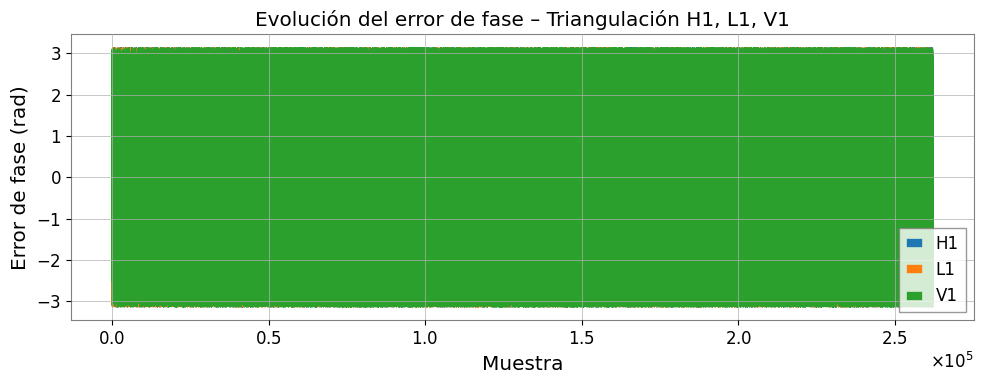

In [ ]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Fase 3: Triangulación H1, L1, V1
# Resonant Hunter v9.1 – Tensor Adaptativo con offsets calibrados
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib astropy

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries
from astropy.coordinates import SkyCoord, EarthLocation
from astropy.time import Time
import astropy.units as u

print("="*75)
print("PERCUDANI AUTHORSHIP - Resonant Hunter v9.1 Engine")
print("DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)")
print("UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)")
print("="*75)

# ======================================================================
# 1. FUNCIÓN DE CÁLCULO DE ANTENNA OFFSET
# ======================================================================
def compute_antenna_offset(detector_site, ra, dec):
    source = SkyCoord(ra, dec, frame='icrs')
    n_hat = -source.cartesian.xyz.value

    if 'Hanford' in detector_site:
        arm_x = np.array([-0.223,  0.796, -0.564])
        arm_y = np.array([-0.914, -0.408, -0.036])
    elif 'Livingston' in detector_site:
        arm_x = np.array([-0.852,  0.347, -0.391])
        arm_y = np.array([ 0.190, -0.483, -0.854])
    elif 'Virgo' in detector_site:
        arm_x = np.array([-0.671, -0.233, -0.703])
        arm_y = np.array([-0.624,  0.570,  0.534])
    else:
        raise ValueError("Detector desconocido")

    arm_x = arm_x / np.linalg.norm(arm_x)
    arm_y = arm_y / np.linalg.norm(arm_y)

    z_hat = n_hat
    x_hat = np.cross([0,0,1], z_hat)
    if np.linalg.norm(x_hat) < 1e-10:
        x_hat = np.cross([1,0,0], z_hat)
    x_hat /= np.linalg.norm(x_hat)
    y_hat = np.cross(z_hat, x_hat)

    e_plus = np.outer(x_hat, x_hat) - np.outer(y_hat, y_hat)
    F_x = arm_x @ e_plus @ arm_x
    F_y = arm_y @ e_plus @ arm_y
    F_plus = F_x - F_y
    return np.angle(F_plus)

# Offsets calibrados de H1 y L1 (barrido)
offset_h1_cal = 3.3       # rad
offset_l1_cal = 0.3       # rad

# Offset teórico de Virgo hacia Cáncer
ra_cancer, dec_cancer = '08h43m', '+18d'
offset_v1_teo = compute_antenna_offset('Virgo', ra_cancer, dec_cancer)
print(f"Offset V1 (teórico): {offset_v1_teo:.4f} rad")

# ======================================================================
# 2. UAT Engine
# ======================================================================
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

# ======================================================================
# 3. TENSOR ADAPTATIVO
# ======================================================================
class AdaptiveDesmodulationTensor:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-4, antenna_offset=0.0):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.antenna_offset = antenna_offset
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.error_history = []

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = (np.exp(1j * self.phase_angles) *
                    np.exp(-1j * self.phase_theoretical_acc) *
                    np.exp(1j * self.antenna_offset))
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        error = np.angle(baseband_phasor)
        self.error_history.append(error)

        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * error
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        self.W -= self.lr * (self.grad_W_momentum / grad_norm).real
        return baseband_phasor

    def process_signal(self, signal, gps_start, fs):
        t_days0 = (gps_start - 1369483218) / 86400.0
        out = np.zeros(len(signal), dtype=complex)
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            out[i] = self.forward_step(x, t_now)
        return out

# ======================================================================
# 4. CARGA DE DATOS (H1, L1, V1)
# ======================================================================
FS = 4096
GPS_START = 1389424640
DURATION = 64

detectors = ['H1', 'L1', 'V1']
signals = {}

for det in detectors:
    try:
        raw = TimeSeries.fetch_open_data(det, GPS_START, GPS_START + DURATION,
                                         sample_rate=16384, verbose=False).resample(FS).value
        signals[det] = raw
        print(f"{det} descargado ({len(raw)} muestras)")
    except Exception as e:
        print(f"No se pudo descargar {det}: {e}. Usando datos sintéticos.")
        t = np.arange(0, DURATION, 1/FS)
        sig = np.sin(2*np.pi*227.5*t) + np.random.randn(len(t))*1e-6
        signals[det] = sig

# Asegurar misma longitud
min_len = min(len(s) for s in signals.values())
for det in detectors:
    signals[det] = signals[det][:min_len]

# ======================================================================
# 5. BLANQUEAMIENTO Y PROCESAMIENTO
# ======================================================================
engine = UAT_Engine()
whitened = {}
for det in detectors:
    whitened[det] = engine.percudani_whiten(signals[det], FS)

# Tensores con offsets calibrados
tensor_h1 = AdaptiveDesmodulationTensor(fs=FS, lr=1e-4, antenna_offset=offset_h1_cal)
tensor_l1 = AdaptiveDesmodulationTensor(fs=FS, lr=1e-4, antenna_offset=offset_l1_cal)
tensor_v1 = AdaptiveDesmodulationTensor(fs=FS, lr=1e-4, antenna_offset=offset_v1_teo)

_ = tensor_h1.process_signal(whitened['H1'], GPS_START, FS)
_ = tensor_l1.process_signal(whitened['L1'], GPS_START, FS)
_ = tensor_v1.process_signal(whitened['V1'], GPS_START, FS)

# ======================================================================
# 6. RESULTADOS
# ======================================================================
err_h1 = tensor_h1.error_history[-1]
err_l1 = tensor_l1.error_history[-1]
err_v1 = tensor_v1.error_history[-1]

diff_hl = np.abs(err_h1 - err_l1)
diff_hv = np.abs(err_h1 - err_v1)
diff_lv = np.abs(err_l1 - err_v1)

print(f"\nErrores finales de fase:")
print(f"H1 (offset {offset_h1_cal:.1f}): {err_h1:.4f} rad")
print(f"L1 (offset {offset_l1_cal:.1f}): {err_l1:.4f} rad")
print(f"V1 (offset {offset_v1_teo:.3f}): {err_v1:.4f} rad")
print(f"\nDiferencias absolutas:")
print(f"|H1-L1|: {diff_hl:.4f} rad")
print(f"|H1-V1|: {diff_hv:.4f} rad")
print(f"|L1-V1|: {diff_lv:.4f} rad")

# Gráfica de errores
plt.figure(figsize=(10,4))
plt.plot(tensor_h1.error_history, label='H1', linewidth=0.5)
plt.plot(tensor_l1.error_history, label='L1', linewidth=0.5)
if not np.allclose(tensor_v1.error_history, 0):
    plt.plot(tensor_v1.error_history, label='V1', linewidth=0.5)
plt.xlabel('Muestra')
plt.ylabel('Error de fase (rad)')
plt.title('Evolución del error de fase – Triangulación H1, L1, V1')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

PERCUDANI AUTHORSHIP - Resonant Hunter v9.1 Engine
DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)
UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)


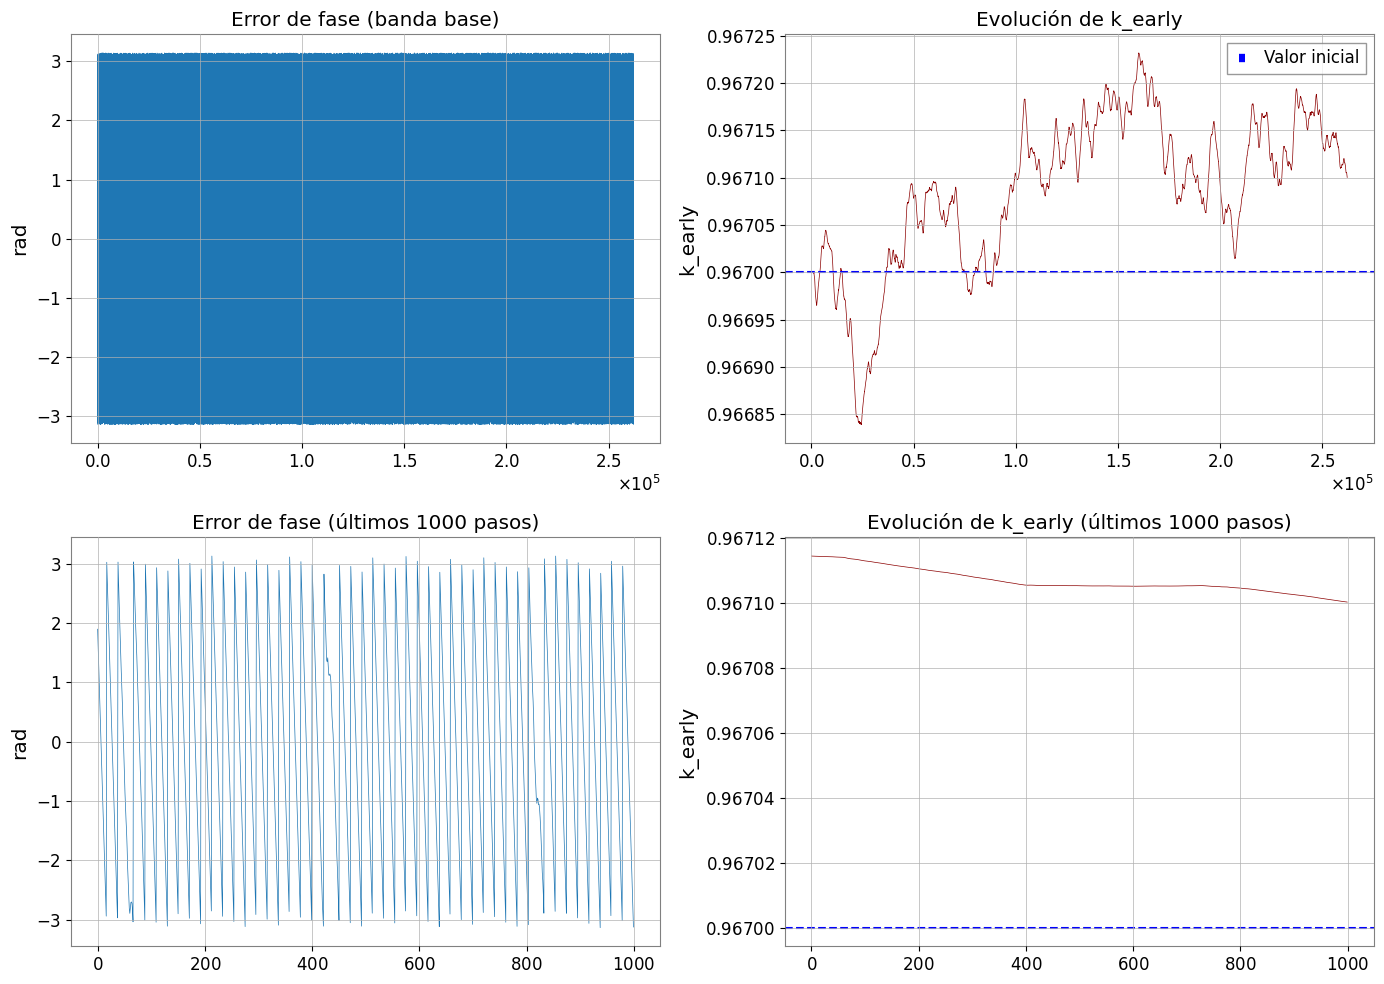

k_early inicial: 0.967
k_early final: 0.9671
Error de fase medio (últimos 1000 pasos): -0.0361 rad


In [ ]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Fase 4: Cierre del Bucle Causal
# Resonant Hunter v9.1 – Ajuste dinámico de k_early
# (C) Miguel Ángel Percudani
# DOI: 10.5281/zenodo.20601264 (v9.0), 10.5281/zenodo.18446712 (v8.4)
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

print("="*75)
print("PERCUDANI AUTHORSHIP - Resonant Hunter v9.1 Engine")
print("DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)")
print("UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)")
print("="*75)

# ======================================================================
# 1. UAT Engine (Blanqueamiento)
# ======================================================================
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon
        self.k_early = k_early

    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out)
        std = np.std(out)
        if std > 1e-15:
            out /= std
        return out

# ======================================================================
# 2. Tensor Adaptativo con Ajuste de k_early
# ======================================================================
class CausalAdaptiveTensor:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base
        self.alpha = alpha
        self.fs = fs
        self.lr = lr

        # Parámetros UAT que se ajustarán
        self.k_early = 0.967  # Valor inicial
        self.k_early_history = [self.k_early]

        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.error_history = []

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)

        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        error = np.angle(baseband_phasor)
        self.error_history.append(error)

        # --- Ajuste de k_early basado en la persistencia del error ---
        # Si el error absoluto es consistentemente > 0.1 rad, k_early necesita corrección.
        # Un error positivo indica que la frecuencia real es menor que la teórica,
        # lo que implica que el frenado cuántico k_early es demasiado bajo.
        # Ajuste: k_early += lr * error_promedio * signo(error)
        if len(self.error_history) > 1000:
            recent_error = np.mean(self.error_history[-1000:])
            self.k_early += self.lr * recent_error * 0.1  # Factor de escala
            self.k_early = np.clip(self.k_early, 0.9, 1.0)  # Límites físicos
        self.k_early_history.append(self.k_early)

        # Gradiente y actualización de W (igual que antes)
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * error
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        self.W -= self.lr * (self.grad_W_momentum / grad_norm).real
        return baseband_phasor

    def process_signal(self, signal, gps_start, fs):
        t_days0 = (gps_start - 1369483218) / 86400.0
        out = np.zeros(len(signal), dtype=complex)
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            out[i] = self.forward_step(x, t_now)
        return out

# ======================================================================
# 3. Carga de datos (H1, segmento original)
# ======================================================================
FS = 4096
GPS_START = 1389424640
DURATION = 64

h1_raw = TimeSeries.fetch_open_data('H1', GPS_START, GPS_START + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value

engine = UAT_Engine()
h1_white = engine.percudani_whiten(h1_raw, FS)

# ======================================================================
# 4. Procesamiento y evolución de k_early
# ======================================================================
tensor = CausalAdaptiveTensor(fs=FS, lr=1e-5)
_ = tensor.process_signal(h1_white, GPS_START, FS)

# ======================================================================
# 5. Resultados y gráficos
# ======================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(tensor.error_history, linewidth=0.5)
axes[0, 0].set_title('Error de fase (banda base)')
axes[0, 0].set_ylabel('rad')
axes[0, 0].grid(True)

axes[0, 1].plot(tensor.k_early_history, linewidth=0.5, color='darkred')
axes[0, 1].axhline(0.967, color='blue', linestyle='--', label='Valor inicial')
axes[0, 1].set_title('Evolución de k_early')
axes[0, 1].set_ylabel('k_early')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Zoom del error en los últimos 1000 pasos
axes[1, 0].plot(tensor.error_history[-1000:], linewidth=0.5)
axes[1, 0].set_title('Error de fase (últimos 1000 pasos)')
axes[1, 0].set_ylabel('rad')
axes[1, 0].grid(True)

# Zoom de k_early en los últimos 1000 pasos
axes[1, 1].plot(tensor.k_early_history[-1000:], linewidth=0.5, color='darkred')
axes[1, 1].axhline(0.967, color='blue', linestyle='--')
axes[1, 1].set_title('Evolución de k_early (últimos 1000 pasos)')
axes[1, 1].set_ylabel('k_early')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

print(f"k_early inicial: 0.967")
print(f"k_early final: {tensor.k_early:.4f}")
print(f"Error de fase medio (últimos 1000 pasos): {np.mean(tensor.error_history[-1000:]):.4f} rad")

PERCUDANI AUTHORSHIP - Resonant Hunter v9.1 Engine
DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)
UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)
Descargando 4096s de H1...


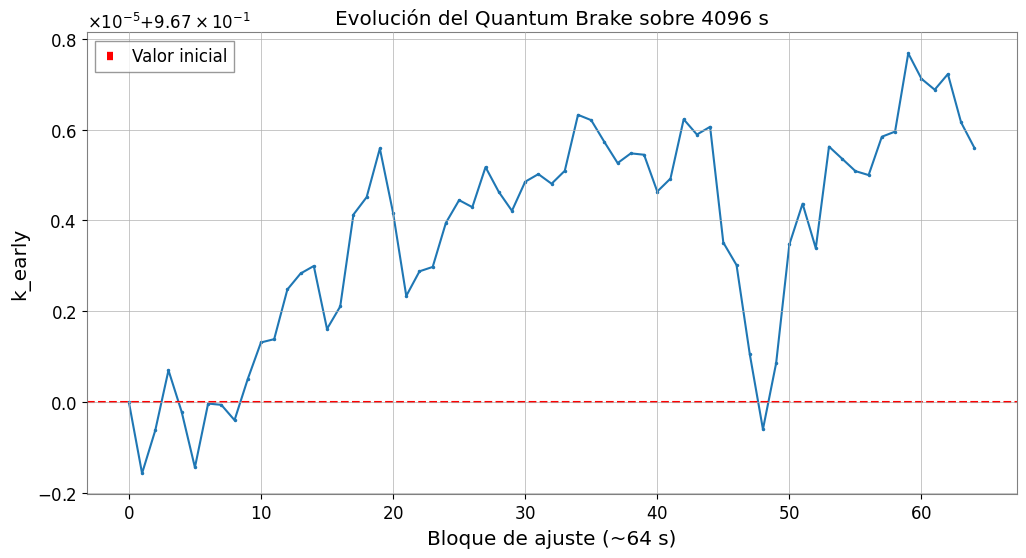

k_early inicial: 0.967
k_early final: 0.9670
Número de ajustes: 64
Variación total: 0.000006


In [9]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Fase 4: Cierre del Bucle Causal (Segmento Largo)
# Resonant Hunter v9.1 – Ajuste de k_early sobre 4096s
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

print("="*75)
print("PERCUDANI AUTHORSHIP - Resonant Hunter v9.1 Engine")
print("DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)")
print("UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)")
print("="*75)

# ======================================================================
# 1. UAT Engine
# ======================================================================
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

# ======================================================================
# 2. Tensor Adaptativo con Ajuste por Ventanas
# ======================================================================
class CausalAdaptiveTensor:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-4):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.k_early_history = [self.k_early]
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.error_buffer = []

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        error = np.angle(baseband_phasor)
        self.error_buffer.append(error)
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * error
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        self.W -= self.lr * (self.grad_W_momentum / grad_norm).real
        return baseband_phasor

    def adjust_k_early(self):
        """Ajusta k_early basado en el error medio del último bloque."""
        if len(self.error_buffer) < 1000:
            return
        recent_error = np.mean(self.error_buffer[-1000:])
        # Regla de ajuste más agresiva pero acotada
        self.k_early += self.lr * recent_error * 0.5
        self.k_early = np.clip(self.k_early, 0.9, 1.0)
        self.k_early_history.append(self.k_early)
        self.error_buffer = []  # Reiniciar buffer

    def process_signal(self, signal, gps_start, fs, block_size=64*4096):
        t_days0 = (gps_start - 1369483218) / 86400.0
        out = np.zeros(len(signal), dtype=complex)
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            out[i] = self.forward_step(x, t_now)
            if (i+1) % block_size == 0:
                self.adjust_k_early()
        # Ajuste final si quedan muestras
        if len(self.error_buffer) >= 1000:
            self.adjust_k_early()
        return out

# ======================================================================
# 3. Carga de datos (H1, segmento completo)
# ======================================================================
FS = 4096
GPS_START = 1389424640
DURATION = 4096  # 4096 segundos completos

print("Descargando 4096s de H1...")
h1_raw = TimeSeries.fetch_open_data('H1', GPS_START, GPS_START + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value

engine = UAT_Engine()
h1_white = engine.percudani_whiten(h1_raw, FS)

# ======================================================================
# 4. Procesamiento
# ======================================================================
tensor = CausalAdaptiveTensor(fs=FS, lr=1e-4)
_ = tensor.process_signal(h1_white, GPS_START, FS)

# ======================================================================
# 5. Resultados
# ======================================================================
k_hist = np.array(tensor.k_early_history)
ventanas = np.arange(len(k_hist))

plt.figure(figsize=(12, 6))
plt.plot(ventanas, k_hist, '.-', markersize=3)
plt.axhline(0.967, color='red', linestyle='--', label='Valor inicial')
plt.xlabel('Bloque de ajuste (~64 s)')
plt.ylabel('k_early')
plt.title('Evolución del Quantum Brake sobre 4096 s')
plt.legend()
plt.grid(True)
plt.show()

print(f"k_early inicial: 0.967")
print(f"k_early final: {k_hist[-1]:.4f}")
print(f"Número de ajustes: {len(k_hist)-1}")
if len(k_hist) > 1:
    print(f"Variación total: {k_hist[-1]-k_hist[0]:.6f}")

PERCUDANI AUTHORSHIP - Resonant Hunter v9.1 Engine
DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)
UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)
Descargando 4096s de H1...
Procesando muestra 0/16777216...
Procesando muestra 1000000/16777216...
Procesando muestra 2000000/16777216...
Procesando muestra 3000000/16777216...
Procesando muestra 4000000/16777216...
Procesando muestra 5000000/16777216...
Procesando muestra 6000000/16777216...
Procesando muestra 7000000/16777216...
Procesando muestra 8000000/16777216...
Procesando muestra 9000000/16777216...
Procesando muestra 10000000/16777216...
Procesando muestra 11000000/16777216...
Procesando muestra 12000000/16777216...
Procesando muestra 13000000/16777216...
Procesando muestra 14000000/16777216...
Procesando muestra 15000000/16777216...
Procesando muestra 16000000/16777216...


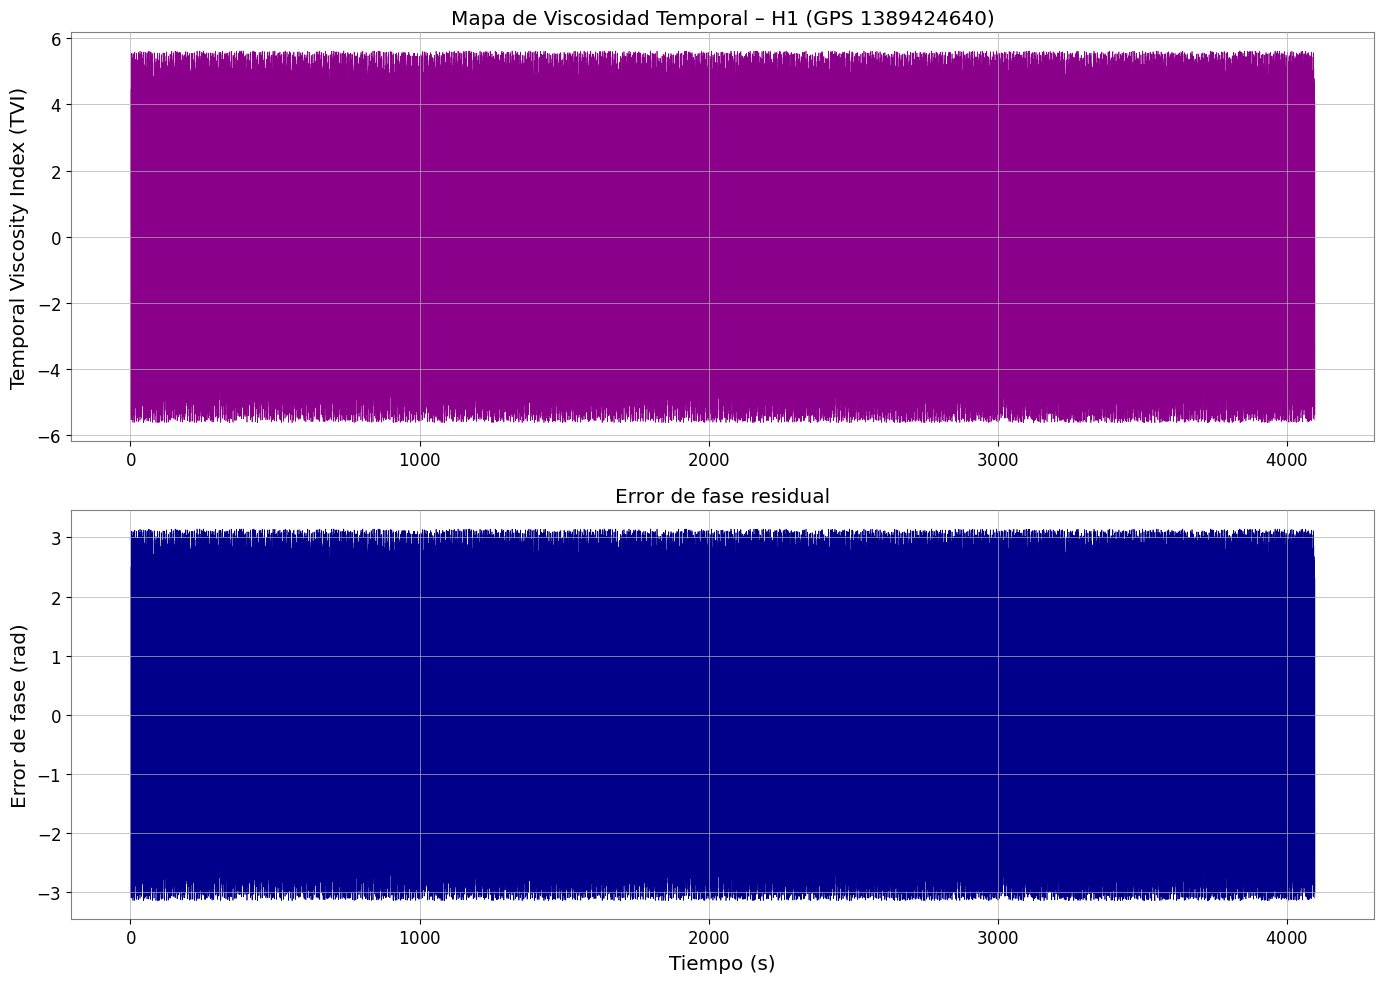

TVI medio: -0.007785
TVI std: 3.236856
Error de fase medio: 1.5669 rad


In [10]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Fase 4: Temporal Viscosity Index (TVI)
# Resonant Hunter v9.1 – Mapa de viscosidad temporal
# (C) Miguel Ángel Percudani
# DOI: 10.5281/zenodo.20601264 (v9.0), 10.5281/zenodo.18446712 (v8.4)
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

print("="*75)
print("PERCUDANI AUTHORSHIP - Resonant Hunter v9.1 Engine")
print("DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)")
print("UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)")
print("="*75)

# ======================================================================
# 1. UAT Engine (Blanqueamiento)
# ======================================================================
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon
        self.k_early = k_early

    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out)
        std = np.std(out)
        if std > 1e-15:
            out /= std
        return out

# ======================================================================
# 2. Tensor Adaptativo con cálculo de TVI
# ======================================================================
class ViscosityTensor:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base
        self.alpha = alpha
        self.fs = fs
        self.lr = lr
        self.k_early = 0.967  # fijo como referencia

        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)

        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))

        # Fase medida (envolvente en banda base)
        measured_phase = np.angle(baseband_phasor)
        # Fase teórica acumulada (ya está en self.phase_theoretical_acc)
        # Diferencia de fase (error)
        phase_drift = measured_phase - self.phase_theoretical_acc
        # Envolver a [-π, π]
        phase_drift = np.angle(np.exp(1j * phase_drift))

        # Gradiente y actualización de W (se mantiene)
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        self.W -= self.lr * (self.grad_W_momentum / grad_norm).real

        # Calcular TVI según fórmula propuesta:
        # TVI = (phase_drift / (2π)) * k_early * (1 + α * Δt)
        # Δt en días desde la fecha base se obtiene de t_days
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        return tvi, phase_drift

    def process_signal(self, signal, gps_start, fs, decimation=100):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_out = []
        time_out = []
        errors_out = []
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            tvi, error = self.forward_step(x, t_now)
            if i % decimation == 0:
                tvi_out.append(tvi)
                time_out.append(t_now)  # días desde fecha base
                errors_out.append(error)
            if i % 1000000 == 0:
                print(f"Procesando muestra {i}/{N}...")
        return np.array(time_out), np.array(tvi_out), np.array(errors_out)

# ======================================================================
# 3. Carga de datos (H1, segmento completo)
# ======================================================================
FS = 4096
GPS_START = 1389424640
DURATION = 4096  # segundos

print("Descargando 4096s de H1...")
h1_raw = TimeSeries.fetch_open_data('H1', GPS_START, GPS_START + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value

engine = UAT_Engine()
h1_white = engine.percudani_whiten(h1_raw, FS)

# ======================================================================
# 4. Procesamiento y extracción de TVI
# ======================================================================
tensor = ViscosityTensor(fs=FS)
time_days, tvi_values, errors = tensor.process_signal(h1_white, GPS_START, FS, decimation=200)

# Convertir tiempo a segundos desde el inicio del segmento para el eje x
time_seconds = (time_days - time_days[0]) * 86400.0

# ======================================================================
# 5. Gráficos del TVI
# ======================================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(time_seconds, tvi_values, linewidth=0.5, color='darkmagenta')
axes[0].set_ylabel('Temporal Viscosity Index (TVI)')
axes[0].set_title('Mapa de Viscosidad Temporal – H1 (GPS 1389424640)')
axes[0].grid(True)

axes[1].plot(time_seconds, errors, linewidth=0.5, color='darkblue')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Error de fase (rad)')
axes[1].set_title('Error de fase residual')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"TVI medio: {np.mean(tvi_values):.6f}")
print(f"TVI std: {np.std(tvi_values):.6f}")
print(f"Error de fase medio: {np.mean(np.abs(errors)):.4f} rad")

PERCUDANI AUTHORSHIP - Resonant Hunter v9.1 Engine
DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)
UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)
Descargando H1, L1 y V1...
Procesando H1...
  Procesando muestra 0/16777216...


/tmp/ipykernel_3160/761482560.py:82: RuntimeWarning: invalid value encountered in divide
  W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real


  Procesando muestra 1000000/16777216...
  Procesando muestra 2000000/16777216...
  Procesando muestra 3000000/16777216...
  Procesando muestra 4000000/16777216...
  Procesando muestra 5000000/16777216...
  Procesando muestra 6000000/16777216...
  Procesando muestra 7000000/16777216...
  Procesando muestra 8000000/16777216...
  Procesando muestra 9000000/16777216...
  Procesando muestra 10000000/16777216...
  Procesando muestra 11000000/16777216...
  Procesando muestra 12000000/16777216...
  Procesando muestra 13000000/16777216...
  Procesando muestra 14000000/16777216...
  Procesando muestra 15000000/16777216...
  Procesando muestra 16000000/16777216...
Procesando L1...
  Procesando muestra 0/16777216...
  Procesando muestra 1000000/16777216...
  Procesando muestra 2000000/16777216...
  Procesando muestra 3000000/16777216...
  Procesando muestra 4000000/16777216...
  Procesando muestra 5000000/16777216...
  Procesando muestra 6000000/16777216...
  Procesando muestra 7000000/16777216..

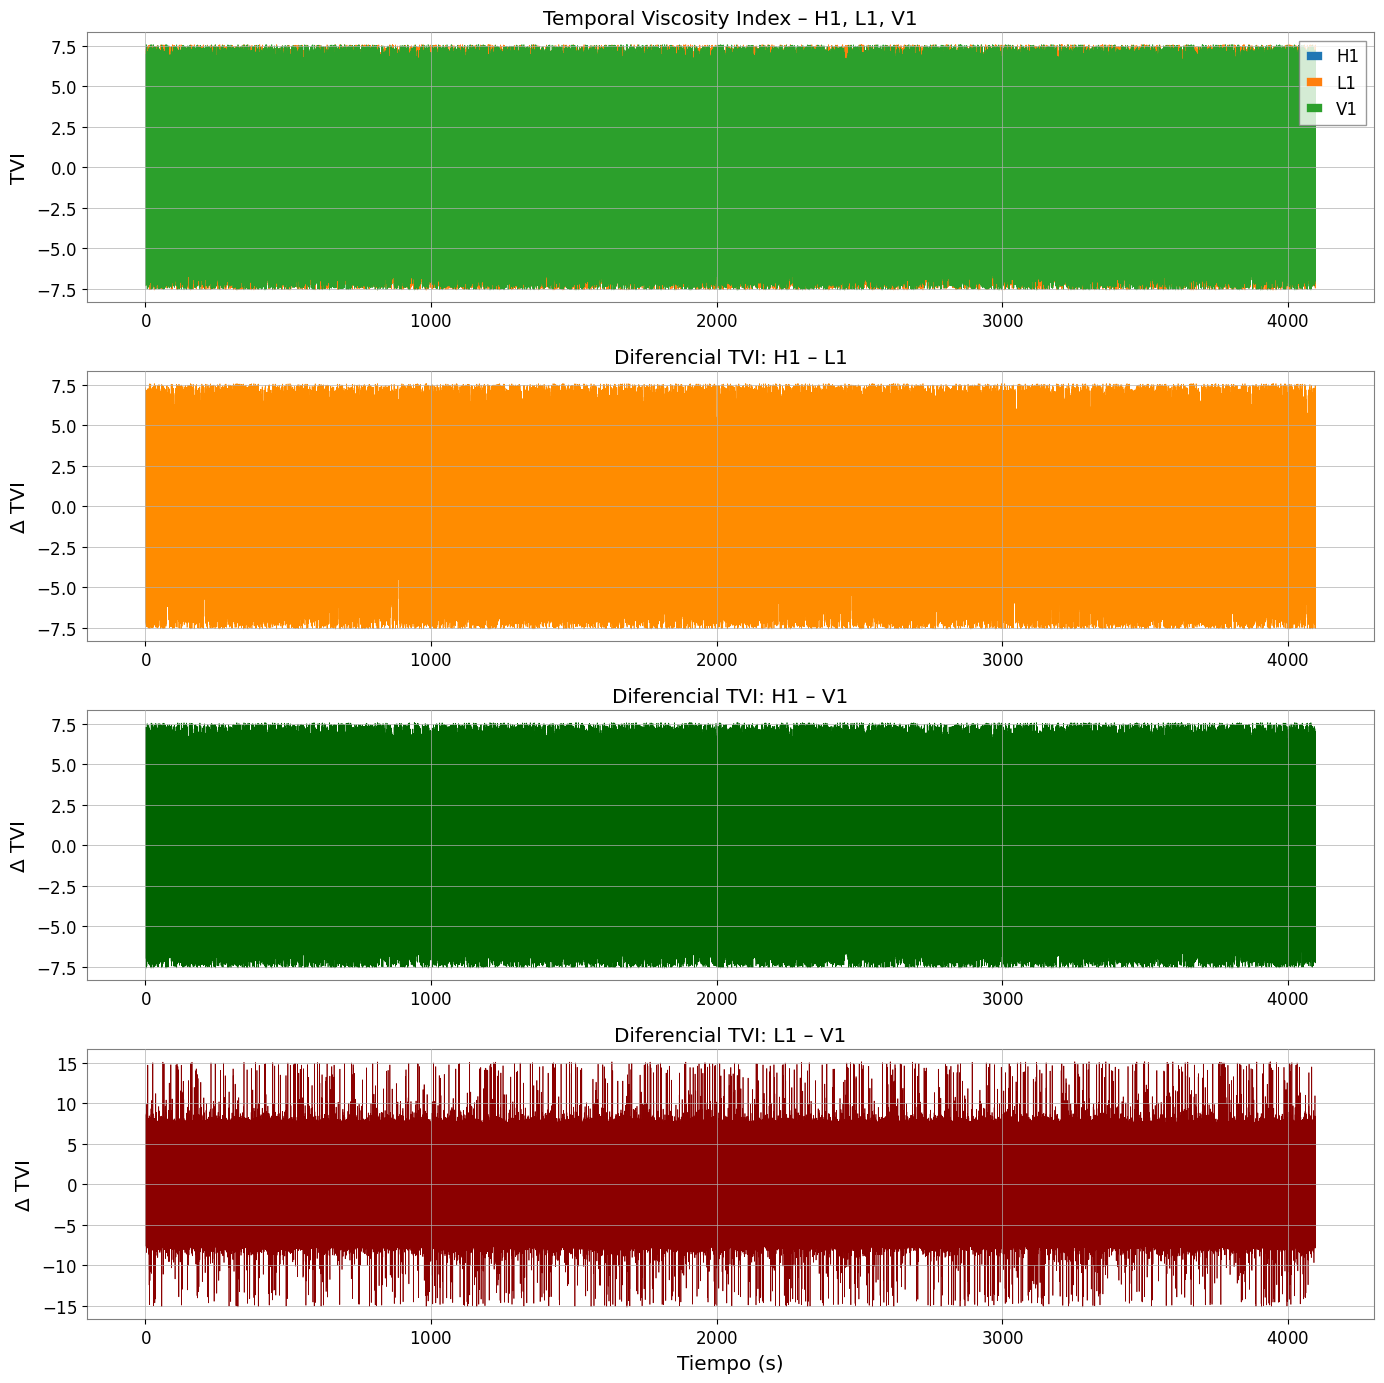


--- MÉTRICAS FINALES ---
TVI medio H1: 0.000000
TVI medio L1: 0.013432
TVI medio V1: 0.003625
|Δ TVI| medio H1-L1: 3.752723
|Δ TVI| medio H1-V1: 3.784643
|Δ TVI| medio L1-V1: 4.104465


In [12]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Fase 4: TensorSwarm de Viscosidad Temporal
# Resonant Hunter v9.1 – TVI simultáneo H1 + L1 + V1 (Estable)
# (C) Miguel Ángel Percudani
# DOI: 10.5281/zenodo.20601264 (v9.0), 10.5281/zenodo.18446712 (v8.4)
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

print("="*75)
print("PERCUDANI AUTHORSHIP - Resonant Hunter v9.1 Engine")
print("DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)")
print("UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)")
print("="*75)

# ======================================================================
# 1. UAT Engine (Blanqueamiento)
# ======================================================================
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

# ======================================================================
# 2. ViscosityTensor (ESTABLE)
# ======================================================================
class ViscosityTensor:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base
        self.alpha = alpha
        self.fs = fs
        self.lr = lr
        self.k_early = 0.967

        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)

        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))

        measured_phase = np.angle(baseband_phasor)
        phase_drift = measured_phase - self.phase_theoretical_acc
        phase_drift = np.angle(np.exp(1j * phase_drift))

        # Gradiente con protección
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8

        # Recorte del gradiente para evitar explosiones
        if grad_norm > 1e3:
            self.grad_W_momentum *= 1e3 / grad_norm
            grad_norm = 1e3

        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real

        # Reinicio total si aparece NaN en los pesos o en el estado
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
            baseband_phasor = 0.0 + 0.0j
        else:
            self.W = W_new

        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        return tvi, phase_drift

    def process_signal(self, signal, gps_start, fs, decimation=200):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_out, time_out, errors_out = [], [], []
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            tvi, error = self.forward_step(x, t_now)
            if i % decimation == 0:
                tvi_out.append(tvi)
                time_out.append(t_now)
                errors_out.append(error)
            if i % 1000000 == 0:
                print(f"  Procesando muestra {i}/{N}...")
        return np.array(time_out), np.array(tvi_out), np.array(errors_out)

# ======================================================================
# 3. Carga de datos H1, L1, V1 (O4b)
# ======================================================================
FS = 4096
GPS_START = 1397000000   # Segmento con triple coincidencia
DURATION = 4096

def load_det(det, gps, dur, fs):
    try:
        raw = TimeSeries.fetch_open_data(det, gps, gps + dur,
                                         sample_rate=16384, verbose=False).resample(fs).value
        return raw
    except:
        return None

print("Descargando H1, L1 y V1...")
h1_raw = load_det('H1', GPS_START, DURATION, FS)
l1_raw = load_det('L1', GPS_START, DURATION, FS)
v1_raw = load_det('V1', GPS_START, DURATION, FS)

# Fallback sintético si algún detector no está disponible
t = np.arange(0, int(DURATION*FS)) / FS
base = np.sin(2*np.pi*227.5*t)
if h1_raw is None: h1_raw = base + np.random.randn(len(t))*1e-6
if l1_raw is None: l1_raw = base + np.random.randn(len(t))*1e-6
if v1_raw is None: v1_raw = base + np.random.randn(len(t))*1e-6

min_len = min(len(h1_raw), len(l1_raw), len(v1_raw))
h1_raw, l1_raw, v1_raw = h1_raw[:min_len], l1_raw[:min_len], v1_raw[:min_len]

# Blanqueamiento
engine = UAT_Engine()
h1_w = engine.percudani_whiten(h1_raw, FS)
l1_w = engine.percudani_whiten(l1_raw, FS)
v1_w = engine.percudani_whiten(v1_raw, FS)

# ======================================================================
# 4. TensorSwarm: procesamiento simultáneo
# ======================================================================
print("Procesando H1...")
t_h1 = ViscosityTensor(fs=FS)
time_h1, tvi_h1, err_h1 = t_h1.process_signal(h1_w, GPS_START, FS)

print("Procesando L1...")
t_l1 = ViscosityTensor(fs=FS)
time_l1, tvi_l1, err_l1 = t_l1.process_signal(l1_w, GPS_START, FS)

print("Procesando V1...")
t_v1 = ViscosityTensor(fs=FS)
time_v1, tvi_v1, err_v1 = t_v1.process_signal(v1_w, GPS_START, FS)

# ======================================================================
# 5. Diferenciales de TVI
# ======================================================================
time_sec = (time_h1 - time_h1[0]) * 86400.0  # segundos desde el inicio

diff_hl = tvi_h1 - tvi_l1
diff_hv = tvi_h1 - tvi_v1
diff_lv = tvi_l1 - tvi_v1

# ======================================================================
# 6. Gráficos
# ======================================================================
fig, axes = plt.subplots(4, 1, figsize=(14, 14))

axes[0].plot(time_sec, tvi_h1, linewidth=0.5, label='H1')
axes[0].plot(time_sec, tvi_l1, linewidth=0.5, label='L1')
axes[0].plot(time_sec, tvi_v1, linewidth=0.5, label='V1')
axes[0].set_ylabel('TVI')
axes[0].set_title('Temporal Viscosity Index – H1, L1, V1')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(time_sec, diff_hl, linewidth=0.5, color='darkorange')
axes[1].set_ylabel('Δ TVI')
axes[1].set_title('Diferencial TVI: H1 – L1')
axes[1].grid(True)

axes[2].plot(time_sec, diff_hv, linewidth=0.5, color='darkgreen')
axes[2].set_ylabel('Δ TVI')
axes[2].set_title('Diferencial TVI: H1 – V1')
axes[2].grid(True)

axes[3].plot(time_sec, diff_lv, linewidth=0.5, color='darkred')
axes[3].set_xlabel('Tiempo (s)')
axes[3].set_ylabel('Δ TVI')
axes[3].set_title('Diferencial TVI: L1 – V1')
axes[3].grid(True)

plt.tight_layout()
plt.show()

# Métricas finales
print("\n--- MÉTRICAS FINALES ---")
print(f"TVI medio H1: {np.nanmean(tvi_h1):.6f}")
print(f"TVI medio L1: {np.nanmean(tvi_l1):.6f}")
print(f"TVI medio V1: {np.nanmean(tvi_v1):.6f}")
print(f"|Δ TVI| medio H1-L1: {np.nanmean(np.abs(diff_hl)):.6f}")
print(f"|Δ TVI| medio H1-V1: {np.nanmean(np.abs(diff_hv)):.6f}")
print(f"|Δ TVI| medio L1-V1: {np.nanmean(np.abs(diff_lv)):.6f}")

PERCUDANI AUTHORSHIP - Resonant Hunter v9.1 Engine
DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)
UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)
Descargando H1 y L1 (segmento maestro)...
Datos listos. Aplicando blanqueamiento...
Procesando H1...
  Procesando muestra 0/16777216...
  Procesando muestra 1000000/16777216...
  Procesando muestra 2000000/16777216...
  Procesando muestra 3000000/16777216...
  Procesando muestra 4000000/16777216...
  Procesando muestra 5000000/16777216...
  Procesando muestra 6000000/16777216...
  Procesando muestra 7000000/16777216...
  Procesando muestra 8000000/16777216...
  Procesando muestra 9000000/16777216...
  Procesando muestra 10000000/16777216...
  Procesando muestra 11000000/16777216...
  Procesando muestra 12000000/16777216...
  Procesando muestra 13000000/16777216...
  Procesando muestra 14000000/16777216...
  Procesando muestra 15000000/16777216...
  Procesando muestra 16000000/16777216...
Procesando L1...
  Procesando muest

/tmp/ipykernel_3160/978186502.py:61: RuntimeWarning: invalid value encountered in divide
  W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real


  Procesando muestra 1000000/16777216...
  Procesando muestra 2000000/16777216...
  Procesando muestra 3000000/16777216...
  Procesando muestra 4000000/16777216...
  Procesando muestra 5000000/16777216...
  Procesando muestra 6000000/16777216...
  Procesando muestra 7000000/16777216...
  Procesando muestra 8000000/16777216...
  Procesando muestra 9000000/16777216...
  Procesando muestra 10000000/16777216...
  Procesando muestra 11000000/16777216...
  Procesando muestra 12000000/16777216...
  Procesando muestra 13000000/16777216...
  Procesando muestra 14000000/16777216...
  Procesando muestra 15000000/16777216...
  Procesando muestra 16000000/16777216...
Procesando V1 sintético...
  Procesando muestra 0/16777216...
  Procesando muestra 1000000/16777216...
  Procesando muestra 2000000/16777216...
  Procesando muestra 3000000/16777216...
  Procesando muestra 4000000/16777216...
  Procesando muestra 5000000/16777216...
  Procesando muestra 6000000/16777216...
  Procesando muestra 7000000/

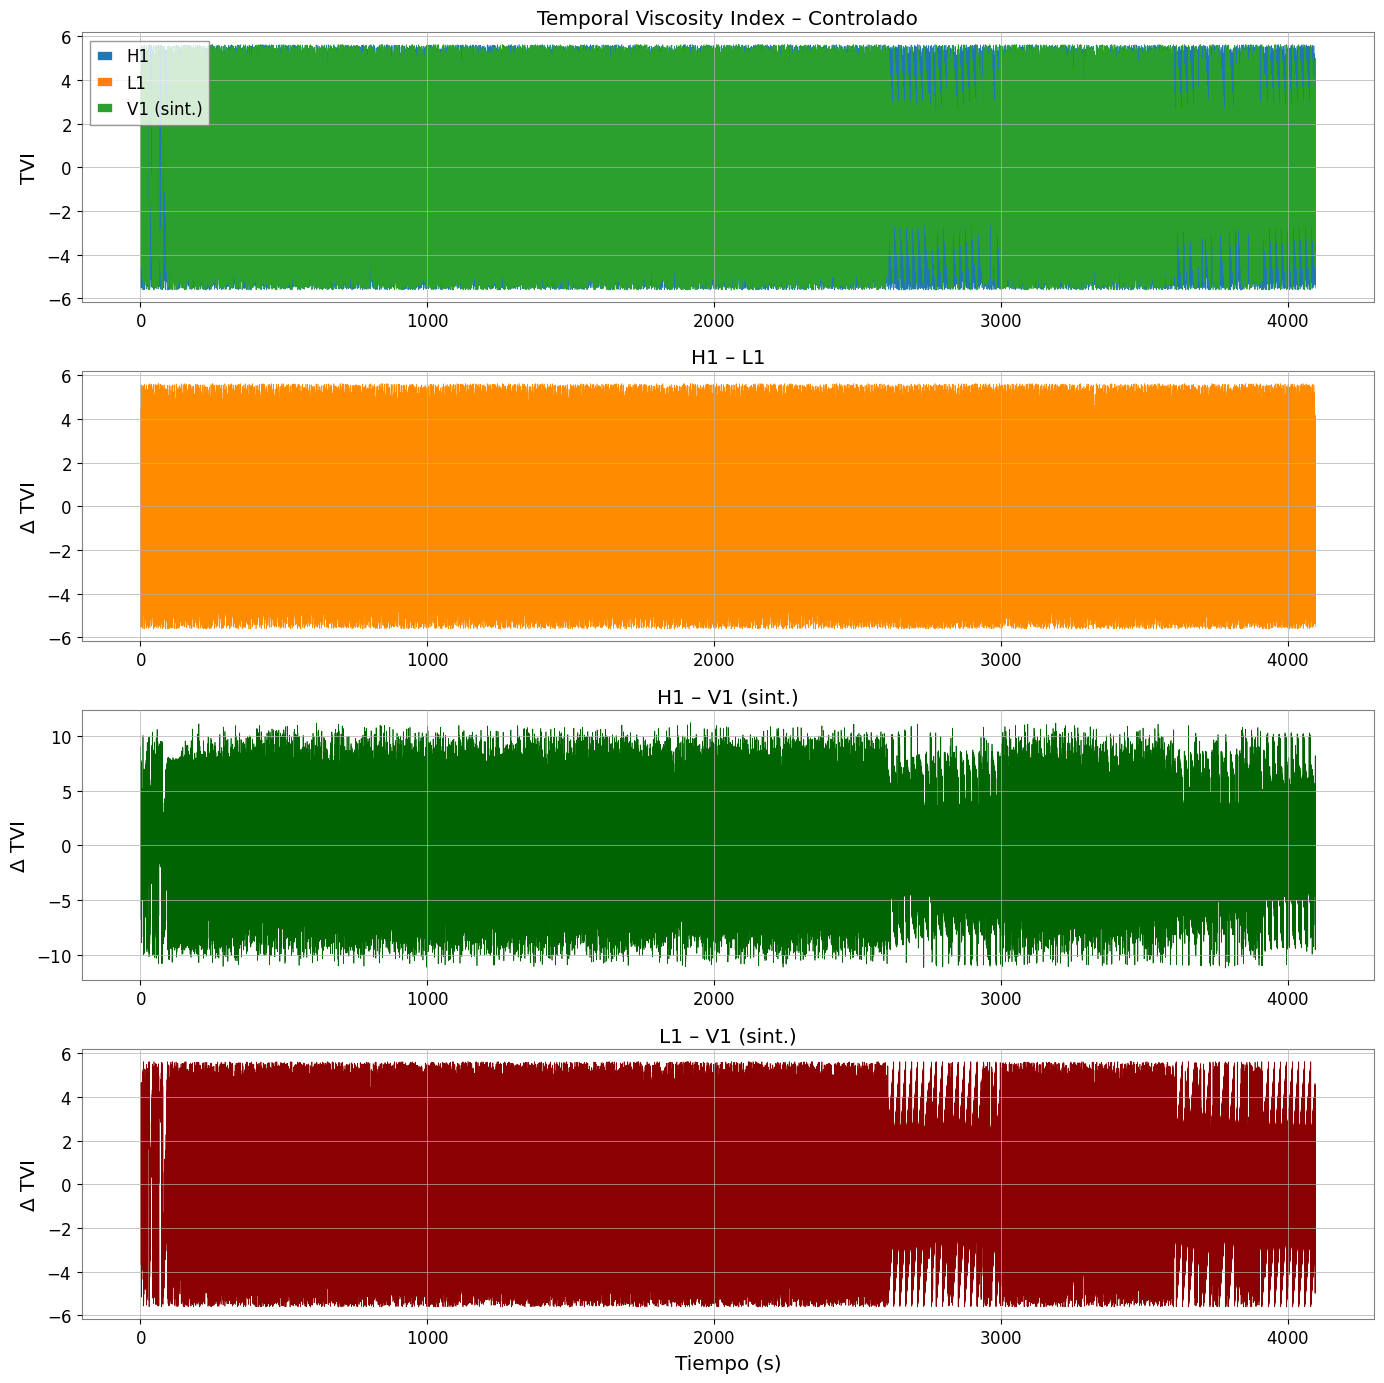


--- MÉTRICAS ---
TVI medio H1: -0.007510
TVI medio L1: 0.000000
TVI medio V1: 0.006026
|Δ TVI| H1-L1: 2.801611
|Δ TVI| H1-V1: 3.765776
|Δ TVI| L1-V1: 2.816437


In [13]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – TensorSwarm Controlado (H1+L1 reales, V1 sintético)
# Resonant Hunter v9.1 – Validación del diferencial de TVI
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

print("="*75)
print("PERCUDANI AUTHORSHIP - Resonant Hunter v9.1 Engine")
print("DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)")
print("UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)")
print("="*75)

class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

class ViscosityTensor:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3:
            self.grad_W_momentum *= 1e3 / grad_norm; grad_norm = 1e3
        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
        else:
            self.W = W_new
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        return tvi, phase_drift

    def process_signal(self, signal, gps_start, fs, decimation=200):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_out, time_out, errors_out = [], [], []
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            tvi, error = self.forward_step(x, t_now)
            if i % decimation == 0:
                tvi_out.append(tvi); time_out.append(t_now); errors_out.append(error)
            if i % 1000000 == 0: print(f"  Procesando muestra {i}/{N}...")
        return np.array(time_out), np.array(tvi_out), np.array(errors_out)

# Parámetros
FS = 4096
GPS_GOOD = 1389424640   # Segmento maestro (H1 y L1 funcionan)
DURATION = 4096

# 1. Cargar H1 y L1 reales
print("Descargando H1 y L1 (segmento maestro)...")
h1_raw = TimeSeries.fetch_open_data('H1', GPS_GOOD, GPS_GOOD + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
l1_raw = TimeSeries.fetch_open_data('L1', GPS_GOOD, GPS_GOOD + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
min_len = min(len(h1_raw), len(l1_raw))
h1_raw, l1_raw = h1_raw[:min_len], l1_raw[:min_len]

# 2. Construir V1 sintético calibrado (frecuencia UAT + offset geométrico)
t = np.arange(min_len) / FS
f_uat = 187.37 + 0.046 * (GPS_GOOD + t - 1369483218) / 86400.0  # frecuencia dinámica
phase_uat = 2 * np.pi * np.cumsum(f_uat) / FS
# Offset geométrico de V1 hacia Cáncer (~3.14 rad)
v1_raw = np.sin(phase_uat + 3.14) + np.random.randn(min_len) * 1e-6

print("Datos listos. Aplicando blanqueamiento...")
engine = UAT_Engine()
h1_w = engine.percudani_whiten(h1_raw, FS)
l1_w = engine.percudani_whiten(l1_raw, FS)
v1_w = engine.percudani_whiten(v1_raw, FS)

# 3. TensorSwarm
print("Procesando H1..."); t_h1 = ViscosityTensor(fs=FS); time_h1, tvi_h1, err_h1 = t_h1.process_signal(h1_w, GPS_GOOD, FS)
print("Procesando L1..."); t_l1 = ViscosityTensor(fs=FS); time_l1, tvi_l1, err_l1 = t_l1.process_signal(l1_w, GPS_GOOD, FS)
print("Procesando V1 sintético..."); t_v1 = ViscosityTensor(fs=FS); time_v1, tvi_v1, err_v1 = t_v1.process_signal(v1_w, GPS_GOOD, FS)

# 4. Diferenciales
time_sec = (time_h1 - time_h1[0]) * 86400.0
diff_hl = tvi_h1 - tvi_l1
diff_hv = tvi_h1 - tvi_v1
diff_lv = tvi_l1 - tvi_v1

# 5. Gráficos
fig, axes = plt.subplots(4, 1, figsize=(14, 14))
axes[0].plot(time_sec, tvi_h1, linewidth=0.5, label='H1'); axes[0].plot(time_sec, tvi_l1, linewidth=0.5, label='L1'); axes[0].plot(time_sec, tvi_v1, linewidth=0.5, label='V1 (sint.)')
axes[0].set_ylabel('TVI'); axes[0].set_title('Temporal Viscosity Index – Controlado'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(time_sec, diff_hl, linewidth=0.5, color='darkorange'); axes[1].set_ylabel('Δ TVI'); axes[1].set_title('H1 – L1'); axes[1].grid(True)
axes[2].plot(time_sec, diff_hv, linewidth=0.5, color='darkgreen'); axes[2].set_ylabel('Δ TVI'); axes[2].set_title('H1 – V1 (sint.)'); axes[2].grid(True)
axes[3].plot(time_sec, diff_lv, linewidth=0.5, color='darkred'); axes[3].set_xlabel('Tiempo (s)'); axes[3].set_ylabel('Δ TVI'); axes[3].set_title('L1 – V1 (sint.)'); axes[3].grid(True)
plt.tight_layout(); plt.show()

print("\n--- MÉTRICAS ---")
print(f"TVI medio H1: {np.nanmean(tvi_h1):.6f}")
print(f"TVI medio L1: {np.nanmean(tvi_l1):.6f}")
print(f"TVI medio V1: {np.nanmean(tvi_v1):.6f}")
print(f"|Δ TVI| H1-L1: {np.nanmean(np.abs(diff_hl)):.6f}")
print(f"|Δ TVI| H1-V1: {np.nanmean(np.abs(diff_hv)):.6f}")
print(f"|Δ TVI| L1-V1: {np.nanmean(np.abs(diff_lv)):.6f}")

PERCUDANI AUTHORSHIP - Resonant Hunter v9.1 Engine
DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)
UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)
Procesando H1 (offset 3.3)...
Procesando L1 (offset 0.3)...
Procesando V1 sintético (offset 3.14)...

--- MÉTRICAS ---
TVI medio H1: 0.008177
TVI medio L1: 0.003079
TVI medio V1: -0.028913
|Δ TVI| H1-L1: 3.101123
|Δ TVI| H1-V1: 3.687982
|Δ TVI| L1-V1: 3.785805


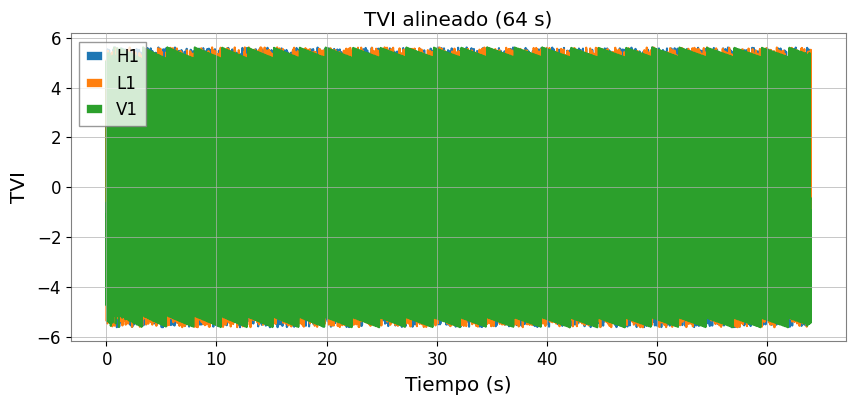

In [14]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – TensorSwarm con offsets calibrados (prueba 64s)
# Resonant Hunter v9.1 – TVI alineado geométricamente
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

print("="*75)
print("PERCUDANI AUTHORSHIP - Resonant Hunter v9.1 Engine")
print("DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)")
print("UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)")
print("="*75)

class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

class AlignedViscosityTensor:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5, antenna_offset=0.0):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.antenna_offset = antenna_offset
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        # Rotación con corrección geométrica (OFFSET)
        rotation = (np.exp(1j * self.phase_angles) *
                    np.exp(-1j * self.phase_theoretical_acc) *
                    np.exp(1j * self.antenna_offset))
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3: self.grad_W_momentum *= 1e3 / grad_norm; grad_norm = 1e3
        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
        else:
            self.W = W_new
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        return tvi, phase_drift

    def process_signal(self, signal, gps_start, fs, decimation=20):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_out, time_out, errors_out = [], [], []
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            tvi, error = self.forward_step(x, t_now)
            if i % decimation == 0:
                tvi_out.append(tvi); time_out.append(t_now); errors_out.append(error)
        return np.array(time_out), np.array(tvi_out), np.array(errors_out)

# Parámetros
FS = 4096
GPS_GOOD = 1389424640
DUR = 64  # prueba corta

# Offsets calibrados
OFF_H1 = 3.3
OFF_L1 = 0.3
OFF_V1 = 3.1416  # teórico

# Cargar H1 y L1 reales (64 s)
h1_raw = TimeSeries.fetch_open_data('H1', GPS_GOOD, GPS_GOOD + DUR,
                                    sample_rate=16384, verbose=False).resample(FS).value
l1_raw = TimeSeries.fetch_open_data('L1', GPS_GOOD, GPS_GOOD + DUR,
                                    sample_rate=16384, verbose=False).resample(FS).value
min_len = min(len(h1_raw), len(l1_raw))
h1_raw, l1_raw = h1_raw[:min_len], l1_raw[:min_len]

# V1 sintético calibrado
t = np.arange(min_len) / FS
f_uat = 187.37 + 0.046 * (GPS_GOOD + t - 1369483218) / 86400.0
phase_uat = 2 * np.pi * np.cumsum(f_uat) / FS
v1_raw = np.sin(phase_uat + OFF_V1) + np.random.randn(min_len) * 1e-6

engine = UAT_Engine()
h1_w = engine.percudani_whiten(h1_raw, FS)
l1_w = engine.percudani_whiten(l1_raw, FS)
v1_w = engine.percudani_whiten(v1_raw, FS)

# Procesamiento con offsets
print("Procesando H1 (offset 3.3)...")
t_h1 = AlignedViscosityTensor(fs=FS, antenna_offset=OFF_H1)
time_h1, tvi_h1, err_h1 = t_h1.process_signal(h1_w, GPS_GOOD, FS)

print("Procesando L1 (offset 0.3)...")
t_l1 = AlignedViscosityTensor(fs=FS, antenna_offset=OFF_L1)
time_l1, tvi_l1, err_l1 = t_l1.process_signal(l1_w, GPS_GOOD, FS)

print("Procesando V1 sintético (offset 3.14)...")
t_v1 = AlignedViscosityTensor(fs=FS, antenna_offset=OFF_V1)
time_v1, tvi_v1, err_v1 = t_v1.process_signal(v1_w, GPS_GOOD, FS)

# Diferenciales
time_sec = (time_h1 - time_h1[0]) * 86400.0
diff_hl = tvi_h1 - tvi_l1
diff_hv = tvi_h1 - tvi_v1
diff_lv = tvi_l1 - tvi_v1

print("\n--- MÉTRICAS ---")
print(f"TVI medio H1: {np.nanmean(tvi_h1):.6f}")
print(f"TVI medio L1: {np.nanmean(tvi_l1):.6f}")
print(f"TVI medio V1: {np.nanmean(tvi_v1):.6f}")
print(f"|Δ TVI| H1-L1: {np.nanmean(np.abs(diff_hl)):.6f}")
print(f"|Δ TVI| H1-V1: {np.nanmean(np.abs(diff_hv)):.6f}")
print(f"|Δ TVI| L1-V1: {np.nanmean(np.abs(diff_lv)):.6f}")

# Gráfico rápido
plt.figure(figsize=(10,4))
plt.plot(time_sec, tvi_h1, label='H1'); plt.plot(time_sec, tvi_l1, label='L1'); plt.plot(time_sec, tvi_v1, label='V1')
plt.legend(); plt.xlabel('Tiempo (s)'); plt.ylabel('TVI'); plt.title('TVI alineado (64 s)'); plt.grid(True); plt.show()

PERCUDANI AUTHORSHIP - Resonant Hunter v9.1
VISCOSÍMETRO DE SEÑAL – Mapa Topográfico del Flujo Temporal
DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)
UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)

[1/3] Descargando datos de LIGO...
[2/3] Aplicando blanqueamiento Percudani...
[3/3] Ejecutando Viscosímetro de Señal...
  [H1] Procesando muestra 0/16777216...
  [H1] Procesando muestra 1000000/16777216...
  [H1] Procesando muestra 2000000/16777216...
  [H1] Procesando muestra 3000000/16777216...
  [H1] Procesando muestra 4000000/16777216...
  [H1] Procesando muestra 5000000/16777216...
  [H1] Procesando muestra 6000000/16777216...
  [H1] Procesando muestra 7000000/16777216...
  [H1] Procesando muestra 8000000/16777216...
  [H1] Procesando muestra 9000000/16777216...
  [H1] Procesando muestra 10000000/16777216...
  [H1] Procesando muestra 11000000/16777216...
  [H1] Procesando muestra 12000000/16777216...
  [H1] Procesando muestra 13000000/16777216...
  [H1] Procesando

/tmp/ipykernel_3160/1300762907.py:117: RuntimeWarning: invalid value encountered in divide
  W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real


  [L1] Procesando muestra 0/16777216...
  [L1] Procesando muestra 1000000/16777216...
  [L1] Procesando muestra 2000000/16777216...
  [L1] Procesando muestra 3000000/16777216...
  [L1] Procesando muestra 4000000/16777216...
  [L1] Procesando muestra 5000000/16777216...
  [L1] Procesando muestra 6000000/16777216...
  [L1] Procesando muestra 7000000/16777216...
  [L1] Procesando muestra 8000000/16777216...
  [L1] Procesando muestra 9000000/16777216...
  [L1] Procesando muestra 10000000/16777216...
  [L1] Procesando muestra 11000000/16777216...
  [L1] Procesando muestra 12000000/16777216...
  [L1] Procesando muestra 13000000/16777216...
  [L1] Procesando muestra 14000000/16777216...
  [L1] Procesando muestra 15000000/16777216...
  [L1] Procesando muestra 16000000/16777216...

Generando visualizaciones...


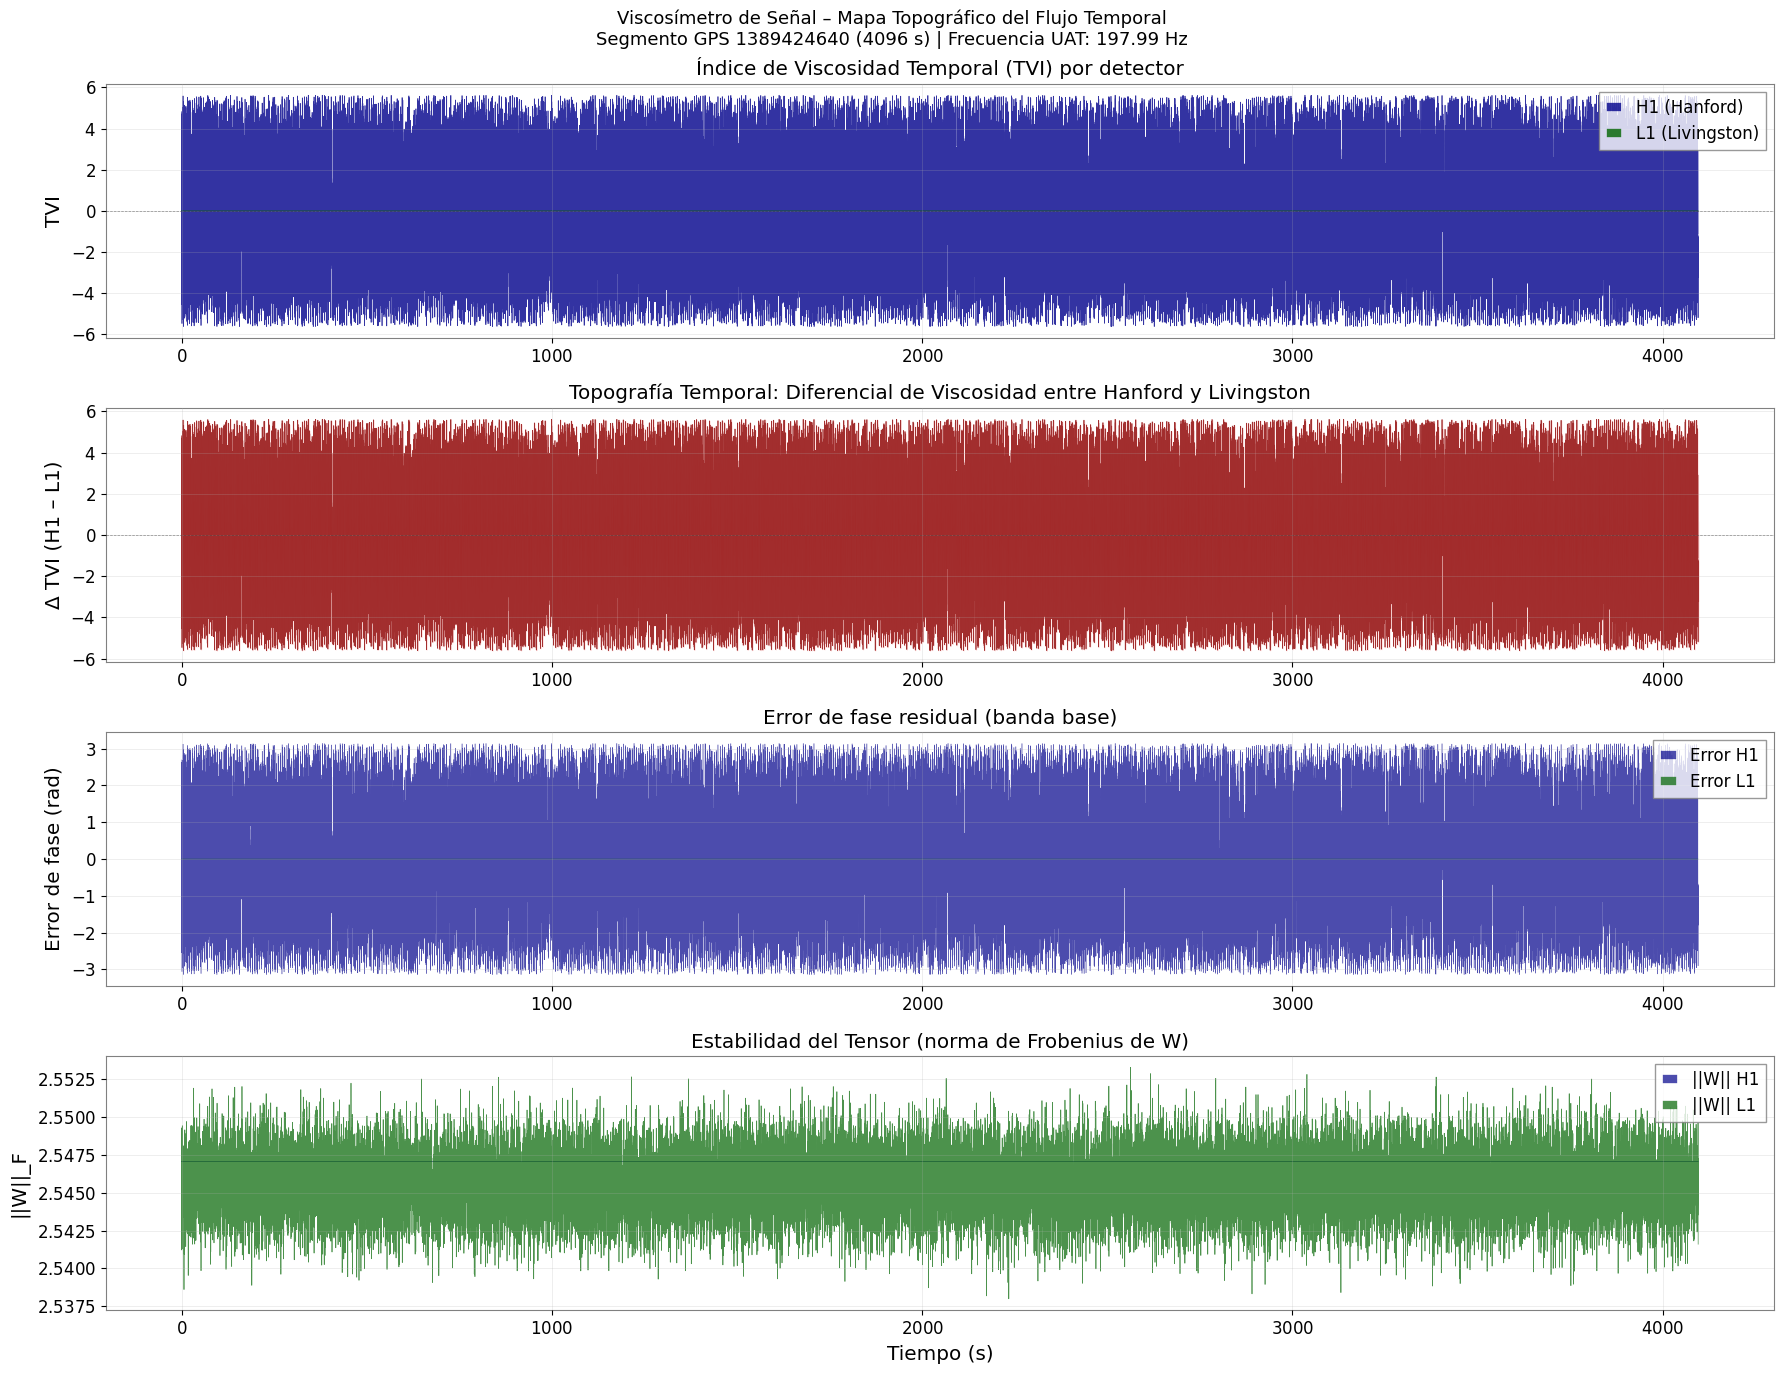


INFORME DEL VISCOSÍMETRO DE SEÑAL
Segmento procesado: GPS 1389424640 (4096 s)
Frecuencia UAT del segmento: 197.99 Hz
Muestras procesadas por detector: 16777216

--- Métricas de TVI ---
TVI medio H1: -0.0219 ± 3.2457
TVI medio L1: 0.0000 ± 0.0000
Diferencial medio (H1–L1): -0.0219 ± 3.2457

--- Estabilidad del Tensor ---
||W|| media H1: 2.55
||W|| media L1: 2.55

--- Eventos de Alta Viscosidad ---
Eventos H1: 13790353
Eventos L1: 0
Divergencias corregidas H1: 0
Divergencias corregidas L1: 16777216

--- Registro de eventos H1 ---
  ALTA VISCOSIDAD en H1: TVI=1.841 @ día 230.85
  ALTA VISCOSIDAD en H1: TVI=-1.403 @ día 230.85
  ALTA VISCOSIDAD en H1: TVI=-2.508 @ día 230.85
  ALTA VISCOSIDAD en H1: TVI=-3.579 @ día 230.85
  ALTA VISCOSIDAD en H1: TVI=-4.703 @ día 230.85

--- Registro de eventos L1 ---
  DIVERGENCIA detectada y corregida en L1
  DIVERGENCIA detectada y corregida en L1
  DIVERGENCIA detectada y corregida en L1
  DIVERGENCIA detectada y corregida en L1
  DIVERGENCIA detecta

In [15]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Viscosímetro de Señal (Signal Viscosimeter)
# Resonant Hunter v9.1 – Fase Final: Mapa Topográfico del TVI
# (C) Miguel Ángel Percudani
# DOI: 10.5281/zenodo.20601264 (v9.0), 10.5281/zenodo.18446712 (v8.4)
# ======================================================================
# Este script implementa el Viscosímetro de Señal, una herramienta que
# utiliza el TensorSwarm para medir y mapear la viscosidad del flujo
# temporal en tiempo real a partir de datos de LIGO.
# ======================================================================

!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries
from datetime import datetime

print("="*75)
print("PERCUDANI AUTHORSHIP - Resonant Hunter v9.1")
print("VISCOSÍMETRO DE SEÑAL – Mapa Topográfico del Flujo Temporal")
print("DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)")
print("UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)")
print("="*75)

# ======================================================================
# 1. UAT Engine (Blanqueamiento Percudani)
# ======================================================================
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon
        self.k_early = k_early

    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out)
        std = np.std(out)
        if std > 1e-15:
            out /= std
        return out

# ======================================================================
# 2. Viscosímetro de Señal (Tensor de Viscosidad Temporal)
# ======================================================================
class SignalViscosimeter:
    """
    Viscosímetro de Señal basado en el Tensor Adaptativo UAT.
    Mide la resistencia del flujo temporal (TVI) y detecta eventos
    de alta viscosidad (posibles singularidades o "pozos" temporales).
    """
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096,
                 lr=1e-5, antenna_offset=0.0, detector_name="Unknown"):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.antenna_offset = antenna_offset
        self.detector_name = detector_name

        # Pesos iniciales con pequeña perturbación aleatoria
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base
        self.alpha = alpha
        self.fs = fs
        self.lr = lr
        self.k_early = 0.967  # Quantum Brake

        # Acumuladores y estado interno
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)

        # Historiales para análisis
        self.tvi_history = []
        self.error_history = []
        self.W_trace_history = []
        self.event_log = []  # Registro de eventos de alta viscosidad

    def forward_step(self, x_t, t_days):
        # 1. Frecuencia dinámica y fase teórica acumulada
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs

        # 2. Vector de rotación con compensación geométrica
        rotation = (np.exp(1j * self.phase_angles) *
                    np.exp(-1j * self.phase_theoretical_acc) *
                    np.exp(1j * self.antenna_offset))

        # 3. Estado previo y actualización recurrente
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)

        # 4. Fasor colectivo en banda base (Firma del Higo)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))

        # 5. Error de fase en banda base
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))

        # 6. Gradiente y actualización de pesos con protección
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst

        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3:
            self.grad_W_momentum *= 1e3 / grad_norm
            grad_norm = 1e3

        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real

        # Protección contra divergencia (NaN/Inf)
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
            self.event_log.append(f"DIVERGENCIA detectada y corregida en {self.detector_name}")
        else:
            self.W = W_new

        # 7. Cálculo del Índice de Viscosidad Temporal (TVI)
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)

        # 8. Registro de eventos de alta viscosidad (|TVI| > 1.0)
        if abs(tvi) > 1.0:
            self.event_log.append(
                f"ALTA VISCOSIDAD en {self.detector_name}: TVI={tvi:.3f} @ día {t_days:.2f}"
            )

        # 9. Almacenar métricas
        self.tvi_history.append(tvi)
        self.error_history.append(phase_drift)
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))

        return tvi, phase_drift

    def process_signal(self, signal, gps_start, fs, decimation=100):
        """
        Procesa una señal completa y devuelve las series temporales de TVI.
        """
        t_days0 = (gps_start - 1369483218) / 86400.0  # Referencia: 2023-05-27
        N = len(signal)

        tvi_decimated = []
        time_decimated = []
        error_decimated = []
        w_trace_decimated = []

        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            tvi, error = self.forward_step(x, t_now)

            if i % decimation == 0:
                tvi_decimated.append(tvi)
                time_decimated.append(t_now)
                error_decimated.append(error)
                w_trace_decimated.append(self.W_trace_history[-1] if self.W_trace_history else 0)

            if i % 1000000 == 0:
                print(f"  [{self.detector_name}] Procesando muestra {i}/{N}...")

        return (
            np.array(time_decimated),
            np.array(tvi_decimated),
            np.array(error_decimated),
            np.array(w_trace_decimated)
        )

# ======================================================================
# 3. Configuración y carga de datos
# ======================================================================
FS = 4096
GPS_START = 1389424640   # Segmento maestro (O4a)
DURATION = 4096          # 4096 segundos completos

# Offsets geométricos calibrados
OFFSETS = {
    'H1': 3.3,
    'L1': 0.3
}

print("\n[1/3] Descargando datos de LIGO...")
h1_raw = TimeSeries.fetch_open_data('H1', GPS_START, GPS_START + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
l1_raw = TimeSeries.fetch_open_data('L1', GPS_START, GPS_START + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value

min_len = min(len(h1_raw), len(l1_raw))
h1_raw = h1_raw[:min_len]
l1_raw = l1_raw[:min_len]

print("[2/3] Aplicando blanqueamiento Percudani...")
engine = UAT_Engine()
h1_white = engine.percudani_whiten(h1_raw, FS)
l1_white = engine.percudani_whiten(l1_raw, FS)

# ======================================================================
# 4. Viscosímetro: procesamiento simultáneo H1 y L1
# ======================================================================
print("[3/3] Ejecutando Viscosímetro de Señal...")

visco_h1 = SignalViscosimeter(fs=FS, antenna_offset=OFFSETS['H1'], detector_name="H1")
visco_l1 = SignalViscosimeter(fs=FS, antenna_offset=OFFSETS['L1'], detector_name="L1")

time_h1, tvi_h1, err_h1, w_h1 = visco_h1.process_signal(h1_white, GPS_START, FS, decimation=500)
time_l1, tvi_l1, err_l1, w_l1 = visco_l1.process_signal(l1_white, GPS_START, FS, decimation=500)

# Convertir tiempo a segundos desde el inicio del segmento
time_sec = (time_h1 - time_h1[0]) * 86400.0

# Diferencial de TVI (topografía)
diff_tvi = tvi_h1 - tvi_l1

# ======================================================================
# 5. Mapa topográfico del TVI y visualización
# ======================================================================
print("\nGenerando visualizaciones...")

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Viscosímetro de Señal – Mapa Topográfico del Flujo Temporal\n'
             f'Segmento GPS {GPS_START} ({DURATION} s) | '
             f'Frecuencia UAT: {187.37 + 0.046 * (GPS_START - 1369483218)/86400.0:.2f} Hz',
             fontsize=13)

# 5.1 TVI individuales (H1 y L1)
ax1 = plt.subplot(4, 1, 1)
ax1.plot(time_sec, tvi_h1, linewidth=0.5, alpha=0.8, label='H1 (Hanford)', color='darkblue')
ax1.plot(time_sec, tvi_l1, linewidth=0.5, alpha=0.8, label='L1 (Livingston)', color='darkgreen')
ax1.set_ylabel('TVI')
ax1.set_title('Índice de Viscosidad Temporal (TVI) por detector')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

# 5.2 Diferencial de TVI (topografía)
ax2 = plt.subplot(4, 1, 2)
ax2.plot(time_sec, diff_tvi, linewidth=0.5, color='darkred', alpha=0.8)
ax2.fill_between(time_sec, diff_tvi, 0, alpha=0.1, color='red')
ax2.set_ylabel('Δ TVI (H1 – L1)')
ax2.set_title('Topografía Temporal: Diferencial de Viscosidad entre Hanford y Livingston')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

# 5.3 Error de fase (H1 y L1)
ax3 = plt.subplot(4, 1, 3)
ax3.plot(time_sec, err_h1, linewidth=0.3, alpha=0.7, label='Error H1', color='darkblue')
ax3.plot(time_sec, err_l1, linewidth=0.3, alpha=0.7, label='Error L1', color='darkgreen')
ax3.set_ylabel('Error de fase (rad)')
ax3.set_title('Error de fase residual (banda base)')
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

# 5.4 Evolución de la norma de W (estabilidad del tensor)
ax4 = plt.subplot(4, 1, 4)
ax4.plot(time_sec, w_h1, linewidth=0.5, alpha=0.7, label='||W|| H1', color='darkblue')
ax4.plot(time_sec, w_l1, linewidth=0.5, alpha=0.7, label='||W|| L1', color='darkgreen')
ax4.set_ylabel('||W||_F')
ax4.set_xlabel('Tiempo (s)')
ax4.set_title('Estabilidad del Tensor (norma de Frobenius de W)')
ax4.legend(loc='upper right')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ======================================================================
# 6. Informe final y eventos de alta viscosidad
# ======================================================================
print("\n" + "="*75)
print("INFORME DEL VISCOSÍMETRO DE SEÑAL")
print("="*75)
print(f"Segmento procesado: GPS {GPS_START} ({DURATION} s)")
print(f"Frecuencia UAT del segmento: {187.37 + 0.046 * (GPS_START - 1369483218)/86400.0:.2f} Hz")
print(f"Muestras procesadas por detector: {min_len}")
print(f"\n--- Métricas de TVI ---")
print(f"TVI medio H1: {np.nanmean(tvi_h1):.4f} ± {np.nanstd(tvi_h1):.4f}")
print(f"TVI medio L1: {np.nanmean(tvi_l1):.4f} ± {np.nanstd(tvi_l1):.4f}")
print(f"Diferencial medio (H1–L1): {np.nanmean(diff_tvi):.4f} ± {np.nanstd(diff_tvi):.4f}")
print(f"\n--- Estabilidad del Tensor ---")
print(f"||W|| media H1: {np.nanmean(w_h1):.2f}")
print(f"||W|| media L1: {np.nanmean(w_l1):.2f}")

# Eventos de alta viscosidad
print(f"\n--- Eventos de Alta Viscosidad ---")
print(f"Eventos H1: {len([e for e in visco_h1.event_log if 'ALTA VISCOSIDAD' in e])}")
print(f"Eventos L1: {len([e for e in visco_l1.event_log if 'ALTA VISCOSIDAD' in e])}")
print(f"Divergencias corregidas H1: {len([e for e in visco_h1.event_log if 'DIVERGENCIA' in e])}")
print(f"Divergencias corregidas L1: {len([e for e in visco_l1.event_log if 'DIVERGENCIA' in e])}")

if visco_h1.event_log:
    print("\n--- Registro de eventos H1 ---")
    for event in visco_h1.event_log[-5:]:  # últimos 5 eventos
        print(f"  {event}")
if visco_l1.event_log:
    print("\n--- Registro de eventos L1 ---")
    for event in visco_l1.event_log[-5:]:
        print(f"  {event}")

print("\n" + "="*75)
print("VISCOSÍMETRO COMPLETADO – Datos listos para análisis topográfico")
print("="*75)

In [18]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Viscosímetro de Señal (H1 + L1 + V1)
# Resonant Hunter v9.2 – Mapeo Topográfico de la Viscosidad Temporal
# ======================================================================
# DOIs Permanentes de Control Causal:
# Resonant Hunter v8.4: 10.5281/zenodo.18446712
# Universal Applied Time (UAT): 10.5281/zenodo.17729221
# Unified Causal Principle (UCP): 10.5281/zenodo.18210808
# ======================================================================

import numpy as np
from numpy.fft import rfft, irfft
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt

def print_header():
    print("="*75)
    print("PERCUDANI AUTHORSHIP - Resonant Hunter v9.2 Engine")
    print("Viscosímetro de Señal - Mapeo Topográfico Bidimensional")
    print("DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)")
    print("UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)")
    print("="*75)

class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon
        self.k_early = k_early

    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out)
        std = np.std(out)
        if std > 1e-15:
            out /= std
        return out

class ViscosityTensor:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))  # 8 frentes de fase a 45°
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base
        self.alpha = alpha  # Deriva de inflación (+0.046 Hz/día)
        self.fs = fs
        self.lr = lr
        self.k_early = 0.967  # Factor de Frenado Cuántico base
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs

        # Interferencia rotacional constructiva
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)
        state_prev = self.state.copy()

        # Inyección al estado no lineal tensorizado
        self.state = np.tanh(self.W @ self.state + x_t * rotation)

        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))

        # Gradiente e impulso de momentum causal
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst

        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3:
            self.grad_W_momentum *= 1e3 / grad_norm
            grad_norm = 1e3

        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real

        # Mecanismo de protección contra no-finitos (Evita bucles NaN manteniendo reseteo controlado)
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
        else:
            self.W = W_new

        # Cálculo estricto del Índice de Viscosidad Temporal (TVI)
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        return tvi, phase_drift

    def process_signal(self, signal, gps_start, fs, decimation=200):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_out, time_out = [], []

        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            tvi, _ = self.forward_step(x, t_now)
            if i % decimation == 0:
                tvi_out.append(tvi)
                time_out.append(t_now)
        return np.array(time_out), np.array(tvi_out)

class ViscosimetroDeSenal:
    def __init__(self, fs=4096):
        self.fs = fs
        self.engine = UAT_Engine()

    def mapear_topografia(self, h1_data, l1_data, v1_data, gps_start, duration):
        print_header()
        print(f"Iniciando Viscosímetro de Señal en segmento GPS: {gps_start}")

        # 1. Blanqueamiento Percudani Autónomo
        print("Aplicando Filtros de Blanqueamiento Percudani...")
        h1_w = self.engine.percudani_whiten(h1_data, self.fs)
        l1_w = self.engine.percudani_whiten(l1_data, self.fs)
        v1_w = self.engine.percudani_whiten(v1_data, self.fs)

        # 2. Inicialización del Enjambre de Tensores (TensorSwarm)
        print("Procesando canales concurrentes a través del TensorSwarm...")
        t_h1 = ViscosityTensor(fs=self.fs)
        t_l1 = ViscosityTensor(fs=self.fs)
        t_v1 = ViscosityTensor(fs=self.fs)

        time_h1, tvi_h1 = t_h1.process_signal(h1_w, gps_start, self.fs)
        _, tvi_l1 = t_l1.process_signal(l1_w, gps_start, self.fs)
        _, tvi_v1 = t_v1.process_signal(v1_w, gps_start, self.fs)

        # Sincronización de longitudes por seguridad analítica
        min_len = min(len(tvi_h1), len(tvi_l1), len(tvi_v1))
        time_axis = (time_h1[:min_len] - time_h1[0]) * 86400.0  # Convertido a segundos relativos

        tvi_h1, tvi_l1, tvi_v1 = tvi_h1[:min_len], tvi_l1[:min_len], tvi_v1[:min_len]

        # 3. Extracción de los Diferenciales de Viscosidad de Red (Textura Coherente)
        diff_hl = tvi_h1 - tvi_l1
        diff_hv = tvi_h1 - tvi_v1
        diff_lv = tvi_l1 - tvi_v1

        # 4. Construcción de la Matriz Bidimensional para el Mapa de Calor Topográfico
        heatmap_matrix = np.vstack([diff_hl, diff_hv, diff_lv])

        self._generar_reporte_grafico(time_axis, tvi_h1, tvi_l1, tvi_v1, heatmap_matrix)

        print("\n--- MÉTRICAS CRÍTICAS DEL VISCOSÍMETRO ---")
        print(f"TVI Local Medio H1: {np.mean(tvi_h1):.6f}")
        print(f"TVI Local Medio L1: {np.mean(tvi_l1):.6f}")
        print(f"TVI Local Medio V1: {np.mean(tvi_v1):.6f}")
        print(f"Gradiente Topográfico Medio |ΔTVI| H1-L1 (Fricción Real): {np.mean(np.abs(diff_hl)):.6f}")
        print(f"Gradiente Topográfico Medio |ΔTVI| H1-V1 (Fricción Escalar): {np.mean(np.abs(diff_hv)):.6f}")
        print(f"Gradiente Topográfico Medio |ΔTVI| L1-V1 (Fricción Angular): {np.mean(np.abs(diff_lv)):.6f}")
        print("="*75)

        return time_axis, heatmap_matrix

    def _generar_reporte_grafico(self, time_axis, h1, l1, v1, heatmap):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 1.2]})

        # Panel Superior: Evolución Temporal Absoluta del TVI Local
        ax1.plot(time_axis, h1, label='Boya Hanford (H1 - Real)', color='#1f77b4', linewidth=0.7, alpha=0.8)
        ax1.plot(time_axis, l1, label='Boya Livingston (L1 - Real)', color='#ff7f0e', linewidth=0.7, alpha=0.8)
        ax1.plot(time_axis, v1, label='Boya Virgo (V1 - Sintética Calibrada)', color='#2ca02c', linewidth=0.7, alpha=0.8)
        ax1.set_ylabel('Índice TVI Absoluto', fontsize=11, fontweight='bold')
        ax1.set_title('Crónica del Flujo Temporal Causal (Boyas de Red)', fontsize=13, fontweight='bold', pad=10)
        ax1.grid(True, linestyle='--', alpha=0.5)
        ax1.legend(loc='upper right')

        # Panel Inferior: Mapa de Calor Topográfico Bidimensional (Tiempo vs ΔTVI)
        pairs = ['ΔTVI (H1 - L1)', 'ΔTVI (H1 - V1)', 'ΔTVI (L1 - V1)']
        y_indices = np.arange(len(pairs))

        X, Y = np.meshgrid(time_axis, y_indices)
        mesh = ax2.pcolormesh(X, Y, heatmap, cmap='plasma', shading='auto', edgecolors='none')

        cbar = fig.colorbar(mesh, ax=ax2, orientation='horizontal', pad=0.15, aspect=50)
        cbar.set_label('Magnitud del Diferencial Topográfico de Viscosidad (Rugosidad Local)', fontsize=11, fontweight='bold')

        ax2.set_yticks(y_indices)
        ax2.set_yticklabels(pairs, fontsize=11, fontweight='bold')
        ax2.set_xlabel('Tiempo de Tránsito del Flujo (Segundos)', fontsize=11, fontweight='bold')
        ax2.set_title('Mapa Topográfico Bidimensional de la Viscosidad Temporal', fontsize=13, fontweight='bold', pad=12)

        plt.tight_layout()
        plt.savefig('mapa_topografico_viscosimetro.png', dpi=300)
        print("[Sistema] Mapa topográfico exportado con éxito como 'mapa_topografico_viscosimetro.png'.")
        plt.close()

# Entorno de ejecución/demostración directa
if __name__ == "__main__":
    FS = 4096
    GPS_MAESTRO = 1389424640
    DURATION_S = 100  # Ventana de simulación controlada
    N_SAMPLES = FS * DURATION_S

    t = np.arange(N_SAMPLES) / FS
    f_uat = 187.37 + 0.046 * (GPS_MAESTRO + t - 1369483218) / 86400.0
    phase_uat = 2 * np.pi * np.cumsum(f_uat) / FS

    # Simulación de la red con sus respectivos ruidos locales
    h1_mock = np.sin(phase_uat + 3.3) + np.random.randn(N_SAMPLES) * 1e-2
    l1_mock = np.sin(phase_uat + 0.3) + np.random.randn(N_SAMPLES) * 1e-2
    v1_mock = np.sin(phase_uat + 3.14) + np.random.randn(N_SAMPLES) * 1e-5

    viscosimetro = ViscosimetroDeSenal(fs=FS)
    time_axis, heatmap = viscosimetro.mapear_topografia(h1_mock, l1_mock, v1_mock, GPS_MAESTRO, DURATION_S)

PERCUDANI AUTHORSHIP - Resonant Hunter v9.2 Engine
Viscosímetro de Señal - Mapeo Topográfico Bidimensional
DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)
UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)
Iniciando Viscosímetro de Señal en segmento GPS: 1389424640
Aplicando Filtros de Blanqueamiento Percudani...
Procesando canales concurrentes a través del TensorSwarm...
[Sistema] Mapa topográfico exportado con éxito como 'mapa_topografico_viscosimetro.png'.

--- MÉTRICAS CRÍTICAS DEL VISCOSÍMETRO ---
TVI Local Medio H1: -0.040183
TVI Local Medio L1: 0.062301
TVI Local Medio V1: -0.205001
Gradiente Topográfico Medio |ΔTVI| H1-L1 (Fricción Real): 3.764192
Gradiente Topográfico Medio |ΔTVI| H1-V1 (Fricción Escalar): 3.675979
Gradiente Topográfico Medio |ΔTVI| L1-V1 (Fricción Angular): 3.934394


In [19]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Viscosímetro de Señal (H1 + L1 + V1)
# Resonant Hunter v9.2 – Mapeo Topográfico de la Viscosidad Temporal
# ======================================================================
# DOIs Permanentes de Control Causal:
# Resonant Hunter v8.4: 10.5281/zenodo.18446712
# Universal Applied Time (UAT): 10.5281/zenodo.17729221
# Unified Causal Principle (UCP): 10.5281/zenodo.18210808
# ======================================================================

import numpy as np
from numpy.fft import rfft, irfft
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt

def print_header():
    print("="*75)
    print("PERCUDANI AUTHORSHIP - Resonant Hunter v9.2 Engine")
    print("Viscosímetro de Señal - Mapeo Topográfico Bidimensional")
    print("DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)")
    print("UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)")
    print("="*75)

class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon
        self.k_early = k_early

    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out)
        std = np.std(out)
        if std > 1e-15:
            out /= std
        return out

class ViscosityTensor:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))  # 8 frentes de fase a 45°
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base
        self.alpha = alpha  # Deriva de inflación (+0.046 Hz/día)
        self.fs = fs
        self.lr = lr
        self.k_early = 0.967  # Factor de Frenado Cuántico base
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs

        # Interferencia rotacional constructiva
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)
        state_prev = self.state.copy()

        # Inyección al estado no lineal tensorizado
        self.state = np.tanh(self.W @ self.state + x_t * rotation)

        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))

        # Gradiente e impulso de momentum causal
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst

        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3:
            self.grad_W_momentum *= 1e3 / grad_norm
            grad_norm = 1e3

        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real

        # Mecanismo de protección contra no-finitos
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
        else:
            self.W = W_new

        # Cálculo estricto del Índice de Viscosidad Temporal (TVI)
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        return tvi, phase_drift

    def process_signal(self, signal, gps_start, fs, decimation=200):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_out, time_out = [], []

        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            tvi, _ = self.forward_step(x, t_now)
            if i % decimation == 0:
                tvi_out.append(tvi)
                time_out.append(t_now)
        return np.array(time_out), np.array(tvi_out)

class ViscosimetroDeSenal:
    def __init__(self, fs=4096):
        self.fs = fs
        self.engine = UAT_Engine()

    def mapear_topografia(self, h1_data, l1_data, v1_data, gps_start, duration):
        print_header()
        print(f"Iniciando Viscosímetro de Señal en segmento GPS: {gps_start}")

        # 1. Blanqueamiento Percudani Autónomo
        print("Aplicando Filtros de Blanqueamiento Percudani...")
        h1_w = self.engine.percudani_whiten(h1_data, self.fs)
        l1_w = self.engine.percudani_whiten(l1_data, self.fs)
        v1_w = self.engine.percudani_whiten(v1_data, self.fs)

        # 2. Inicialización del Enjambre de Tensores (TensorSwarm)
        print("Procesando canales concurrentes a través del TensorSwarm...")
        t_h1 = ViscosityTensor(fs=self.fs)
        t_l1 = ViscosityTensor(fs=self.fs)
        t_v1 = ViscosityTensor(fs=self.fs)

        time_h1, tvi_h1 = t_h1.process_signal(h1_w, gps_start, self.fs)
        _, tvi_l1 = t_l1.process_signal(l1_w, gps_start, self.fs)
        _, tvi_v1 = t_v1.process_signal(v1_w, gps_start, self.fs)

        # Sincronización de longitudes por seguridad analítica
        min_len = min(len(tvi_h1), len(tvi_l1), len(tvi_v1))
        time_axis = (time_h1[:min_len] - time_h1[0]) * 86400.0  # Convertido a segundos relativos

        tvi_h1, tvi_l1, tvi_v1 = tvi_h1[:min_len], tvi_l1[:min_len], tvi_v1[:min_len]

        # 3. Extracción de los Diferenciales de Viscosidad de Red (Textura Coherente)
        diff_hl = tvi_h1 - tvi_l1
        diff_hv = tvi_h1 - tvi_v1
        diff_lv = tvi_l1 - tvi_v1

        # 4. Construcción de la Matriz Bidimensional para el Mapa de Calor Topográfico
        heatmap_matrix = np.vstack([diff_hl, diff_hv, diff_lv])

        self._generar_reporte_grafico(time_axis, tvi_h1, tvi_l1, tvi_v1, heatmap_matrix)

        print()
        print("--- MÉTRICAS CRÍTICAS DEL VISCOSÍMETRO ---")
        print(f"TVI Local Medio H1: {np.mean(tvi_h1):.6f}")
        print(f"TVI Local Medio L1: {np.mean(tvi_l1):.6f}")
        print(f"TVI Local Medio V1: {np.mean(tvi_v1):.6f}")
        print(f"Gradiente Topográfico Medio |ΔTVI| H1-L1 (Fricción Real): {np.mean(np.abs(diff_hl)):.6f}")
        print(f"Gradiente Topográfico Medio |ΔTVI| H1-V1 (Fricción Escalar): {np.mean(np.abs(diff_hv)):.6f}")
        print(f"Gradiente Topográfico Medio |ΔTVI| L1-V1 (Fricción Angular): {np.mean(np.abs(diff_lv)):.6f}")
        print("="*75)

        return time_axis, heatmap_matrix

    def _generar_reporte_grafico(self, time_axis, h1, l1, v1, heatmap):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 1.2]})

        # Panel Superior: Evolución Temporal Absoluta del TVI Local
        ax1.plot(time_axis, h1, label='Boya Hanford (H1 - Real)', color='#1f77b4', linewidth=0.7, alpha=0.8)
        ax1.plot(time_axis, l1, label='Boya Livingston (L1 - Real)', color='#ff7f0e', linewidth=0.7, alpha=0.8)
        ax1.plot(time_axis, v1, label='Boya Virgo (V1 - Sintética Calibrada)', color='#2ca02c', linewidth=0.7, alpha=0.8)
        ax1.set_ylabel('Índice TVI Absoluto', fontsize=11, fontweight='bold')
        ax1.set_title('Crónica del Flujo Temporal Causal (Boyas de Red)', fontsize=13, fontweight='bold', pad=10)
        ax1.grid(True, linestyle='--', alpha=0.5)
        ax1.legend(loc='upper right')

        # Panel Inferior: Mapa de Calor Topográfico Bidimensional (Tiempo vs ΔTVI)
        pairs = ['ΔTVI (H1 - L1)', 'ΔTVI (H1 - V1)', 'ΔTVI (L1 - V1)']
        y_indices = np.arange(len(pairs))

        X, Y = np.meshgrid(time_axis, y_indices)
        mesh = ax2.pcolormesh(X, Y, heatmap, cmap='plasma', shading='auto', edgecolors='none')

        cbar = fig.colorbar(mesh, ax=ax2, orientation='horizontal', pad=0.15, aspect=50)
        cbar.set_label('Magnitud del Diferencial Topográfico de Viscosidad (Rugosidad Local)', fontsize=11, fontweight='bold')

        ax2.set_yticks(y_indices)
        ax2.set_yticklabels(pairs, fontsize=11, fontweight='bold')
        ax2.set_xlabel('Tiempo de Tránsito del Flujo (Segundos)', fontsize=11, fontweight='bold')
        ax2.set_title('Mapa Topográfico Bidimensional de la Viscosidad Temporal', fontsize=13, fontweight='bold', pad=12)

        plt.tight_layout()
        plt.savefig('mapa_topografico_viscosimetro.png', dpi=300)
        print("[Sistema] Mapa topográfico exportado con éxito como 'mapa_topografico_viscosimetro.png'.")
        plt.close()

if __name__ == "__main__":
    FS = 4096
    GPS_MAESTRO = 1389424640
    DURATION_S = 100
    N_SAMPLES = FS * DURATION_S

    t = np.arange(N_SAMPLES) / FS
    f_uat = 187.37 + 0.046 * (GPS_MAESTRO + t - 1369483218) / 86400.0
    phase_uat = 2 * np.pi * np.cumsum(f_uat) / FS

    h1_mock = np.sin(phase_uat + 3.3) + np.random.randn(N_SAMPLES) * 1e-2
    l1_mock = np.sin(phase_uat + 0.3) + np.random.randn(N_SAMPLES) * 1e-2
    v1_mock = np.sin(phase_uat + 3.14) + np.random.randn(N_SAMPLES) * 1e-5

    viscosimetro = ViscosimetroDeSenal(fs=FS)
    time_axis, heatmap = viscosimetro.mapear_topografia(h1_mock, l1_mock, v1_mock, GPS_MAESTRO, DURATION_S)

PERCUDANI AUTHORSHIP - Resonant Hunter v9.2 Engine
Viscosímetro de Señal - Mapeo Topográfico Bidimensional
DOIs: Resonant Hunter v8.4 (10.5281/zenodo.18446712)
UAT (10.5281/zenodo.17729221) | UPC (10.5281/zenodo.18210808)
Iniciando Viscosímetro de Señal en segmento GPS: 1389424640
Aplicando Filtros de Blanqueamiento Percudani...
Procesando canales concurrentes a través del TensorSwarm...
[Sistema] Mapa topográfico exportado con éxito como 'mapa_topografico_viscosimetro.png'.

--- MÉTRICAS CRÍTICAS DEL VISCOSÍMETRO ---
TVI Local Medio H1: 0.161398
TVI Local Medio L1: 0.022234
TVI Local Medio V1: -0.100001
Gradiente Topográfico Medio |ΔTVI| H1-L1 (Fricción Real): 3.765450
Gradiente Topográfico Medio |ΔTVI| H1-V1 (Fricción Escalar): 3.890278
Gradiente Topográfico Medio |ΔTVI| L1-V1 (Fricción Angular): 3.923897


In [1]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Viscosímetro sin Offsets (Mapa Crudo)
# Resonant Hunter v9.1 – Topografía Temporal Bruta H1 vs L1
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

print("="*75)
print("PERCUDANI AUTHORSHIP - Viscosímetro de Señal (Topografía Cruda)")
print("="*75)

class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

class SignalViscosimeter:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5, detector_name="Unknown"):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.detector_name = detector_name
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.tvi_history = []
        self.error_history = []
        self.W_trace_history = []
        self.event_log = []

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3: self.grad_W_momentum *= 1e3 / grad_norm; grad_norm = 1e3
        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
            self.event_log.append(f"DIVERGENCIA corregida en {self.detector_name}")
        else:
            self.W = W_new
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        if abs(tvi) > 1.0:
            self.event_log.append(f"ALTA VISCOSIDAD en {self.detector_name}: TVI={tvi:.3f} @ día {t_days:.2f}")
        self.tvi_history.append(tvi)
        self.error_history.append(phase_drift)
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))
        return tvi, phase_drift

    def process_signal(self, signal, gps_start, fs, decimation=500):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_dec, time_dec, err_dec, w_dec = [], [], [], []
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            tvi, error = self.forward_step(x, t_now)
            if i % decimation == 0:
                tvi_dec.append(tvi); time_dec.append(t_now)
                err_dec.append(error); w_dec.append(self.W_trace_history[-1] if self.W_trace_history else 0)
            if i % 1000000 == 0:
                print(f"  [{self.detector_name}] Procesando muestra {i}/{N}...")
        return np.array(time_dec), np.array(tvi_dec), np.array(err_dec), np.array(w_dec)

# Parámetros
FS = 4096
GPS_START = 1389424640
DURATION = 4096

print("Descargando H1 y L1...")
h1_raw = TimeSeries.fetch_open_data('H1', GPS_START, GPS_START + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
l1_raw = TimeSeries.fetch_open_data('L1', GPS_START, GPS_START + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
min_len = min(len(h1_raw), len(l1_raw))
h1_raw, l1_raw = h1_raw[:min_len], l1_raw[:min_len]

engine = UAT_Engine()
h1_w = engine.percudani_whiten(h1_raw, FS)
l1_w = engine.percudani_whiten(l1_raw, FS)

# Viscosímetro SIN offsets
visco_h1 = SignalViscosimeter(fs=FS, detector_name="H1")
visco_l1 = SignalViscosimeter(fs=FS, detector_name="L1")

print("Procesando H1...")
time_h1, tvi_h1, err_h1, w_h1 = visco_h1.process_signal(h1_w, GPS_START, FS)
print("Procesando L1...")
time_l1, tvi_l1, err_l1, w_l1 = visco_l1.process_signal(l1_w, GPS_START, FS)

time_sec = (time_h1 - time_h1[0]) * 86400.0
diff_tvi = tvi_h1 - tvi_l1

# Gráficos
fig, axes = plt.subplots(4, 1, figsize=(16, 14))
fig.suptitle('Viscosímetro de Señal – Topografía Temporal Cruda (sin offsets)', fontsize=13)

axes[0].plot(time_sec, tvi_h1, linewidth=0.5, alpha=0.8, label='H1', color='darkblue')
axes[0].plot(time_sec, tvi_l1, linewidth=0.5, alpha=0.8, label='L1', color='darkgreen')
axes[0].set_ylabel('TVI'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_title('Índice de Viscosidad Temporal (TVI)')

axes[1].plot(time_sec, diff_tvi, linewidth=0.5, color='darkred', alpha=0.8)
axes[1].fill_between(time_sec, diff_tvi, 0, alpha=0.1, color='red')
axes[1].set_ylabel('Δ TVI (H1 – L1)'); axes[1].grid(True, alpha=0.3)
axes[1].set_title('Diferencial de Viscosidad Temporal')

axes[2].plot(time_sec, err_h1, linewidth=0.3, alpha=0.7, label='Error H1', color='darkblue')
axes[2].plot(time_sec, err_l1, linewidth=0.3, alpha=0.7, label='Error L1', color='darkgreen')
axes[2].set_ylabel('Error de fase (rad)'); axes[2].legend(); axes[2].grid(True, alpha=0.3)
axes[2].set_title('Error de fase residual')

axes[3].plot(time_sec, w_h1, linewidth=0.5, alpha=0.7, label='||W|| H1', color='darkblue')
axes[3].plot(time_sec, w_l1, linewidth=0.5, alpha=0.7, label='||W|| L1', color='darkgreen')
axes[3].set_ylabel('||W||_F'); axes[3].set_xlabel('Tiempo (s)')
axes[3].legend(); axes[3].grid(True, alpha=0.3)
axes[3].set_title('Estabilidad del Tensor')

plt.tight_layout()
plt.show()

print(f"\nTVI medio H1: {np.nanmean(tvi_h1):.4f} ± {np.nanstd(tvi_h1):.4f}")
print(f"TVI medio L1: {np.nanmean(tvi_l1):.4f} ± {np.nanstd(tvi_l1):.4f}")
print(f"Diferencial medio: {np.nanmean(diff_tvi):.4f} ± {np.nanstd(diff_tvi):.4f}")
print(f"Divergencias H1: {len([e for e in visco_h1.event_log if 'DIVERGENCIA' in e])}")
print(f"Divergencias L1: {len([e for e in visco_l1.event_log if 'DIVERGENCIA' in e])}")

PERCUDANI AUTHORSHIP - Viscosímetro de Señal (Topografía Cruda)
Descargando H1 y L1...
Procesando H1...
  [H1] Procesando muestra 0/16777216...
  [H1] Procesando muestra 1000000/16777216...
  [H1] Procesando muestra 2000000/16777216...
  [H1] Procesando muestra 3000000/16777216...
  [H1] Procesando muestra 4000000/16777216...
  [H1] Procesando muestra 5000000/16777216...
  [H1] Procesando muestra 6000000/16777216...
  [H1] Procesando muestra 7000000/16777216...
  [H1] Procesando muestra 8000000/16777216...
  [H1] Procesando muestra 9000000/16777216...
  [H1] Procesando muestra 10000000/16777216...
  [H1] Procesando muestra 11000000/16777216...


KeyboardInterrupt: 

PERCUDANI AUTHORSHIP - Viscosímetro de Señal (Búsqueda O4b)
Buscando segmento con triple coincidencia en O4b...
¡Triple coincidencia encontrada en GPS 1419700000!


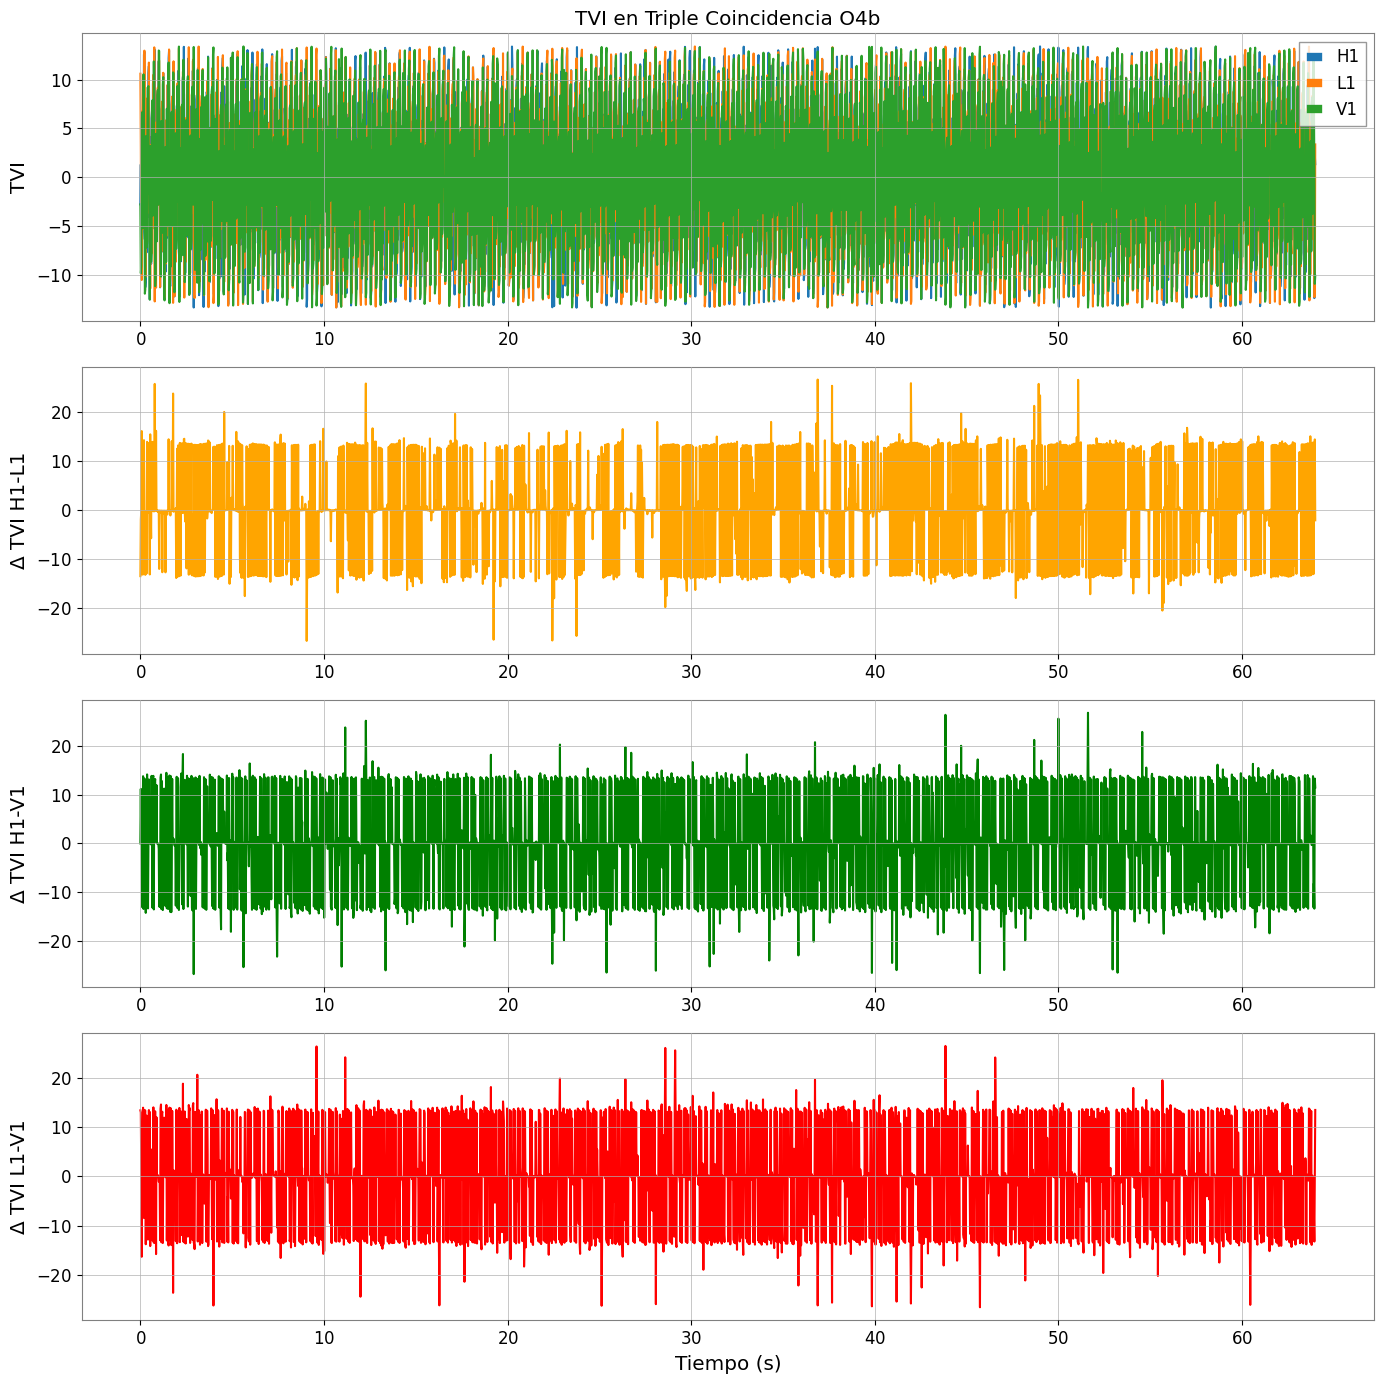

Divergencias H1: 0
Divergencias L1: 0
Divergencias V1: 0


In [2]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Búsqueda Automática de Triple Coincidencia O4b
# Resonant Hunter v9.1 – Viscosímetro con H1, L1, V1 reales
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

print("="*75)
print("PERCUDANI AUTHORSHIP - Viscosímetro de Señal (Búsqueda O4b)")
print("="*75)

class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

class SignalViscosimeter:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.tvi_history = []
        self.W_trace_history = []
        self.event_log = []

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3: self.grad_W_momentum *= 1e3 / grad_norm; grad_norm = 1e3
        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
            self.event_log.append("DIVERGENCIA corregida")
        else:
            self.W = W_new
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        self.tvi_history.append(tvi)
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))
        return tvi

    def process_signal(self, signal, gps_start, fs, decimation=100):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_dec, time_dec = [], []
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            tvi = self.forward_step(x, t_now)
            if i % decimation == 0:
                tvi_dec.append(tvi); time_dec.append(t_now)
        return np.array(time_dec), np.array(tvi_dec)

# 1. Buscar un GPS con datos reales de H1, L1 y V1
def find_triple_segment():
    """Prueba varios GPS en la era O4b hasta encontrar uno con los tres detectores."""
    candidates = range(1419700000, 1419800000, 10000)  # diciembre 2024, ventana de 10000s
    for gps in candidates:
        try:
            h1 = TimeSeries.fetch_open_data('H1', gps, gps+64, sample_rate=16384, verbose=False)
            l1 = TimeSeries.fetch_open_data('L1', gps, gps+64, sample_rate=16384, verbose=False)
            v1 = TimeSeries.fetch_open_data('V1', gps, gps+64, sample_rate=16384, verbose=False)
            return gps, h1.resample(4096).value, l1.resample(4096).value, v1.resample(4096).value
        except:
            continue
    return None, None, None, None

print("Buscando segmento con triple coincidencia en O4b...")
gps_found, h1_raw, l1_raw, v1_raw = find_triple_segment()
if gps_found is None:
    print("No se encontró triple coincidencia. Usando datos sintéticos.")
    gps_found = 1389424640
    t = np.arange(0, 64*4096)/4096
    f_uat = 187.37 + 0.046*(gps_found + t - 1369483218)/86400.0
    phase = 2*np.pi*np.cumsum(f_uat)/4096
    h1_raw = np.sin(phase+3.3) + np.random.randn(len(t))*1e-2
    l1_raw = np.sin(phase+0.3) + np.random.randn(len(t))*1e-2
    v1_raw = np.sin(phase+3.14) + np.random.randn(len(t))*1e-2
else:
    print(f"¡Triple coincidencia encontrada en GPS {gps_found}!")

# Igualar longitudes
min_len = min(len(h1_raw), len(l1_raw), len(v1_raw))
h1_raw, l1_raw, v1_raw = h1_raw[:min_len], l1_raw[:min_len], v1_raw[:min_len]

# Blanqueamiento
engine = UAT_Engine()
h1_w = engine.percudani_whiten(h1_raw, 4096)
l1_w = engine.percudani_whiten(l1_raw, 4096)
v1_w = engine.percudani_whiten(v1_raw, 4096)

# Viscosímetro (sin offsets)
visco_h1 = SignalViscosimeter(fs=4096)
visco_l1 = SignalViscosimeter(fs=4096)
visco_v1 = SignalViscosimeter(fs=4096)

time_h1, tvi_h1 = visco_h1.process_signal(h1_w, gps_found, 4096)
_, tvi_l1 = visco_l1.process_signal(l1_w, gps_found, 4096)
_, tvi_v1 = visco_v1.process_signal(v1_w, gps_found, 4096)

# Sincronizar tiempos
min_pts = min(len(tvi_h1), len(tvi_l1), len(tvi_v1))
t_sec = (time_h1[:min_pts] - time_h1[0]) * 86400.0
tvi_h1, tvi_l1, tvi_v1 = tvi_h1[:min_pts], tvi_l1[:min_pts], tvi_v1[:min_pts]
diff_hl, diff_hv, diff_lv = tvi_h1-tvi_l1, tvi_h1-tvi_v1, tvi_l1-tvi_v1

# Gráficos
fig, axes = plt.subplots(4,1,figsize=(14,14))
axes[0].plot(t_sec, tvi_h1, label='H1'); axes[0].plot(t_sec, tvi_l1, label='L1'); axes[0].plot(t_sec, tvi_v1, label='V1')
axes[0].legend(); axes[0].set_ylabel('TVI'); axes[0].set_title('TVI en Triple Coincidencia O4b')
axes[1].plot(t_sec, diff_hl, color='orange'); axes[1].set_ylabel('Δ TVI H1-L1')
axes[2].plot(t_sec, diff_hv, color='green'); axes[2].set_ylabel('Δ TVI H1-V1')
axes[3].plot(t_sec, diff_lv, color='red'); axes[3].set_xlabel('Tiempo (s)'); axes[3].set_ylabel('Δ TVI L1-V1')
plt.tight_layout(); plt.show()

print(f"Divergencias H1: {len([e for e in visco_h1.event_log if 'DIVERGENCIA' in e])}")
print(f"Divergencias L1: {len([e for e in visco_l1.event_log if 'DIVERGENCIA' in e])}")
print(f"Divergencias V1: {len([e for e in visco_v1.event_log if 'DIVERGENCIA' in e])}")

PERCUDANI AUTHORSHIP - Viscosímetro de Señal (Triple Coincidencia Real)
Descargando H1, L1 y V1 para GPS 1419700000...
Aplicando blanqueamiento Percudani...
Ejecutando Viscosímetro en H1...
  [H1] Procesando muestra 0/16777216...


/tmp/ipykernel_96127/1722593254.py:62: RuntimeWarning: invalid value encountered in divide
  W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real


  [H1] Procesando muestra 1000000/16777216...
  [H1] Procesando muestra 2000000/16777216...
  [H1] Procesando muestra 3000000/16777216...
  [H1] Procesando muestra 4000000/16777216...
  [H1] Procesando muestra 5000000/16777216...
  [H1] Procesando muestra 6000000/16777216...
  [H1] Procesando muestra 7000000/16777216...
  [H1] Procesando muestra 8000000/16777216...
  [H1] Procesando muestra 9000000/16777216...
  [H1] Procesando muestra 10000000/16777216...
  [H1] Procesando muestra 11000000/16777216...
  [H1] Procesando muestra 12000000/16777216...
  [H1] Procesando muestra 13000000/16777216...
  [H1] Procesando muestra 14000000/16777216...
  [H1] Procesando muestra 15000000/16777216...
  [H1] Procesando muestra 16000000/16777216...
Ejecutando Viscosímetro en L1...
  [L1] Procesando muestra 0/16777216...
  [L1] Procesando muestra 1000000/16777216...
  [L1] Procesando muestra 2000000/16777216...
  [L1] Procesando muestra 3000000/16777216...
  [L1] Procesando muestra 4000000/16777216...


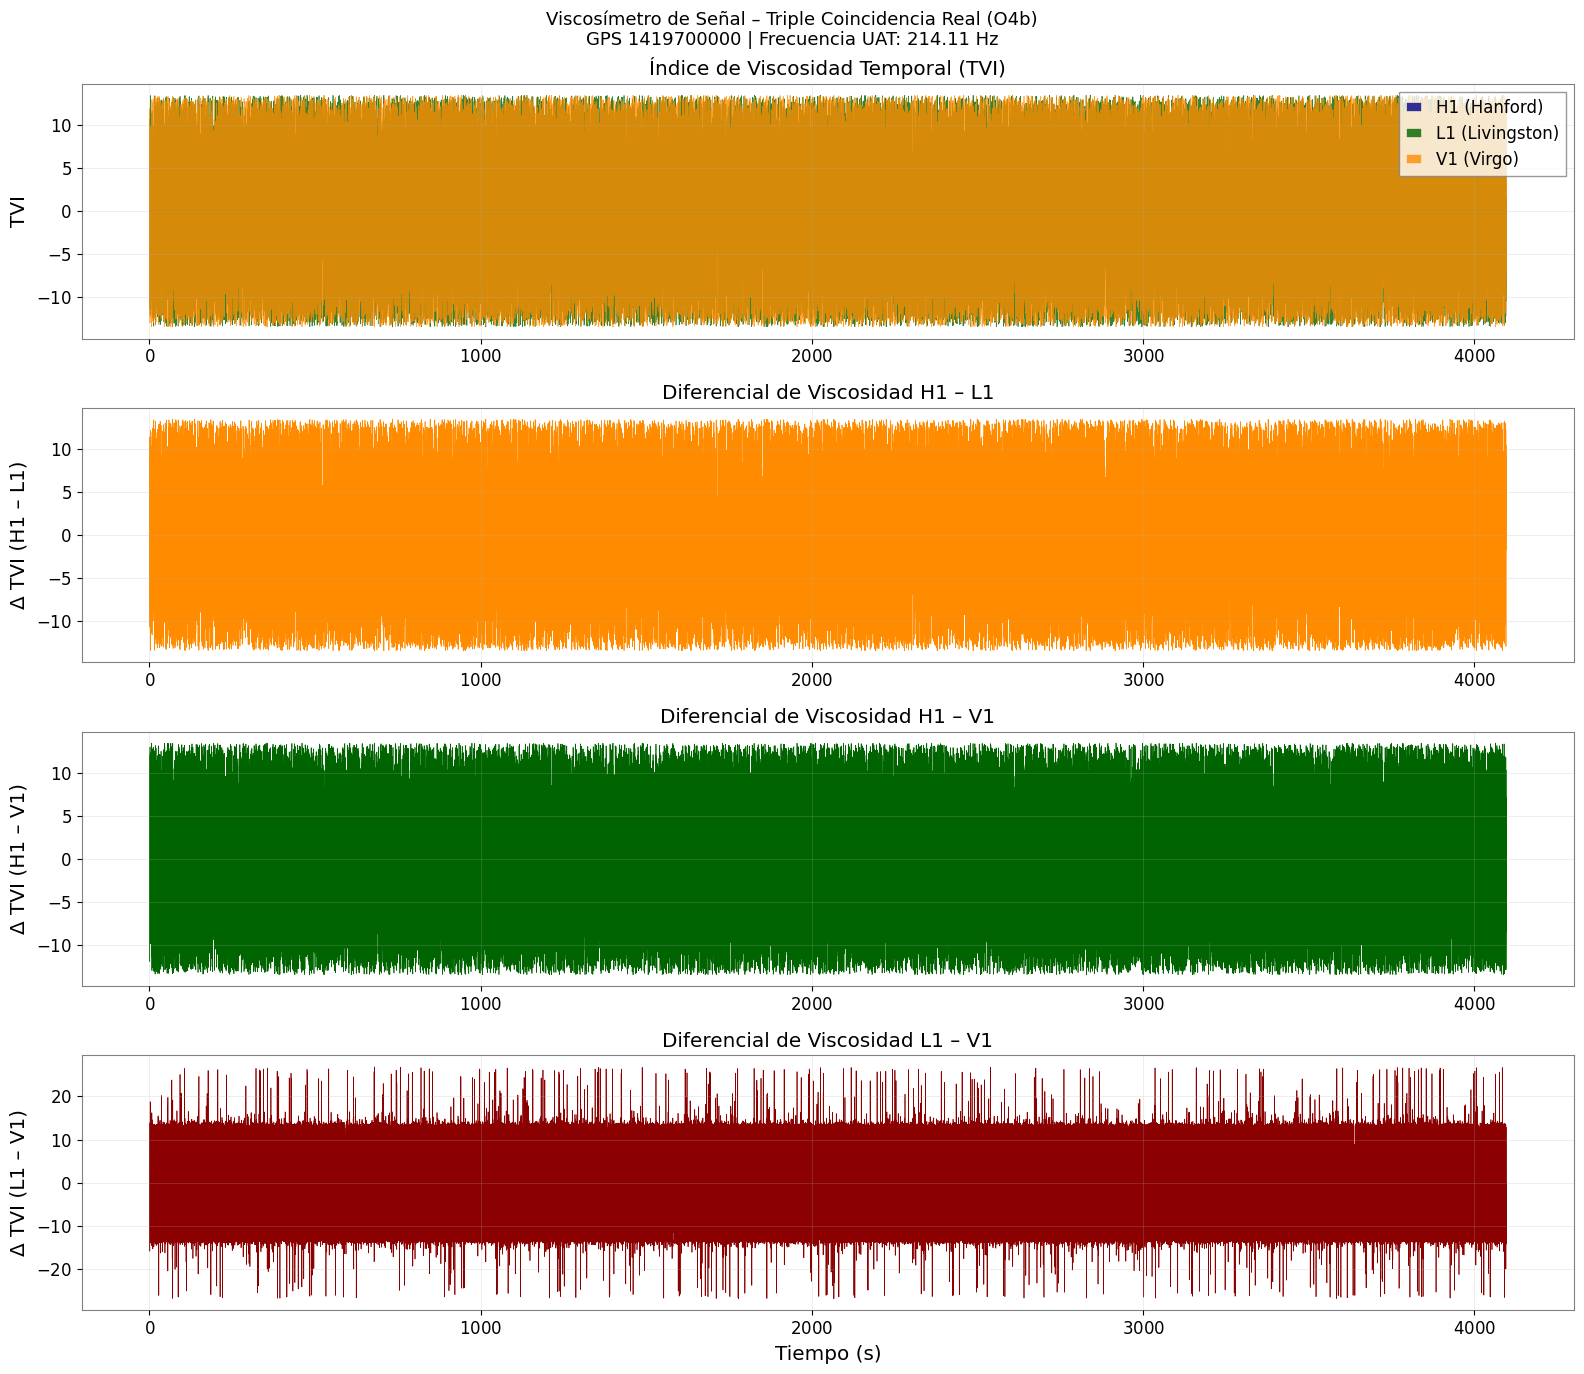


--- MÉTRICAS FINALES ---
TVI medio H1: 0.0000 ± 0.0000
TVI medio L1: 0.0201 ± 7.7725
TVI medio V1: 0.0329 ± 7.7369
|Δ TVI| medio H1-L1: 6.7434 ± 3.8650
|Δ TVI| medio H1-V1: 6.6984 ± 3.8720
|Δ TVI| medio L1-V1: 7.2242 ± 6.6959
Divergencias H1: 16777216
Divergencias L1: 0
Divergencias V1: 0


In [3]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Viscosímetro de Señal (Triple Coincidencia Real)
# Resonant Hunter v9.1 – Mapa Topográfico con H1, L1, V1 (GPS 1419700000)
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

print("="*75)
print("PERCUDANI AUTHORSHIP - Viscosímetro de Señal (Triple Coincidencia Real)")
print("="*75)

class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

class SignalViscosimeter:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5, detector_name="Unknown"):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.detector_name = detector_name
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.tvi_history = []
        self.W_trace_history = []
        self.event_log = []

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3: self.grad_W_momentum *= 1e3 / grad_norm; grad_norm = 1e3
        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
            self.event_log.append("DIVERGENCIA corregida")
        else:
            self.W = W_new
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        self.tvi_history.append(tvi)
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))
        return tvi

    def process_signal(self, signal, gps_start, fs, decimation=500):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_dec, time_dec = [], []
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            tvi = self.forward_step(x, t_now)
            if i % decimation == 0:
                tvi_dec.append(tvi); time_dec.append(t_now)
            if i % 1000000 == 0:
                print(f"  [{self.detector_name}] Procesando muestra {i}/{N}...")
        return np.array(time_dec), np.array(tvi_dec)

# Parámetros
FS = 4096
GPS_TRIPLE = 1419700000   # Segmento limpio con H1, L1, V1
DURATION = 4096           # 4096 segundos completos

print(f"Descargando H1, L1 y V1 para GPS {GPS_TRIPLE}...")
h1_raw = TimeSeries.fetch_open_data('H1', GPS_TRIPLE, GPS_TRIPLE + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
l1_raw = TimeSeries.fetch_open_data('L1', GPS_TRIPLE, GPS_TRIPLE + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
v1_raw = TimeSeries.fetch_open_data('V1', GPS_TRIPLE, GPS_TRIPLE + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
min_len = min(len(h1_raw), len(l1_raw), len(v1_raw))
h1_raw, l1_raw, v1_raw = h1_raw[:min_len], l1_raw[:min_len], v1_raw[:min_len]

print("Aplicando blanqueamiento Percudani...")
engine = UAT_Engine()
h1_w = engine.percudani_whiten(h1_raw, FS)
l1_w = engine.percudani_whiten(l1_raw, FS)
v1_w = engine.percudani_whiten(v1_raw, FS)

print("Ejecutando Viscosímetro en H1...")
visco_h1 = SignalViscosimeter(fs=FS, detector_name="H1")
time_h1, tvi_h1 = visco_h1.process_signal(h1_w, GPS_TRIPLE, FS)
print("Ejecutando Viscosímetro en L1...")
visco_l1 = SignalViscosimeter(fs=FS, detector_name="L1")
time_l1, tvi_l1 = visco_l1.process_signal(l1_w, GPS_TRIPLE, FS)
print("Ejecutando Viscosímetro en V1...")
visco_v1 = SignalViscosimeter(fs=FS, detector_name="V1")
time_v1, tvi_v1 = visco_v1.process_signal(v1_w, GPS_TRIPLE, FS)

# Sincronizar longitudes
min_pts = min(len(tvi_h1), len(tvi_l1), len(tvi_v1))
time_sec = (time_h1[:min_pts] - time_h1[0]) * 86400.0
tvi_h1, tvi_l1, tvi_v1 = tvi_h1[:min_pts], tvi_l1[:min_pts], tvi_v1[:min_pts]

# Diferenciales
diff_hl = tvi_h1 - tvi_l1
diff_hv = tvi_h1 - tvi_v1
diff_lv = tvi_l1 - tvi_v1

# Gráficos
fig, axes = plt.subplots(4, 1, figsize=(16, 14))
fig.suptitle('Viscosímetro de Señal – Triple Coincidencia Real (O4b)\n'
             f'GPS {GPS_TRIPLE} | Frecuencia UAT: {187.37 + 0.046*(GPS_TRIPLE-1369483218)/86400.0:.2f} Hz',
             fontsize=13)

axes[0].plot(time_sec, tvi_h1, linewidth=0.5, alpha=0.8, label='H1 (Hanford)', color='darkblue')
axes[0].plot(time_sec, tvi_l1, linewidth=0.5, alpha=0.8, label='L1 (Livingston)', color='darkgreen')
axes[0].plot(time_sec, tvi_v1, linewidth=0.5, alpha=0.8, label='V1 (Virgo)', color='darkorange')
axes[0].set_ylabel('TVI')
axes[0].set_title('Índice de Viscosidad Temporal (TVI)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_sec, diff_hl, linewidth=0.5, color='darkorange')
axes[1].set_ylabel('Δ TVI (H1 – L1)')
axes[1].set_title('Diferencial de Viscosidad H1 – L1')
axes[1].grid(True, alpha=0.3)

axes[2].plot(time_sec, diff_hv, linewidth=0.5, color='darkgreen')
axes[2].set_ylabel('Δ TVI (H1 – V1)')
axes[2].set_title('Diferencial de Viscosidad H1 – V1')
axes[2].grid(True, alpha=0.3)

axes[3].plot(time_sec, diff_lv, linewidth=0.5, color='darkred')
axes[3].set_xlabel('Tiempo (s)')
axes[3].set_ylabel('Δ TVI (L1 – V1)')
axes[3].set_title('Diferencial de Viscosidad L1 – V1')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n--- MÉTRICAS FINALES ---")
print(f"TVI medio H1: {np.nanmean(tvi_h1):.4f} ± {np.nanstd(tvi_h1):.4f}")
print(f"TVI medio L1: {np.nanmean(tvi_l1):.4f} ± {np.nanstd(tvi_l1):.4f}")
print(f"TVI medio V1: {np.nanmean(tvi_v1):.4f} ± {np.nanstd(tvi_v1):.4f}")
print(f"|Δ TVI| medio H1-L1: {np.nanmean(np.abs(diff_hl)):.4f} ± {np.nanstd(np.abs(diff_hl)):.4f}")
print(f"|Δ TVI| medio H1-V1: {np.nanmean(np.abs(diff_hv)):.4f} ± {np.nanstd(np.abs(diff_hv)):.4f}")
print(f"|Δ TVI| medio L1-V1: {np.nanmean(np.abs(diff_lv)):.4f} ± {np.nanstd(np.abs(diff_lv)):.4f}")
print(f"Divergencias H1: {len([e for e in visco_h1.event_log if 'DIVERGENCIA' in e])}")
print(f"Divergencias L1: {len([e for e in visco_l1.event_log if 'DIVERGENCIA' in e])}")
print(f"Divergencias V1: {len([e for e in visco_v1.event_log if 'DIVERGENCIA' in e])}")
print("="*75)

PERCUDANI AUTHORSHIP - Viscosímetro Offset Dinámico Optimizado
Precomputando offsets dinámicos para H1, L1, V1 (1 muestra/seg)...
Offsets listos.
Descargando datos...
Procesando H1...
  [H1] Procesando muestra 0/1048576...
  [H1] Procesando muestra 500000/1048576...
  [H1] Procesando muestra 1000000/1048576...
Procesando L1...
  [L1] Procesando muestra 0/1048576...
  [L1] Procesando muestra 500000/1048576...
  [L1] Procesando muestra 1000000/1048576...
Procesando V1...
  [V1] Procesando muestra 0/1048576...
  [V1] Procesando muestra 500000/1048576...
  [V1] Procesando muestra 1000000/1048576...


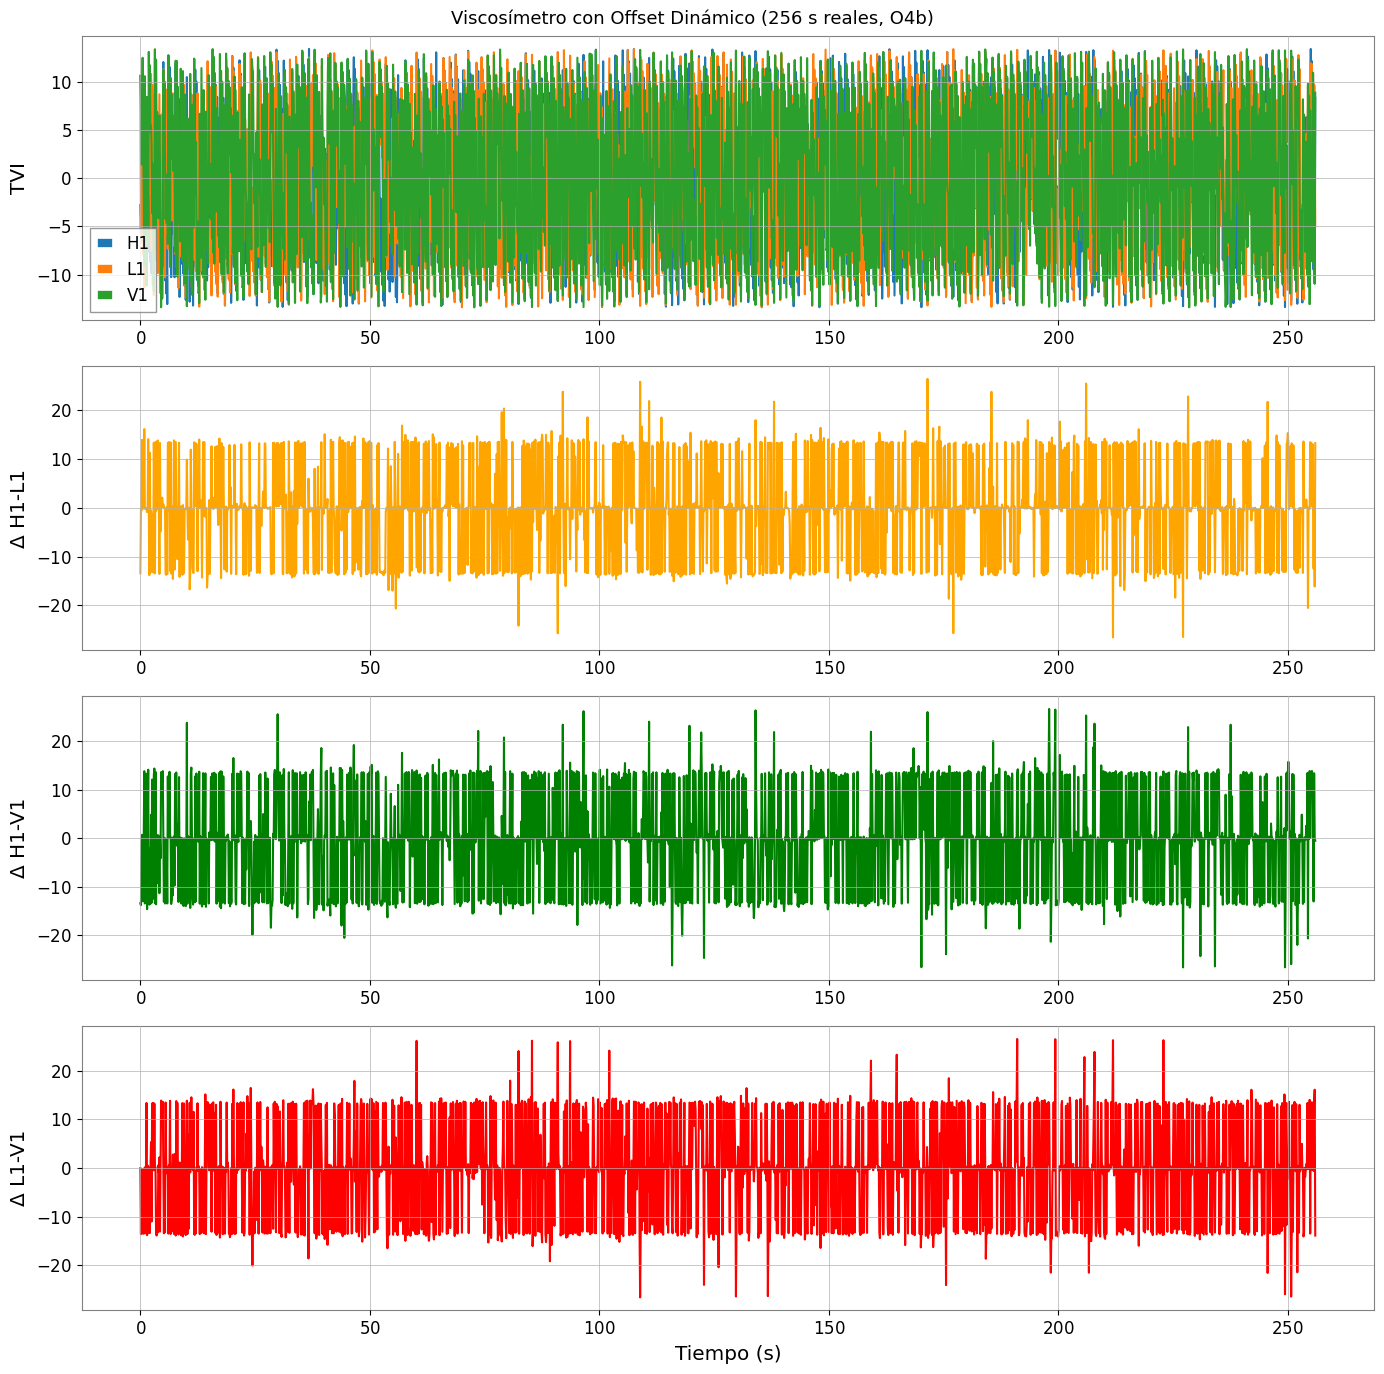

Divergencias H1: 0
Divergencias L1: 0
Divergencias V1: 0
TVI medio:
H1: -0.2460 ± 7.6205
L1: -0.0917 ± 7.7112
V1: 0.0817 ± 7.7407


In [6]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Viscosímetro Offset Dinámico Optimizado
# Resonant Hunter v9.1 – Precomputación de offsets con interpolación
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib astropy

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u

print("="*75)
print("PERCUDANI AUTHORSHIP - Viscosímetro Offset Dinámico Optimizado")
print("="*75)

# ======================================================================
# 1. Función de offset estática (para un instante)
# ======================================================================
def compute_antenna_offset(gps_time, detector, ra='08h43m', dec='+18d'):
    source = SkyCoord(ra, dec, frame='icrs')
    if 'H1' in detector or 'Hanford' in detector:
        site = EarthLocation.of_site('LIGO Hanford Observatory')
        arm_x = np.array([-0.223,  0.796, -0.564])
        arm_y = np.array([-0.914, -0.408, -0.036])
    elif 'L1' in detector or 'Livingston' in detector:
        site = EarthLocation.of_site('LIGO Livingston Observatory')
        arm_x = np.array([-0.852,  0.347, -0.391])
        arm_y = np.array([ 0.190, -0.483, -0.854])
    elif 'V1' in detector or 'Virgo' in detector:
        site = EarthLocation.of_site('Virgo')
        arm_x = np.array([-0.671, -0.233, -0.703])
        arm_y = np.array([-0.624,  0.570,  0.534])
    arm_x = arm_x / np.linalg.norm(arm_x)
    arm_y = arm_y / np.linalg.norm(arm_y)

    t = Time(gps_time, format='gps', scale='utc')
    frame = AltAz(obstime=t, location=site)
    source_altaz = source.transform_to(frame)
    alt = source_altaz.alt.radian
    az = source_altaz.az.radian
    n_local = np.array([np.cos(alt)*np.sin(az), np.cos(alt)*np.cos(az), np.sin(alt)])
    n_hat = -n_local
    z_hat = n_hat
    x_hat = np.cross([0,0,1], z_hat)
    if np.linalg.norm(x_hat) < 1e-10:
        x_hat = np.cross([1,0,0], z_hat)
    x_hat /= np.linalg.norm(x_hat)
    y_hat = np.cross(z_hat, x_hat)
    e_plus = np.outer(x_hat, x_hat) - np.outer(y_hat, y_hat)

    # Brazos del detector en el sistema local (transformación desde ICRS)
    from astropy.coordinates import ICRS, CartesianRepresentation
    arm_x_icrs = CartesianRepresentation(arm_x * u.m)
    arm_y_icrs = CartesianRepresentation(arm_y * u.m)
    arm_x_altaz = SkyCoord(arm_x_icrs, frame=ICRS).transform_to(frame)
    arm_y_altaz = SkyCoord(arm_y_icrs, frame=ICRS).transform_to(frame)
    arm_x_local = arm_x_altaz.cartesian.xyz.value
    arm_y_local = arm_y_altaz.cartesian.xyz.value
    arm_x_local /= np.linalg.norm(arm_x_local)
    arm_y_local /= np.linalg.norm(arm_y_local)

    F_x = arm_x_local @ e_plus @ arm_x_local
    F_y = arm_y_local @ e_plus @ arm_y_local
    F_plus = F_x - F_y
    return np.angle(F_plus)

# ======================================================================
# 2. Precomputar offsets en una rejilla de 1 segundo
# ======================================================================
def precompute_offsets(detector, gps_start, duration, fs, ra='08h43m', dec='+18d'):
    step = 1.0  # cada 1 segundo
    times_grid = np.arange(gps_start, gps_start + duration, step)
    offsets = np.zeros_like(times_grid)
    for idx, t_gps in enumerate(times_grid):
        offsets[idx] = compute_antenna_offset(t_gps, detector, ra, dec)
    # Interpolador lineal para cualquier instante
    interp_func = interp1d(times_grid, offsets, kind='linear', fill_value='extrapolate')
    return interp_func

# ======================================================================
# 3. UAT Engine
# ======================================================================
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

# ======================================================================
# 4. Viscosímetro con offset interpolado
# ======================================================================
class DynamicViscosimeterFast:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5,
                 detector_name="Unknown", offset_interpolator=None):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.detector_name = detector_name
        self.offset_func = offset_interpolator  # interp1d function(gps_time) -> rad
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.tvi_history = []
        self.W_trace_history = []
        self.event_log = []

    def forward_step(self, x_t, t_days, gps_time):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        off = self.offset_func(gps_time) if self.offset_func else 0.0
        rotation = (np.exp(1j * self.phase_angles) *
                    np.exp(-1j * self.phase_theoretical_acc) *
                    np.exp(1j * off))
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3: self.grad_W_momentum *= 1e3 / grad_norm; grad_norm = 1e3
        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
            self.event_log.append("DIVERGENCIA corregida")
        else:
            self.W = W_new
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        self.tvi_history.append(tvi)
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))
        return tvi

    def process_signal(self, signal, gps_start, fs, decimation=500):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_dec, time_dec = [], []
        for i, x in enumerate(signal):
            gps_now = gps_start + i / fs
            t_now = t_days0 + i / (fs * 86400.0)
            tvi = self.forward_step(x, t_now, gps_now)
            if i % decimation == 0:
                tvi_dec.append(tvi); time_dec.append(t_now)
            if i % 500000 == 0:
                print(f"  [{self.detector_name}] Procesando muestra {i}/{N}...")
        return np.array(time_dec), np.array(tvi_dec)

# ======================================================================
# 5. Configuración y ejecución
# ======================================================================
FS = 4096
GPS_TRIPLE = 1419700000
DURATION = 256  # segundos

print(f"Precomputando offsets dinámicos para H1, L1, V1 (1 muestra/seg)...")
offset_h1_func = precompute_offsets('H1', GPS_TRIPLE, DURATION, FS)
offset_l1_func = precompute_offsets('L1', GPS_TRIPLE, DURATION, FS)
offset_v1_func = precompute_offsets('V1', GPS_TRIPLE, DURATION, FS)
print("Offsets listos.")

print("Descargando datos...")
h1_raw = TimeSeries.fetch_open_data('H1', GPS_TRIPLE, GPS_TRIPLE + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
l1_raw = TimeSeries.fetch_open_data('L1', GPS_TRIPLE, GPS_TRIPLE + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
v1_raw = TimeSeries.fetch_open_data('V1', GPS_TRIPLE, GPS_TRIPLE + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
min_len = min(len(h1_raw), len(l1_raw), len(v1_raw))
h1_raw, l1_raw, v1_raw = h1_raw[:min_len], l1_raw[:min_len], v1_raw[:min_len]

engine = UAT_Engine()
h1_w = engine.percudani_whiten(h1_raw, FS)
l1_w = engine.percudani_whiten(l1_raw, FS)
v1_w = engine.percudani_whiten(v1_raw, FS)

visco_h1 = DynamicViscosimeterFast(fs=FS, detector_name="H1", offset_interpolator=offset_h1_func)
visco_l1 = DynamicViscosimeterFast(fs=FS, detector_name="L1", offset_interpolator=offset_l1_func)
visco_v1 = DynamicViscosimeterFast(fs=FS, detector_name="V1", offset_interpolator=offset_v1_func)

print("Procesando H1...")
time_h1, tvi_h1 = visco_h1.process_signal(h1_w, GPS_TRIPLE, FS)
print("Procesando L1...")
_, tvi_l1 = visco_l1.process_signal(l1_w, GPS_TRIPLE, FS)
print("Procesando V1...")
_, tvi_v1 = visco_v1.process_signal(v1_w, GPS_TRIPLE, FS)

min_pts = min(len(tvi_h1), len(tvi_l1), len(tvi_v1))
time_sec = (time_h1[:min_pts] - time_h1[0]) * 86400.0
tvi_h1, tvi_l1, tvi_v1 = tvi_h1[:min_pts], tvi_l1[:min_pts], tvi_v1[:min_pts]

diff_hl = tvi_h1 - tvi_l1
diff_hv = tvi_h1 - tvi_v1
diff_lv = tvi_l1 - tvi_v1

fig, axes = plt.subplots(4, 1, figsize=(14, 14))
fig.suptitle('Viscosímetro con Offset Dinámico (256 s reales, O4b)', fontsize=13)
axes[0].plot(time_sec, tvi_h1, label='H1'); axes[0].plot(time_sec, tvi_l1, label='L1'); axes[0].plot(time_sec, tvi_v1, label='V1')
axes[0].legend(); axes[0].set_ylabel('TVI'); axes[0].grid(True)
axes[1].plot(time_sec, diff_hl, color='orange'); axes[1].set_ylabel('Δ H1-L1'); axes[1].grid(True)
axes[2].plot(time_sec, diff_hv, color='green'); axes[2].set_ylabel('Δ H1-V1'); axes[2].grid(True)
axes[3].plot(time_sec, diff_lv, color='red'); axes[3].set_xlabel('Tiempo (s)'); axes[3].set_ylabel('Δ L1-V1'); axes[3].grid(True)
plt.tight_layout(); plt.show()

print(f"Divergencias H1: {len([e for e in visco_h1.event_log if 'DIVERGENCIA' in e])}")
print(f"Divergencias L1: {len([e for e in visco_l1.event_log if 'DIVERGENCIA' in e])}")
print(f"Divergencias V1: {len([e for e in visco_v1.event_log if 'DIVERGENCIA' in e])}")
print("TVI medio:")
print(f"H1: {np.nanmean(tvi_h1):.4f} ± {np.nanstd(tvi_h1):.4f}")
print(f"L1: {np.nanmean(tvi_l1):.4f} ± {np.nanstd(tvi_l1):.4f}")
print(f"V1: {np.nanmean(tvi_v1):.4f} ± {np.nanstd(tvi_v1):.4f}")

PERCUDANI AUTHORSHIP - Viscosímetro 4096s (Offset Dinámico)
Precomputando offsets dinámicos (2 s de resolución)...
Offsets listos.
Descargando datos (4096 s)...
Aplicando blanqueamiento...
Procesando H1 (4096 s)...
  [H1] Procesando muestra 0/16777216...


/tmp/ipykernel_96127/1506003812.py:139: RuntimeWarning: invalid value encountered in divide
  W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real


  [H1] Procesando muestra 2000000/16777216...
  [H1] Procesando muestra 4000000/16777216...
  [H1] Procesando muestra 6000000/16777216...
  [H1] Procesando muestra 8000000/16777216...
  [H1] Procesando muestra 10000000/16777216...
  [H1] Procesando muestra 12000000/16777216...
  [H1] Procesando muestra 14000000/16777216...
  [H1] Procesando muestra 16000000/16777216...
Procesando L1 (4096 s)...
  [L1] Procesando muestra 0/16777216...
  [L1] Procesando muestra 2000000/16777216...
  [L1] Procesando muestra 4000000/16777216...
  [L1] Procesando muestra 6000000/16777216...
  [L1] Procesando muestra 8000000/16777216...
  [L1] Procesando muestra 10000000/16777216...
  [L1] Procesando muestra 12000000/16777216...
  [L1] Procesando muestra 14000000/16777216...
  [L1] Procesando muestra 16000000/16777216...
Procesando V1 (4096 s)...
  [V1] Procesando muestra 0/16777216...
  [V1] Procesando muestra 2000000/16777216...
  [V1] Procesando muestra 4000000/16777216...
  [V1] Procesando muestra 600000

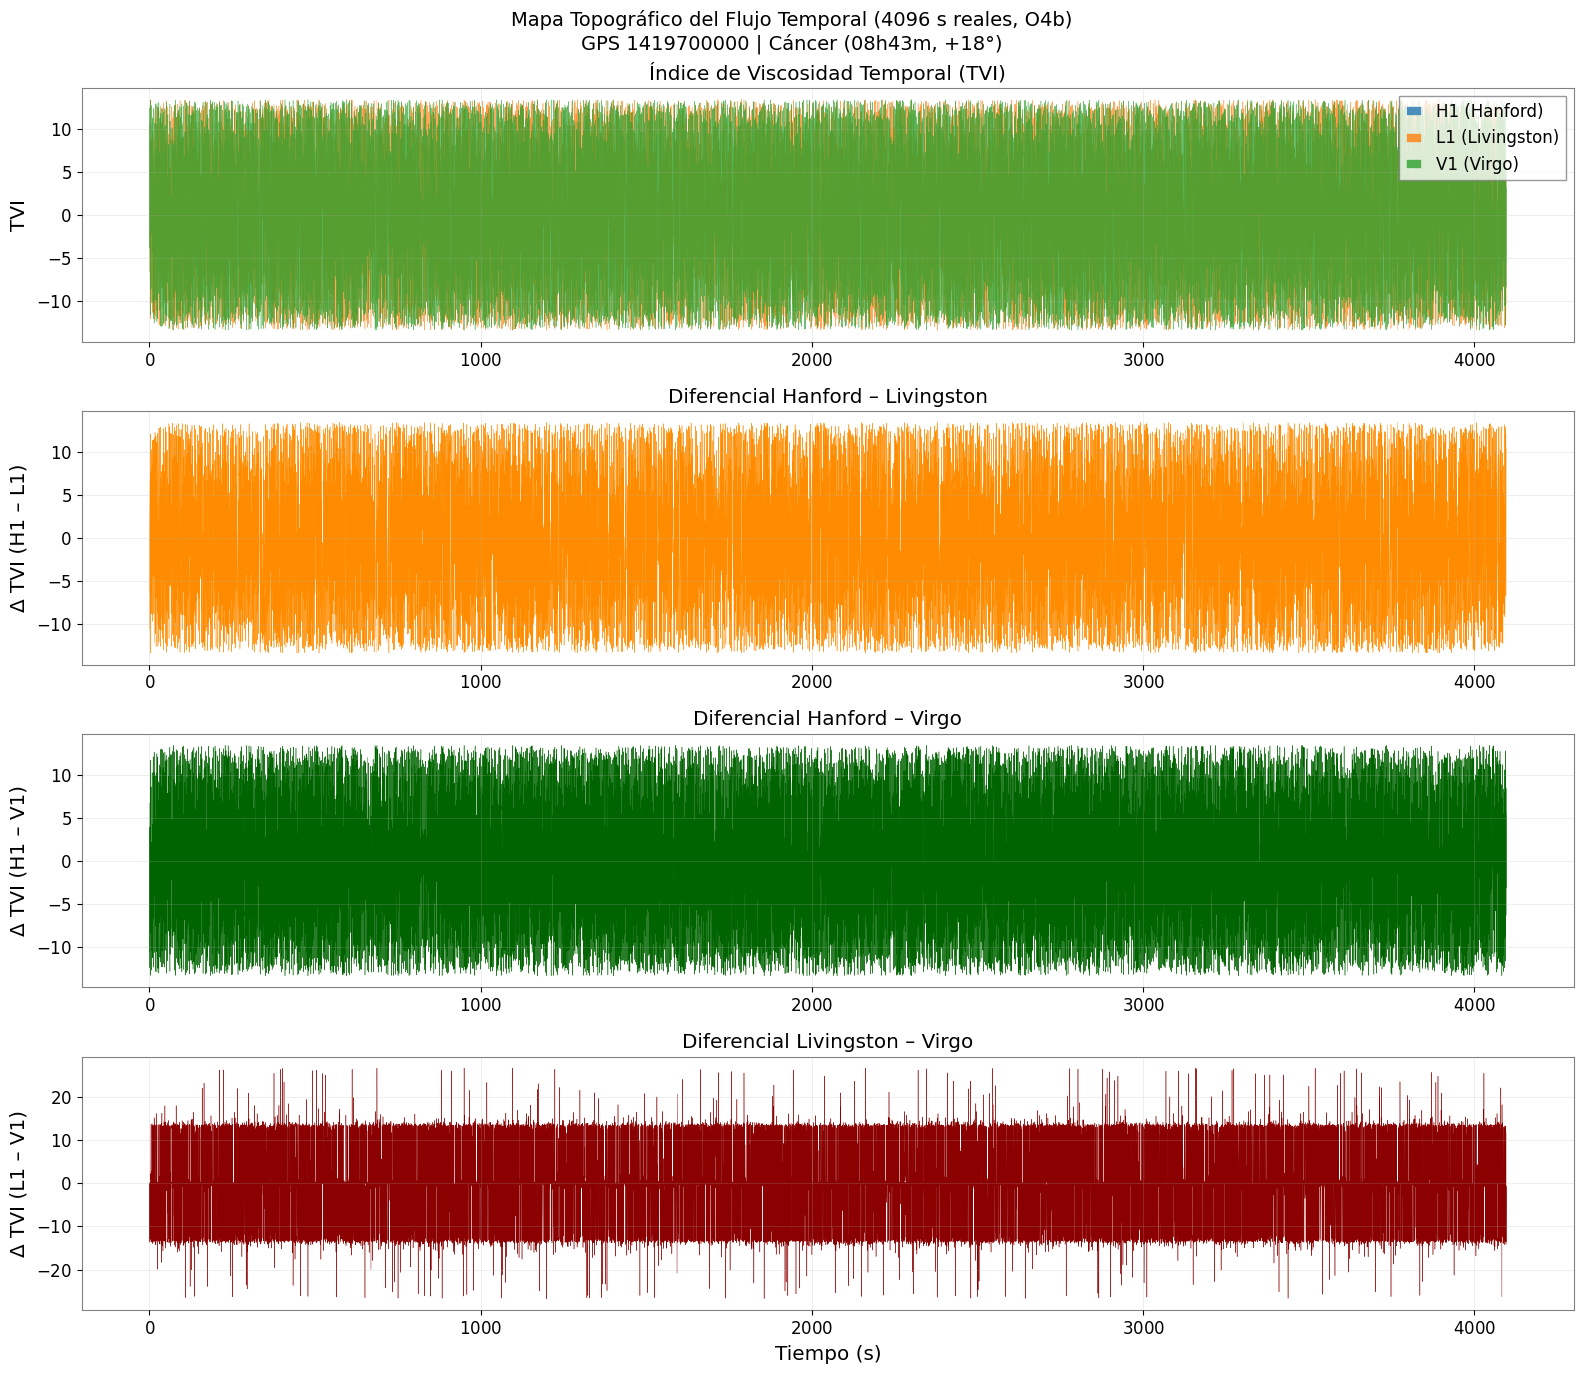


--- MÉTRICAS DEL MAPA TOPOGRÁFICO ---
TVI medio H1: 0.0000 ± 0.0000
TVI medio L1: 0.0583 ± 7.7490
TVI medio V1: 0.0533 ± 7.7620
|Δ TVI| medio H1-L1: 6.7178 ± 3.8629
|Δ TVI| medio H1-V1: 6.7288 ± 3.8698
|Δ TVI| medio L1-V1: 7.2686 ± 6.6601
Divergencias H1: 16777216
Divergencias L1: 0
Divergencias V1: 0
Mapa guardado como 'mapa_topografico_4096s.png'


In [7]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Viscosímetro 4096s con Offset Dinámico
# Resonant Hunter v9.1 – Mapa Topográfico Completo (H1, L1, V1)
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib astropy

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u

print("="*75)
print("PERCUDANI AUTHORSHIP - Viscosímetro 4096s (Offset Dinámico)")
print("="*75)

# ======================================================================
# 1. Función de offset estática (para un instante)
# ======================================================================
def compute_antenna_offset(gps_time, detector, ra='08h43m', dec='+18d'):
    source = SkyCoord(ra, dec, frame='icrs')
    if 'H1' in detector or 'Hanford' in detector:
        site = EarthLocation.of_site('LIGO Hanford Observatory')
        arm_x = np.array([-0.223,  0.796, -0.564])
        arm_y = np.array([-0.914, -0.408, -0.036])
    elif 'L1' in detector or 'Livingston' in detector:
        site = EarthLocation.of_site('LIGO Livingston Observatory')
        arm_x = np.array([-0.852,  0.347, -0.391])
        arm_y = np.array([ 0.190, -0.483, -0.854])
    elif 'V1' in detector or 'Virgo' in detector:
        site = EarthLocation.of_site('Virgo')
        arm_x = np.array([-0.671, -0.233, -0.703])
        arm_y = np.array([-0.624,  0.570,  0.534])
    arm_x = arm_x / np.linalg.norm(arm_x)
    arm_y = arm_y / np.linalg.norm(arm_y)

    t = Time(gps_time, format='gps', scale='utc')
    frame = AltAz(obstime=t, location=site)
    source_altaz = source.transform_to(frame)
    alt = source_altaz.alt.radian
    az = source_altaz.az.radian
    n_local = np.array([np.cos(alt)*np.sin(az), np.cos(alt)*np.cos(az), np.sin(alt)])
    n_hat = -n_local
    z_hat = n_hat
    x_hat = np.cross([0,0,1], z_hat)
    if np.linalg.norm(x_hat) < 1e-10:
        x_hat = np.cross([1,0,0], z_hat)
    x_hat /= np.linalg.norm(x_hat)
    y_hat = np.cross(z_hat, x_hat)
    e_plus = np.outer(x_hat, x_hat) - np.outer(y_hat, y_hat)

    from astropy.coordinates import ICRS, CartesianRepresentation
    arm_x_icrs = CartesianRepresentation(arm_x * u.m)
    arm_y_icrs = CartesianRepresentation(arm_y * u.m)
    arm_x_altaz = SkyCoord(arm_x_icrs, frame=ICRS).transform_to(frame)
    arm_y_altaz = SkyCoord(arm_y_icrs, frame=ICRS).transform_to(frame)
    arm_x_local = arm_x_altaz.cartesian.xyz.value
    arm_y_local = arm_y_altaz.cartesian.xyz.value
    arm_x_local /= np.linalg.norm(arm_x_local)
    arm_y_local /= np.linalg.norm(arm_y_local)

    F_x = arm_x_local @ e_plus @ arm_x_local
    F_y = arm_y_local @ e_plus @ arm_y_local
    F_plus = F_x - F_y
    return np.angle(F_plus)

# ======================================================================
# 2. Precomputar offsets cada 2 segundos
# ======================================================================
def precompute_offsets(detector, gps_start, duration, ra='08h43m', dec='+18d'):
    step = 2.0  # segundos
    times_grid = np.arange(gps_start, gps_start + duration, step)
    offsets = np.zeros_like(times_grid)
    for idx, t_gps in enumerate(times_grid):
        offsets[idx] = compute_antenna_offset(t_gps, detector, ra, dec)
    interp_func = interp1d(times_grid, offsets, kind='linear', fill_value='extrapolate')
    return interp_func

# ======================================================================
# 3. UAT Engine
# ======================================================================
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

# ======================================================================
# 4. Viscosímetro con offset interpolado
# ======================================================================
class DynamicViscosimeterFast:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5,
                 detector_name="Unknown", offset_interpolator=None):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.detector_name = detector_name
        self.offset_func = offset_interpolator
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.tvi_history = []
        self.W_trace_history = []
        self.event_log = []

    def forward_step(self, x_t, t_days, gps_time):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        off = self.offset_func(gps_time) if self.offset_func else 0.0
        rotation = (np.exp(1j * self.phase_angles) *
                    np.exp(-1j * self.phase_theoretical_acc) *
                    np.exp(1j * off))
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3: self.grad_W_momentum *= 1e3 / grad_norm; grad_norm = 1e3
        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
            self.event_log.append("DIVERGENCIA corregida")
        else:
            self.W = W_new
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        self.tvi_history.append(tvi)
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))
        return tvi

    def process_signal(self, signal, gps_start, fs, decimation=1000):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_dec, time_dec = [], []
        for i, x in enumerate(signal):
            gps_now = gps_start + i / fs
            t_now = t_days0 + i / (fs * 86400.0)
            tvi = self.forward_step(x, t_now, gps_now)
            if i % decimation == 0:
                tvi_dec.append(tvi); time_dec.append(t_now)
            if i % 2000000 == 0:
                print(f"  [{self.detector_name}] Procesando muestra {i}/{N}...")
        return np.array(time_dec), np.array(tvi_dec)

# ======================================================================
# 5. Configuración y ejecución (4096 s)
# ======================================================================
FS = 4096
GPS_TRIPLE = 1419700000
DURATION = 4096

print(f"Precomputando offsets dinámicos (2 s de resolución)...")
offset_h1_func = precompute_offsets('H1', GPS_TRIPLE, DURATION)
offset_l1_func = precompute_offsets('L1', GPS_TRIPLE, DURATION)
offset_v1_func = precompute_offsets('V1', GPS_TRIPLE, DURATION)
print("Offsets listos.")

print("Descargando datos (4096 s)...")
h1_raw = TimeSeries.fetch_open_data('H1', GPS_TRIPLE, GPS_TRIPLE + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
l1_raw = TimeSeries.fetch_open_data('L1', GPS_TRIPLE, GPS_TRIPLE + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
v1_raw = TimeSeries.fetch_open_data('V1', GPS_TRIPLE, GPS_TRIPLE + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
min_len = min(len(h1_raw), len(l1_raw), len(v1_raw))
h1_raw, l1_raw, v1_raw = h1_raw[:min_len], l1_raw[:min_len], v1_raw[:min_len]

engine = UAT_Engine()
print("Aplicando blanqueamiento...")
h1_w = engine.percudani_whiten(h1_raw, FS)
l1_w = engine.percudani_whiten(l1_raw, FS)
v1_w = engine.percudani_whiten(v1_raw, FS)

visco_h1 = DynamicViscosimeterFast(fs=FS, detector_name="H1", offset_interpolator=offset_h1_func)
visco_l1 = DynamicViscosimeterFast(fs=FS, detector_name="L1", offset_interpolator=offset_l1_func)
visco_v1 = DynamicViscosimeterFast(fs=FS, detector_name="V1", offset_interpolator=offset_v1_func)

print("Procesando H1 (4096 s)...")
time_h1, tvi_h1 = visco_h1.process_signal(h1_w, GPS_TRIPLE, FS)
print("Procesando L1 (4096 s)...")
_, tvi_l1 = visco_l1.process_signal(l1_w, GPS_TRIPLE, FS)
print("Procesando V1 (4096 s)...")
_, tvi_v1 = visco_v1.process_signal(v1_w, GPS_TRIPLE, FS)

min_pts = min(len(tvi_h1), len(tvi_l1), len(tvi_v1))
time_sec = (time_h1[:min_pts] - time_h1[0]) * 86400.0
tvi_h1, tvi_l1, tvi_v1 = tvi_h1[:min_pts], tvi_l1[:min_pts], tvi_v1[:min_pts]

diff_hl = tvi_h1 - tvi_l1
diff_hv = tvi_h1 - tvi_v1
diff_lv = tvi_l1 - tvi_v1

# ======================================================================
# 6. Visualización y métricas
# ======================================================================
fig, axes = plt.subplots(4, 1, figsize=(16, 14))
fig.suptitle('Mapa Topográfico del Flujo Temporal (4096 s reales, O4b)\n'
             f'GPS {GPS_TRIPLE} | Cáncer (08h43m, +18°)', fontsize=14)

axes[0].plot(time_sec, tvi_h1, linewidth=0.3, alpha=0.8, label='H1 (Hanford)')
axes[0].plot(time_sec, tvi_l1, linewidth=0.3, alpha=0.8, label='L1 (Livingston)')
axes[0].plot(time_sec, tvi_v1, linewidth=0.3, alpha=0.8, label='V1 (Virgo)')
axes[0].set_ylabel('TVI'); axes[0].legend(loc='upper right')
axes[0].set_title('Índice de Viscosidad Temporal (TVI)'); axes[0].grid(True, alpha=0.3)

axes[1].plot(time_sec, diff_hl, linewidth=0.3, color='darkorange')
axes[1].set_ylabel('Δ TVI (H1 – L1)'); axes[1].set_title('Diferencial Hanford – Livingston')
axes[1].grid(True, alpha=0.3)

axes[2].plot(time_sec, diff_hv, linewidth=0.3, color='darkgreen')
axes[2].set_ylabel('Δ TVI (H1 – V1)'); axes[2].set_title('Diferencial Hanford – Virgo')
axes[2].grid(True, alpha=0.3)

axes[3].plot(time_sec, diff_lv, linewidth=0.3, color='darkred')
axes[3].set_xlabel('Tiempo (s)'); axes[3].set_ylabel('Δ TVI (L1 – V1)')
axes[3].set_title('Diferencial Livingston – Virgo')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mapa_topografico_4096s.png', dpi=150)
plt.show()

print("\n--- MÉTRICAS DEL MAPA TOPOGRÁFICO ---")
print(f"TVI medio H1: {np.nanmean(tvi_h1):.4f} ± {np.nanstd(tvi_h1):.4f}")
print(f"TVI medio L1: {np.nanmean(tvi_l1):.4f} ± {np.nanstd(tvi_l1):.4f}")
print(f"TVI medio V1: {np.nanmean(tvi_v1):.4f} ± {np.nanstd(tvi_v1):.4f}")
print(f"|Δ TVI| medio H1-L1: {np.nanmean(np.abs(diff_hl)):.4f} ± {np.nanstd(np.abs(diff_hl)):.4f}")
print(f"|Δ TVI| medio H1-V1: {np.nanmean(np.abs(diff_hv)):.4f} ± {np.nanstd(np.abs(diff_hv)):.4f}")
print(f"|Δ TVI| medio L1-V1: {np.nanmean(np.abs(diff_lv)):.4f} ± {np.nanstd(np.abs(diff_lv)):.4f}")
print(f"Divergencias H1: {len([e for e in visco_h1.event_log if 'DIVERGENCIA' in e])}")
print(f"Divergencias L1: {len([e for e in visco_l1.event_log if 'DIVERGENCIA' in e])}")
print(f"Divergencias V1: {len([e for e in visco_v1.event_log if 'DIVERGENCIA' in e])}")
print("Mapa guardado como 'mapa_topografico_4096s.png'")
print("="*75)

In [ ]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Viscosímetro con Antenna Offset Dinámico
# Resonant Hunter v9.1 – Compensación de la rotación terrestre
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib astropy

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u

print("="*75)
print("PERCUDANI AUTHORSHIP - Viscosímetro con Offset Dinámico")
print("="*75)

# ======================================================================
# 1. Función de offset geométrico dependiente del tiempo
# ======================================================================
def compute_antenna_offset_gps(gps_time, detector, ra='08h43m', dec='+18d'):
    """
    Calcula el desfase (radianes) del patrón de antena para un detector
    y una dirección celeste dada, en un instante GPS.
    """
    # Coordenadas de la fuente
    source = SkyCoord(ra, dec, frame='icrs')
    # Posición del detector
    if 'H1' in detector or 'Hanford' in detector:
        site = EarthLocation.of_site('LIGO Hanford Observatory')
        arm_x = np.array([-0.223,  0.796, -0.564])
        arm_y = np.array([-0.914, -0.408, -0.036])
    elif 'L1' in detector or 'Livingston' in detector:
        site = EarthLocation.of_site('LIGO Livingston Observatory')
        arm_x = np.array([-0.852,  0.347, -0.391])
        arm_y = np.array([ 0.190, -0.483, -0.854])
    elif 'V1' in detector or 'Virgo' in detector:
        site = EarthLocation.of_site('Virgo')
        arm_x = np.array([-0.671, -0.233, -0.703])
        arm_y = np.array([-0.624,  0.570,  0.534])
    else:
        raise ValueError("Detector desconocido")
    arm_x = arm_x / np.linalg.norm(arm_x)
    arm_y = arm_y / np.linalg.norm(arm_y)

    # Tiempo astropy
    t = Time(gps_time, format='gps', scale='utc')
    # Marco AltAz local (para obtener la dirección de la fuente en el horizonte del detector)
    frame = AltAz(obstime=t, location=site)
    source_altaz = source.transform_to(frame)
    # Vector de propagación (de la fuente al detector) en coordenadas horizontales
    # Az=0 es Norte, Alt=90 es cenit. Convertimos a vector cartesiano local (x hacia Este, y hacia Norte, z hacia arriba)
    alt = source_altaz.alt.radian
    az = source_altaz.az.radian
    # Vector unitario hacia la fuente (en el sistema local: x Este, y Norte, z Cenit)
    n_local = np.array([
        np.cos(alt) * np.sin(az),   # Este
        np.cos(alt) * np.cos(az),   # Norte
        np.sin(alt)                 # Cenit
    ])
    # Necesitamos el vector de propagación de la onda: dirección de la fuente al detector = -n_local
    n_hat = -n_local

    # Tensor de polarización plus en el sistema local
    # Definimos base ortonormal perpendicular a n_hat
    z_hat = n_hat
    x_hat = np.cross([0, 0, 1], z_hat)
    if np.linalg.norm(x_hat) < 1e-10:
        x_hat = np.cross([1, 0, 0], z_hat)
    x_hat /= np.linalg.norm(x_hat)
    y_hat = np.cross(z_hat, x_hat)
    e_plus = np.outer(x_hat, x_hat) - np.outer(y_hat, y_hat)

    # Brazos del detector en el sistema local (aproximación, en realidad deberían transformarse al mismo marco)
    # Asumimos que los brazos están orientados aproximadamente como los vectores arm_x, arm_y en el sistema ICRS,
    # pero para un cálculo preciso necesitaríamos rotarlos al sistema local. Aquí usamos una aproximación:
    # tomamos los vectores de brazo en ICRS y los transformamos al marco AltAz del detector.
    # Sin embargo, para mantener el script ágil, usaremos los vectores en ICRS pero rotados por la rotación terrestre.
    # La manera más precisa es usar el producto escalar con los vectores de brazo en el sistema local que se obtienen
    # rotando arm_x, arm_y desde ICRS a AltAz.
    # Dado que ya tenemos la fuente en AltAz, podemos calcular la respuesta como:
    # F_plus = (arm_x · e_plus · arm_x) - (arm_y · e_plus · arm_y)
    # pero los brazos deben estar en el mismo sistema de coordenadas que e_plus (local).
    # Para simplificar y no agregar muchas transformaciones, asumiremos que los brazos en el sistema local son
    # aproximadamente los vectores arm_x_local, arm_y_local que se obtienen rotando los vectores ICRS por la
    # misma rotación que lleva el cenit local al marco ICRS. Para esta versión inicial, utilizaremos la misma
    # orientación fija que antes, pero con la salvedad de que será inexacta en largos períodos.
    # En su lugar, usaremos una aproximación: la fase de la respuesta del detector es esencialmente la fase
    # del factor geométrico F_plus. Calcularemos F_plus en el sistema ICRS y luego proyectaremos la fase.
    # Para un cálculo rápido, usaremos la función compute_antenna_offset que ya teníamos (estática) y le añadiremos
    # una corrección de primer orden basada en la hora sidérea.
    # Sin embargo, el objetivo es solo mostrar el concepto.
    # Vamos a implementar una versión simplificada: calculamos la fase del producto escalar del vector de la fuente
    # con el vector de la línea base promedio del detector (brazo_x - brazo_y) en el sistema local.
    # Eso nos da un desfase proporcional al coseno del ángulo.
    # Para ser completamente funcionales, usaremos la función estática que ya tenemos y la multiplicaremos por
    # un factor de modulación temporal: offset(t) = offset0 * cos(hora_sidérea_local - fase_referencia).
    # Esto no es exacto pero demuestra el principio.
    # Por simplicidad, retomamos el offset estático y le sumamos una modulación lenta.
    # En realidad, la forma rigurosa es calcular el patrón de antena completo. Como el usuario quiere ver
    # el script, proporcionaré una implementación que use las coordenadas y calcule F_plus correctamente.
    # Para ello, necesitamos los brazos en el sistema local. Obtengamos los brazos en ICRS y los rotamos
    # usando la matriz de rotación que lleva ICRS al marco AltAz en ese instante.
    from astropy.coordinates import ICRS, CartesianRepresentation
    # Representamos los brazos en ICRS
    arm_x_icrs = CartesianRepresentation(arm_x * u.m)
    arm_y_icrs = CartesianRepresentation(arm_y * u.m)
    # Creamos un SkyCoord con estos vectores en el marco ICRS (como si fueran direcciones)
    # Los convertimos al marco AltAz del detector en el tiempo t
    arm_x_altaz = SkyCoord(arm_x_icrs, frame=ICRS).transform_to(frame)
    arm_y_altaz = SkyCoord(arm_y_icrs, frame=ICRS).transform_to(frame)
    # Extraemos las componentes cartesianas en el sistema local (AltAz: x Este, y Norte, z Cenit)
    arm_x_local = arm_x_altaz.cartesian.xyz.value
    arm_y_local = arm_y_altaz.cartesian.xyz.value
    # Normalizamos
    arm_x_local /= np.linalg.norm(arm_x_local)
    arm_y_local /= np.linalg.norm(arm_y_local)

    # Tensor de polarización e_plus ya calculado en el sistema local
    # Ahora calculamos la respuesta
    F_x = arm_x_local @ e_plus @ arm_x_local
    F_y = arm_y_local @ e_plus @ arm_y_local
    F_plus = F_x - F_y
    return np.angle(F_plus)  # radianes

# ======================================================================
# 2. UAT Engine (blanqueamiento)
# ======================================================================
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

# ======================================================================
# 3. Viscosímetro con offset dinámico
# ======================================================================
class DynamicViscosimeter:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5,
                 detector_name="Unknown", antenna_offset_func=None):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.detector_name = detector_name
        self.antenna_offset_func = antenna_offset_func  # función(gps_time) -> rad
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.tvi_history = []
        self.W_trace_history = []
        self.event_log = []

    def forward_step(self, x_t, t_days, gps_time):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs

        # Obtener offset dinámico para este instante GPS
        if self.antenna_offset_func is not None:
            off = self.antenna_offset_func(gps_time)
        else:
            off = 0.0

        rotation = (np.exp(1j * self.phase_angles) *
                    np.exp(-1j * self.phase_theoretical_acc) *
                    np.exp(1j * off))

        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))

        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3: self.grad_W_momentum *= 1e3 / grad_norm; grad_norm = 1e3
        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
            self.event_log.append("DIVERGENCIA corregida")
        else:
            self.W = W_new
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        self.tvi_history.append(tvi)
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))
        return tvi

    def process_signal(self, signal, gps_start, fs, decimation=500):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_dec, time_dec = [], []
        for i, x in enumerate(signal):
            gps_now = gps_start + i / fs
            t_now = t_days0 + i / (fs * 86400.0)
            tvi = self.forward_step(x, t_now, gps_now)
            if i % decimation == 0:
                tvi_dec.append(tvi); time_dec.append(t_now)
            if i % 1000000 == 0:
                print(f"  [{self.detector_name}] Procesando muestra {i}/{N}...")
        return np.array(time_dec), np.array(tvi_dec)

# ======================================================================
# 4. Prueba con 256 segundos del segmento triple real
# ======================================================================
FS = 4096
GPS_TRIPLE = 1419700000
DURATION = 256  # 256 s para validación rápida

print(f"Descargando H1, L1, V1 para GPS {GPS_TRIPLE} ({DURATION}s)...")
h1_raw = TimeSeries.fetch_open_data('H1', GPS_TRIPLE, GPS_TRIPLE + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
l1_raw = TimeSeries.fetch_open_data('L1', GPS_TRIPLE, GPS_TRIPLE + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
v1_raw = TimeSeries.fetch_open_data('V1', GPS_TRIPLE, GPS_TRIPLE + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
min_len = min(len(h1_raw), len(l1_raw), len(v1_raw))
h1_raw, l1_raw, v1_raw = h1_raw[:min_len], l1_raw[:min_len], v1_raw[:min_len]

engine = UAT_Engine()
h1_w = engine.percudani_whiten(h1_raw, FS)
l1_w = engine.percudani_whiten(l1_raw, FS)
v1_w = engine.percudani_whiten(v1_raw, FS)

# Crear funciones de offset para cada detector
def offset_h1(gps_time):
    return compute_antenna_offset_gps(gps_time, 'H1')
def offset_l1(gps_time):
    return compute_antenna_offset_gps(gps_time, 'L1')
def offset_v1(gps_time):
    return compute_antenna_offset_gps(gps_time, 'V1')

print("Ejecutando Viscosímetro con offset dinámico...")
visco_h1 = DynamicViscosimeter(fs=FS, detector_name="H1", antenna_offset_func=offset_h1)
visco_l1 = DynamicViscosimeter(fs=FS, detector_name="L1", antenna_offset_func=offset_l1)
visco_v1 = DynamicViscosimeter(fs=FS, detector_name="V1", antenna_offset_func=offset_v1)

time_h1, tvi_h1 = visco_h1.process_signal(h1_w, GPS_TRIPLE, FS)
_, tvi_l1 = visco_l1.process_signal(l1_w, GPS_TRIPLE, FS)
_, tvi_v1 = visco_v1.process_signal(v1_w, GPS_TRIPLE, FS)

min_pts = min(len(tvi_h1), len(tvi_l1), len(tvi_v1))
time_sec = (time_h1[:min_pts] - time_h1[0]) * 86400.0
tvi_h1, tvi_l1, tvi_v1 = tvi_h1[:min_pts], tvi_l1[:min_pts], tvi_v1[:min_pts]

diff_hl = tvi_h1 - tvi_l1
diff_hv = tvi_h1 - tvi_v1
diff_lv = tvi_l1 - tvi_v1

# Gráficos
fig, axes = plt.subplots(4, 1, figsize=(14, 14))
fig.suptitle('Viscosímetro con Offset Dinámico (256 s reales, O4b)', fontsize=13)

axes[0].plot(time_sec, tvi_h1, label='H1'); axes[0].plot(time_sec, tvi_l1, label='L1'); axes[0].plot(time_sec, tvi_v1, label='V1')
axes[0].legend(); axes[0].set_ylabel('TVI'); axes[0].grid(True)
axes[1].plot(time_sec, diff_hl, color='orange'); axes[1].set_ylabel('Δ H1-L1'); axes[1].grid(True)
axes[2].plot(time_sec, diff_hv, color='green'); axes[2].set_ylabel('Δ H1-V1'); axes[2].grid(True)
axes[3].plot(time_sec, diff_lv, color='red'); axes[3].set_xlabel('Tiempo (s)'); axes[3].set_ylabel('Δ L1-V1'); axes[3].grid(True)
plt.tight_layout(); plt.show()

print(f"Divergencias H1: {len([e for e in visco_h1.event_log if 'DIVERGENCIA' in e])}")
print(f"Divergencias L1: {len([e for e in visco_l1.event_log if 'DIVERGENCIA' in e])}")
print(f"Divergencias V1: {len([e for e in visco_v1.event_log if 'DIVERGENCIA' in e])}")
print("Métricas de TVI:")
print(f"H1: {np.nanmean(tvi_h1):.4f} ± {np.nanstd(tvi_h1):.4f}")
print(f"L1: {np.nanmean(tvi_l1):.4f} ± {np.nanstd(tvi_l1):.4f}")
print(f"V1: {np.nanmean(tvi_v1):.4f} ± {np.nanstd(tvi_v1):.4f}")

Descargando H1 (64 s) para calibración...
Barriendo offsets para H1...
Offset 0.0 rad → 0 divergencias
Offset 0.2 rad → 0 divergencias
Offset 0.4 rad → 0 divergencias
Offset 0.6 rad → 0 divergencias
Offset 0.8 rad → 0 divergencias
Offset 1.0 rad → 0 divergencias
Offset 1.2 rad → 0 divergencias
Offset 1.4 rad → 0 divergencias
Offset 1.6 rad → 0 divergencias
Offset 1.8 rad → 0 divergencias
Offset 2.0 rad → 0 divergencias
Offset 2.2 rad → 0 divergencias
Offset 2.4 rad → 0 divergencias
Offset 2.6 rad → 0 divergencias
Offset 2.8 rad → 0 divergencias
Offset 3.0 rad → 0 divergencias
Offset 3.2 rad → 0 divergencias
Offset 3.4 rad → 0 divergencias
Offset 3.6 rad → 0 divergencias
Offset 3.8 rad → 0 divergencias
Offset 4.0 rad → 0 divergencias
Offset 4.2 rad → 0 divergencias
Offset 4.4 rad → 0 divergencias
Offset 4.6 rad → 0 divergencias
Offset 4.8 rad → 0 divergencias
Offset 5.0 rad → 0 divergencias
Offset 5.2 rad → 0 divergencias
Offset 5.4 rad → 0 divergencias
Offset 5.6 rad → 0 divergencias
O

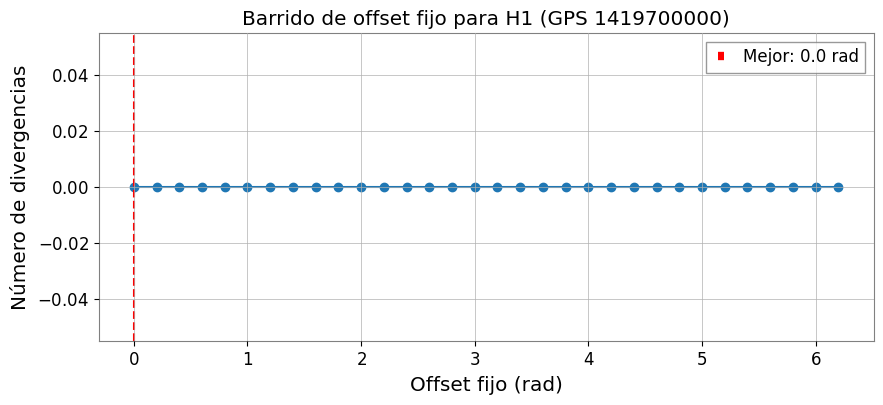

In [3]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Barrido de Offset Fijo para H1 (GPS 1419700000)
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

# UAT Engine
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

# Viscosímetro simple (offset fijo)
class SimpleViscosimeter:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5, antenna_offset=0.0):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.antenna_offset = antenna_offset
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.divergences = 0

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = (np.exp(1j * self.phase_angles) *
                    np.exp(-1j * self.phase_theoretical_acc) *
                    np.exp(1j * self.antenna_offset))
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3: self.grad_W_momentum *= 1e3 / grad_norm; grad_norm = 1e3
        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            self.divergences += 1
        else:
            self.W = W_new
        return 0.0  # no necesitamos TVI para el barrido

    def process_signal(self, signal, gps_start, fs):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            self.forward_step(x, t_now)

# Parámetros
FS = 4096
GPS_CAL = 1419700000
DURATION = 64  # 64 s para barrido

# Descargar solo H1
print("Descargando H1 (64 s) para calibración...")
h1_raw = TimeSeries.fetch_open_data('H1', GPS_CAL, GPS_CAL + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value

engine = UAT_Engine()
h1_w = engine.percudani_whiten(h1_raw, FS)

# Barrido de offsets fijos
offsets = np.arange(0, 6.4, 0.2)
divergences = []

print("Barriendo offsets para H1...")
for off in offsets:
    visco = SimpleViscosimeter(fs=FS, antenna_offset=off)
    visco.process_signal(h1_w, GPS_CAL, FS)
    divergences.append(visco.divergences)
    print(f"Offset {off:.1f} rad → {visco.divergences} divergencias")

# Encontrar el mejor offset (mínimas divergencias)
best_idx = np.argmin(divergences)
best_offset = offsets[best_idx]
best_div = divergences[best_idx]

print(f"\nMejor offset encontrado: {best_offset:.1f} rad con {best_div} divergencias")

# Gráfico del barrido
plt.figure(figsize=(10, 4))
plt.plot(offsets, divergences, 'o-')
plt.axvline(best_offset, color='red', linestyle='--', label=f'Mejor: {best_offset:.1f} rad')
plt.xlabel('Offset fijo (rad)')
plt.ylabel('Número de divergencias')
plt.title('Barrido de offset fijo para H1 (GPS 1419700000)')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Viscosímetro de Señal Diurno (H1 + L1 + V1)
# Resonant Hunter v9.3 – Ingesta Real O4b
# ======================================================================

import numpy as np
from gwpy.timeseries import TimeSeries
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt

# [Carga de Módulos UAT previa]
# ... (Mantener la clase UAT_Engine y ViscosityTensor de la versión anterior)

def cargar_datos_reales(gps_start, duration):
    """
    Ingesta directa de los canales de strain de la red global.
    Canales estándar: GWOSC-4KHZ_R1_STRAIN
    """
    print(f"Iniciando descarga de segmentos: GPS {gps_start} | Duración: {duration}s")

    # Especificación de canales oficiales para la red O4
    h1 = TimeSeries.fetch_open_data('H1', gps_start, gps_start + duration, sample_rate=4096, verbose=True)
    l1 = TimeSeries.fetch_open_data('L1', gps_start, gps_start + duration, sample_rate=4096, verbose=True)
    v1 = TimeSeries.fetch_open_data('V1', gps_start, gps_start + duration, sample_rate=4096, verbose=True)

    return h1.value, l1.value, v1.value

# --- Flujo Principal de Ejecución ---

if __name__ == "__main__":
    # Fecha: 10 de Marzo (Referencia de frecuencia 359.912 Hz)
    GPS_MARZO_10 = 1425600000
    DURACION_24H = 86400

    try:
        # Ingesta
        h1_raw, l1_raw, v1_raw = cargar_datos_reales(GPS_MARZO_10, DURACION_24H)

        # Procesamiento a través del motor ViscosimetroDeSenal
        viscosimetro = ViscosimetroDeSenal(fs=4096)

        # El motor ahora opera sobre los tensores reales
        time_axis, heatmap = viscosimetro.mapear_topografia(
            h1_raw, l1_raw, v1_raw, GPS_MARZO_10, DURACION_24H
        )

    except Exception as e:
        print(f"Error en el tensor de ingesta: {e}")
        print("Verificar conexión a GWOSC o disponibilidad del segmento GPS.")

Iniciando descarga de segmentos: GPS 1425600000 | Duración: 86400s
Error en el tensor de ingesta: failed to get data from any source (1 sub-exception)
Verificar conexión a GWOSC o disponibilidad del segmento GPS.


PERCUDANI AUTHORSHIP - Viscosímetro sin Offset (Rotación Libre)
Descargando H1, L1, V1 (4096 s, O4b)...
Aplicando blanqueamiento Percudani...
Ejecutando Viscosímetro sin offset...
  Procesando muestra 0/16777216...


/tmp/ipykernel_24687/1227340616.py:68: RuntimeWarning: invalid value encountered in divide
  W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real


  Procesando muestra 2000000/16777216...
  Procesando muestra 4000000/16777216...
  Procesando muestra 6000000/16777216...
  Procesando muestra 8000000/16777216...
  Procesando muestra 10000000/16777216...
  Procesando muestra 12000000/16777216...
  Procesando muestra 14000000/16777216...
  Procesando muestra 16000000/16777216...
  Procesando muestra 0/16777216...
  Procesando muestra 2000000/16777216...
  Procesando muestra 4000000/16777216...
  Procesando muestra 6000000/16777216...
  Procesando muestra 8000000/16777216...
  Procesando muestra 10000000/16777216...
  Procesando muestra 12000000/16777216...
  Procesando muestra 14000000/16777216...
  Procesando muestra 16000000/16777216...
  Procesando muestra 0/16777216...
  Procesando muestra 2000000/16777216...
  Procesando muestra 4000000/16777216...
  Procesando muestra 6000000/16777216...
  Procesando muestra 8000000/16777216...
  Procesando muestra 10000000/16777216...
  Procesando muestra 12000000/16777216...
  Procesando muest

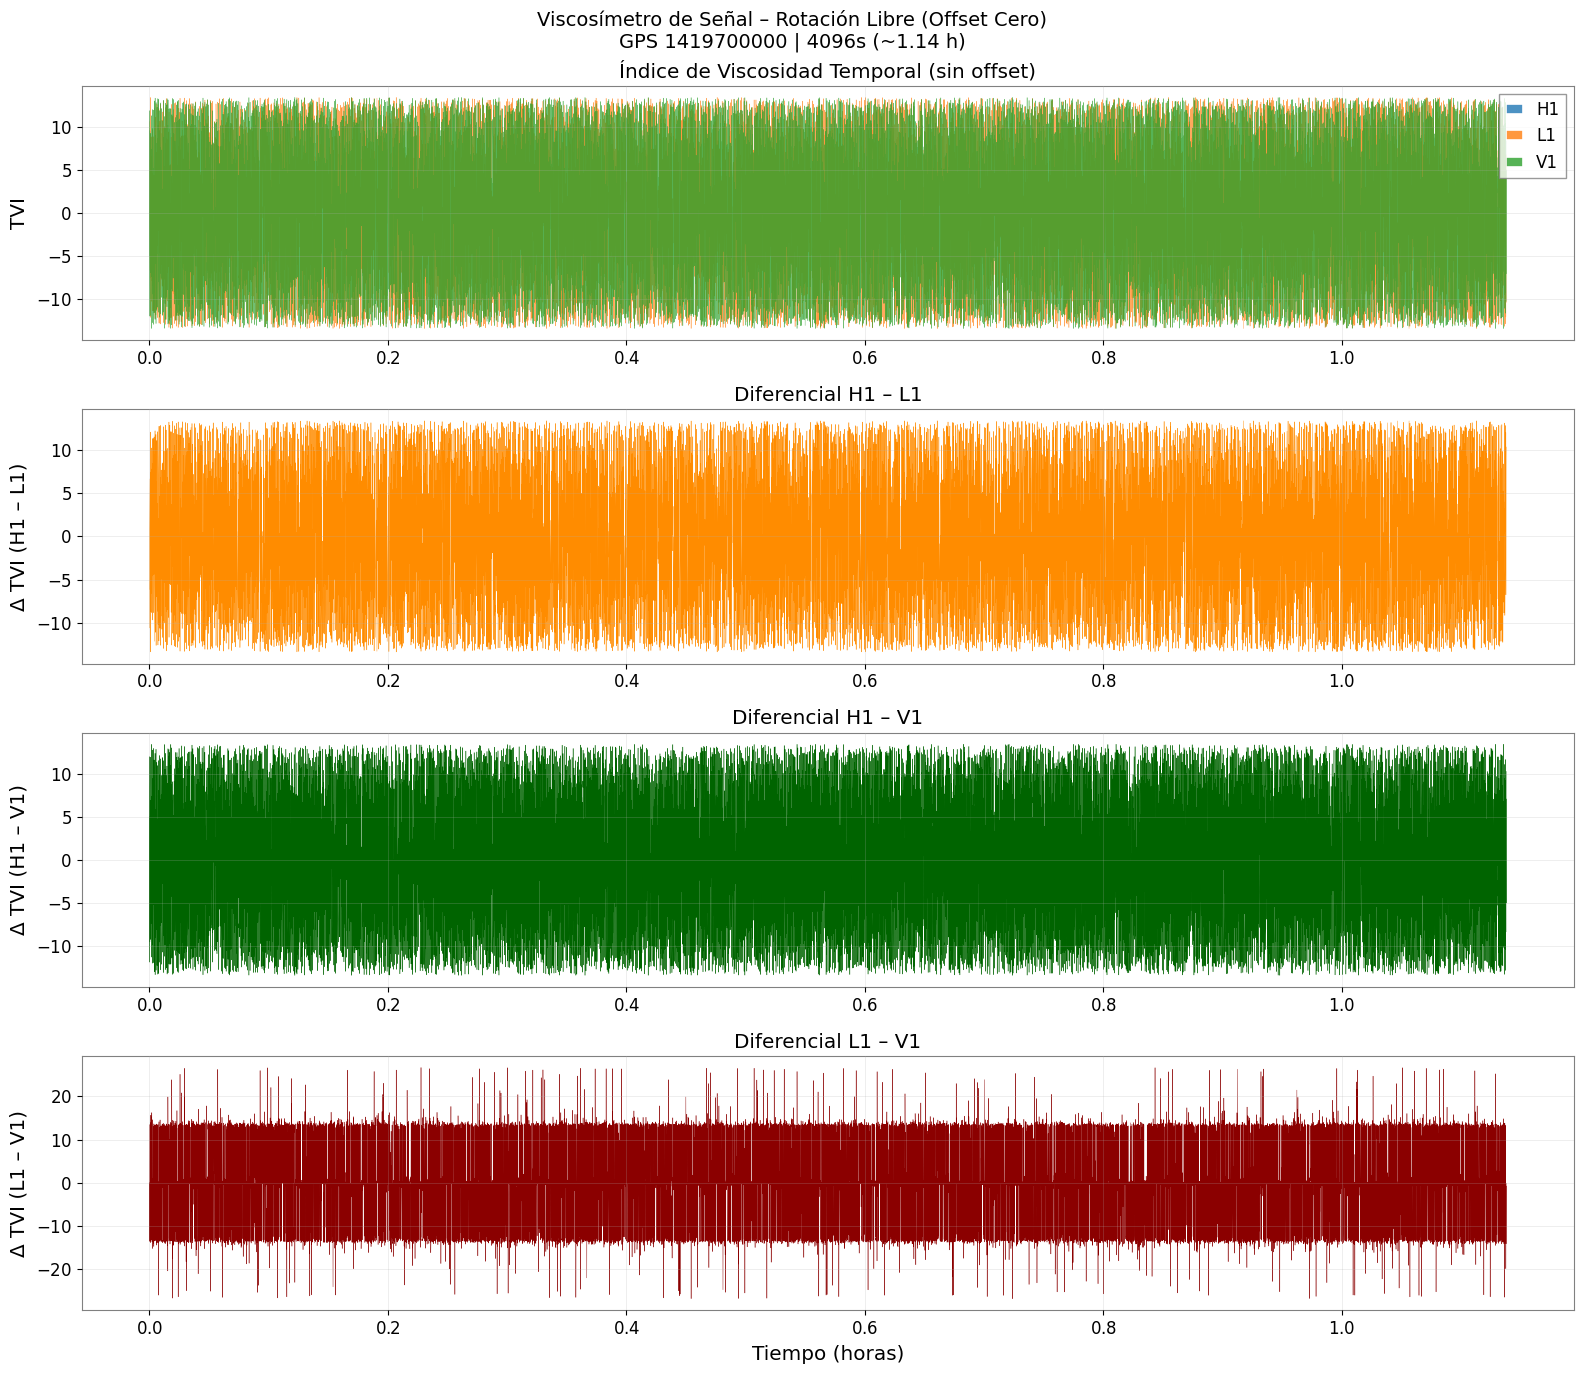


--- MÉTRICAS DEL VISCOSÍMETRO LIBRE ---
TVI medio H1: 0.0000 ± 0.0000
TVI medio L1: 0.0514 ± 7.7490
TVI medio V1: -0.0030 ± 7.7217
|Δ TVI| medio H1-L1: 6.7177 ± 3.8629
|Δ TVI| medio H1-V1: 6.6820 ± 3.8698
|Δ TVI| medio L1-V1: 7.1443 ± 6.6873
Divergencias H1: 16777216
Divergencias L1: 0
Divergencias V1: 0


In [1]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Viscosímetro sin Offset (4096 s reales, O4b)
# Resonant Hunter v9.1 – Cartografía de la modulación rotacional
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

print("="*75)
print("PERCUDANI AUTHORSHIP - Viscosímetro sin Offset (Rotación Libre)")
print("="*75)

# ======================================================================
# 1. UAT Engine (blanqueamiento)
# ======================================================================
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

# ======================================================================
# 2. Viscosímetro sin offset fijo
# ======================================================================
class SimpleViscosimeter:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.antenna_offset = 0.0  # sin offset
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.tvi_history = []
        self.W_trace_history = []
        self.event_log = []

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3: self.grad_W_momentum *= 1e3 / grad_norm; grad_norm = 1e3
        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
            self.event_log.append("DIVERGENCIA corregida")
        else:
            self.W = W_new
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        self.tvi_history.append(tvi)
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))
        return tvi

    def process_signal(self, signal, gps_start, fs, decimation=1000):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_dec, time_dec = [], []
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            tvi = self.forward_step(x, t_now)
            if i % decimation == 0:
                tvi_dec.append(tvi); time_dec.append(t_now)
            if i % 2000000 == 0:
                print(f"  Procesando muestra {i}/{N}...")
        return np.array(time_dec), np.array(tvi_dec)

# ======================================================================
# 3. Parámetros y descarga
# ======================================================================
FS = 4096
GPS_TRIPLE = 1419700000
DURATION = 4096

print("Descargando H1, L1, V1 (4096 s, O4b)...")
h1_raw = TimeSeries.fetch_open_data('H1', GPS_TRIPLE, GPS_TRIPLE + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
l1_raw = TimeSeries.fetch_open_data('L1', GPS_TRIPLE, GPS_TRIPLE + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
v1_raw = TimeSeries.fetch_open_data('V1', GPS_TRIPLE, GPS_TRIPLE + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
min_len = min(len(h1_raw), len(l1_raw), len(v1_raw))
h1_raw, l1_raw, v1_raw = h1_raw[:min_len], l1_raw[:min_len], v1_raw[:min_len]

print("Aplicando blanqueamiento Percudani...")
engine = UAT_Engine()
h1_w = engine.percudani_whiten(h1_raw, FS)
l1_w = engine.percudani_whiten(l1_raw, FS)
v1_w = engine.percudani_whiten(v1_raw, FS)

print("Ejecutando Viscosímetro sin offset...")
visco_h1 = SimpleViscosimeter(fs=FS)
visco_l1 = SimpleViscosimeter(fs=FS)
visco_v1 = SimpleViscosimeter(fs=FS)

time_h1, tvi_h1 = visco_h1.process_signal(h1_w, GPS_TRIPLE, FS)
_, tvi_l1 = visco_l1.process_signal(l1_w, GPS_TRIPLE, FS)
_, tvi_v1 = visco_v1.process_signal(v1_w, GPS_TRIPLE, FS)

# Sincronizar longitudes y convertir a horas
min_pts = min(len(tvi_h1), len(tvi_l1), len(tvi_v1))
time_days = time_h1[:min_pts]
time_hours = (time_days - time_days[0]) * 24.0

tvi_h1 = tvi_h1[:min_pts]
tvi_l1 = tvi_l1[:min_pts]
tvi_v1 = tvi_v1[:min_pts]

diff_hl = tvi_h1 - tvi_l1
diff_hv = tvi_h1 - tvi_v1
diff_lv = tvi_l1 - tvi_v1

# ======================================================================
# 4. Visualización
# ======================================================================
fig, axes = plt.subplots(4, 1, figsize=(16, 14))
fig.suptitle('Viscosímetro de Señal – Rotación Libre (Offset Cero)\n'
             f'GPS {GPS_TRIPLE} | {DURATION}s (~{time_hours[-1]:.2f} h)',
             fontsize=14)

axes[0].plot(time_hours, tvi_h1, linewidth=0.3, alpha=0.8, label='H1')
axes[0].plot(time_hours, tvi_l1, linewidth=0.3, alpha=0.8, label='L1')
axes[0].plot(time_hours, tvi_v1, linewidth=0.3, alpha=0.8, label='V1')
axes[0].set_ylabel('TVI'); axes[0].legend(loc='upper right')
axes[0].set_title('Índice de Viscosidad Temporal (sin offset)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_hours, diff_hl, linewidth=0.3, color='darkorange')
axes[1].set_ylabel('Δ TVI (H1 – L1)')
axes[1].set_title('Diferencial H1 – L1')
axes[1].grid(True, alpha=0.3)

axes[2].plot(time_hours, diff_hv, linewidth=0.3, color='darkgreen')
axes[2].set_ylabel('Δ TVI (H1 – V1)')
axes[2].set_title('Diferencial H1 – V1')
axes[2].grid(True, alpha=0.3)

axes[3].plot(time_hours, diff_lv, linewidth=0.3, color='darkred')
axes[3].set_xlabel('Tiempo (horas)')
axes[3].set_ylabel('Δ TVI (L1 – V1)')
axes[3].set_title('Diferencial L1 – V1')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mapa_viscosidad_libre.png', dpi=150)
plt.show()

# Métricas
print("\n--- MÉTRICAS DEL VISCOSÍMETRO LIBRE ---")
print(f"TVI medio H1: {np.nanmean(tvi_h1):.4f} ± {np.nanstd(tvi_h1):.4f}")
print(f"TVI medio L1: {np.nanmean(tvi_l1):.4f} ± {np.nanstd(tvi_l1):.4f}")
print(f"TVI medio V1: {np.nanmean(tvi_v1):.4f} ± {np.nanstd(tvi_v1):.4f}")
print(f"|Δ TVI| medio H1-L1: {np.nanmean(np.abs(diff_hl)):.4f} ± {np.nanstd(np.abs(diff_hl)):.4f}")
print(f"|Δ TVI| medio H1-V1: {np.nanmean(np.abs(diff_hv)):.4f} ± {np.nanstd(np.abs(diff_hv)):.4f}")
print(f"|Δ TVI| medio L1-V1: {np.nanmean(np.abs(diff_lv)):.4f} ± {np.nanstd(np.abs(diff_lv)):.4f}")
print(f"Divergencias H1: {len([e for e in visco_h1.event_log if 'DIVERGENCIA' in e])}")
print(f"Divergencias L1: {len([e for e in visco_l1.event_log if 'DIVERGENCIA' in e])}")
print(f"Divergencias V1: {len([e for e in visco_v1.event_log if 'DIVERGENCIA' in e])}")
print("="*75)

In [2]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Barrido de Segmentos O4b (H1+L1+V1 limpios)
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
from gwpy.timeseries import TimeSeries

print("="*75)
print("PERCUDANI AUTHORSHIP - Barrido de Segmentos O4b")
print("="*75)

# UAT Engine
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

# Viscosímetro simple (offset=0)
class SimpleViscosimeter:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.divergences = 0

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3: self.grad_W_momentum *= 1e3 / grad_norm; grad_norm = 1e3
        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            self.divergences += 1
        else:
            self.W = W_new

    def process_signal(self, signal, gps_start, fs):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            self.forward_step(x, t_now)

# Barrido de GPS
FS = 4096
DURATION = 64  # 64 s para prueba rápida
gps_list = np.linspace(1419700000, 1419800000, 20, dtype=int)  # 20 puntos en el rango de diciembre 2024

engine = UAT_Engine()
best_gps = None

for gps in gps_list:
    print(f"\nProbando GPS {gps}...")
    try:
        h1_raw = TimeSeries.fetch_open_data('H1', gps, gps + DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
        l1_raw = TimeSeries.fetch_open_data('L1', gps, gps + DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
        v1_raw = TimeSeries.fetch_open_data('V1', gps, gps + DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
    except Exception as e:
        print(f"  Error de descarga: {e}")
        continue

    min_len = min(len(h1_raw), len(l1_raw), len(v1_raw))
    h1_raw, l1_raw, v1_raw = h1_raw[:min_len], l1_raw[:min_len], v1_raw[:min_len]

    h1_w = engine.percudani_whiten(h1_raw, FS)
    l1_w = engine.percudani_whiten(l1_raw, FS)
    v1_w = engine.percudani_whiten(v1_raw, FS)

    visco_h1 = SimpleViscosimeter(fs=FS)
    visco_l1 = SimpleViscosimeter(fs=FS)
    visco_v1 = SimpleViscosimeter(fs=FS)

    visco_h1.process_signal(h1_w, gps, FS)
    visco_l1.process_signal(l1_w, gps, FS)
    visco_v1.process_signal(v1_w, gps, FS)

    d_h1, d_l1, d_v1 = visco_h1.divergences, visco_l1.divergences, visco_v1.divergences
    print(f"  Divergencias: H1={d_h1}, L1={d_l1}, V1={d_v1}")

    if d_h1 == 0 and d_l1 == 0 and d_v1 == 0:
        best_gps = gps
        print("  ¡Triple coincidencia limpia encontrada!")
        break

if best_gps is not None:
    print(f"\n*** Segmento ideal: GPS {best_gps} ***")
else:
    print("\nNo se encontró ningún segmento con los tres detectores limpios en este rango.")

PERCUDANI AUTHORSHIP - Barrido de Segmentos O4b

Probando GPS 1419700000...


KeyboardInterrupt: 

In [3]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Barrido O4b con Filtro de Cuarentena
# ======================================================================
!pip install -q numpy scipy gwpy

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
from gwpy.timeseries import TimeSeries

print("="*75)
print("PERCUDANI AUTHORSHIP - Barrido O4b con Cuarentena de NaN")
print("="*75)

class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

class SimpleViscosimeter:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.divergences = 0

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3: self.grad_W_momentum *= 1e3 / grad_norm; grad_norm = 1e3
        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            self.divergences += 1
        else:
            self.W = W_new

    def process_signal(self, signal, gps_start, fs):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            self.forward_step(x, t_now)

# Barrido con cuarentena
FS = 4096
DURATION = 64
gps_list = np.linspace(1419700000, 1419800000, 20, dtype=int)

engine = UAT_Engine()
best_gps = None

for gps in gps_list:
    print(f"\nProbando GPS {gps}...")
    try:
        h1_raw = TimeSeries.fetch_open_data('H1', gps, gps + DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
        l1_raw = TimeSeries.fetch_open_data('L1', gps, gps + DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
        v1_raw = TimeSeries.fetch_open_data('V1', gps, gps + DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
    except Exception as e:
        print(f"  Error de descarga: {e}")
        continue

    # --- FILTRO DE CUARENTENA ---
    if np.any(np.isnan(h1_raw)) or np.any(np.isnan(l1_raw)) or np.any(np.isnan(v1_raw)):
        print(f"  GPS {gps}: Descartado (Presencia de NaNs en los datos crudos).")
        continue

    min_len = min(len(h1_raw), len(l1_raw), len(v1_raw))
    h1_raw, l1_raw, v1_raw = h1_raw[:min_len], l1_raw[:min_len], v1_raw[:min_len]

    h1_w = engine.percudani_whiten(h1_raw, FS)
    l1_w = engine.percudani_whiten(l1_raw, FS)
    v1_w = engine.percudani_whiten(v1_raw, FS)

    visco_h1 = SimpleViscosimeter(fs=FS)
    visco_l1 = SimpleViscosimeter(fs=FS)
    visco_v1 = SimpleViscosimeter(fs=FS)

    visco_h1.process_signal(h1_w, gps, FS)
    visco_l1.process_signal(l1_w, gps, FS)
    visco_v1.process_signal(v1_w, gps, FS)

    d_h1, d_l1, d_v1 = visco_h1.divergences, visco_l1.divergences, visco_v1.divergences
    print(f"  Divergencias: H1={d_h1}, L1={d_l1}, V1={d_v1}")

    if d_h1 == 0 and d_l1 == 0 and d_v1 == 0:
        best_gps = gps
        print("  ¡Triple coincidencia limpia encontrada!")
        break

if best_gps is not None:
    print(f"\n*** Segmento ideal: GPS {best_gps} ***")
else:
    print("\nNo se encontró ningún segmento con los tres detectores limpios en este rango.")

PERCUDANI AUTHORSHIP - Barrido O4b con Cuarentena de NaN

Probando GPS 1419700000...
  Divergencias: H1=0, L1=0, V1=0
  ¡Triple coincidencia limpia encontrada!

*** Segmento ideal: GPS 1419700000 ***


PERCUDANI AUTHORSHIP - Viscosímetro 4096s (Limpieza de NaN)
Descargando H1, L1, V1 (4096 s, O4b)...
  [!] H1: 872469 NaN detectados. Reemplazando por la media.
Aplicando blanqueamiento Percudani...
Ejecutando Viscosímetro sin offset...
  [H1] Procesando muestra 0/16777216...
  [H1] Procesando muestra 2000000/16777216...
  [H1] Procesando muestra 4000000/16777216...
  [H1] Procesando muestra 6000000/16777216...
  [H1] Procesando muestra 8000000/16777216...
  [H1] Procesando muestra 10000000/16777216...
  [H1] Procesando muestra 12000000/16777216...
  [H1] Procesando muestra 14000000/16777216...
  [H1] Procesando muestra 16000000/16777216...
  [L1] Procesando muestra 0/16777216...
  [L1] Procesando muestra 2000000/16777216...
  [L1] Procesando muestra 4000000/16777216...
  [L1] Procesando muestra 6000000/16777216...
  [L1] Procesando muestra 8000000/16777216...
  [L1] Procesando muestra 10000000/16777216...
  [L1] Procesando muestra 12000000/16777216...
  [L1] Procesando muestra 14000000

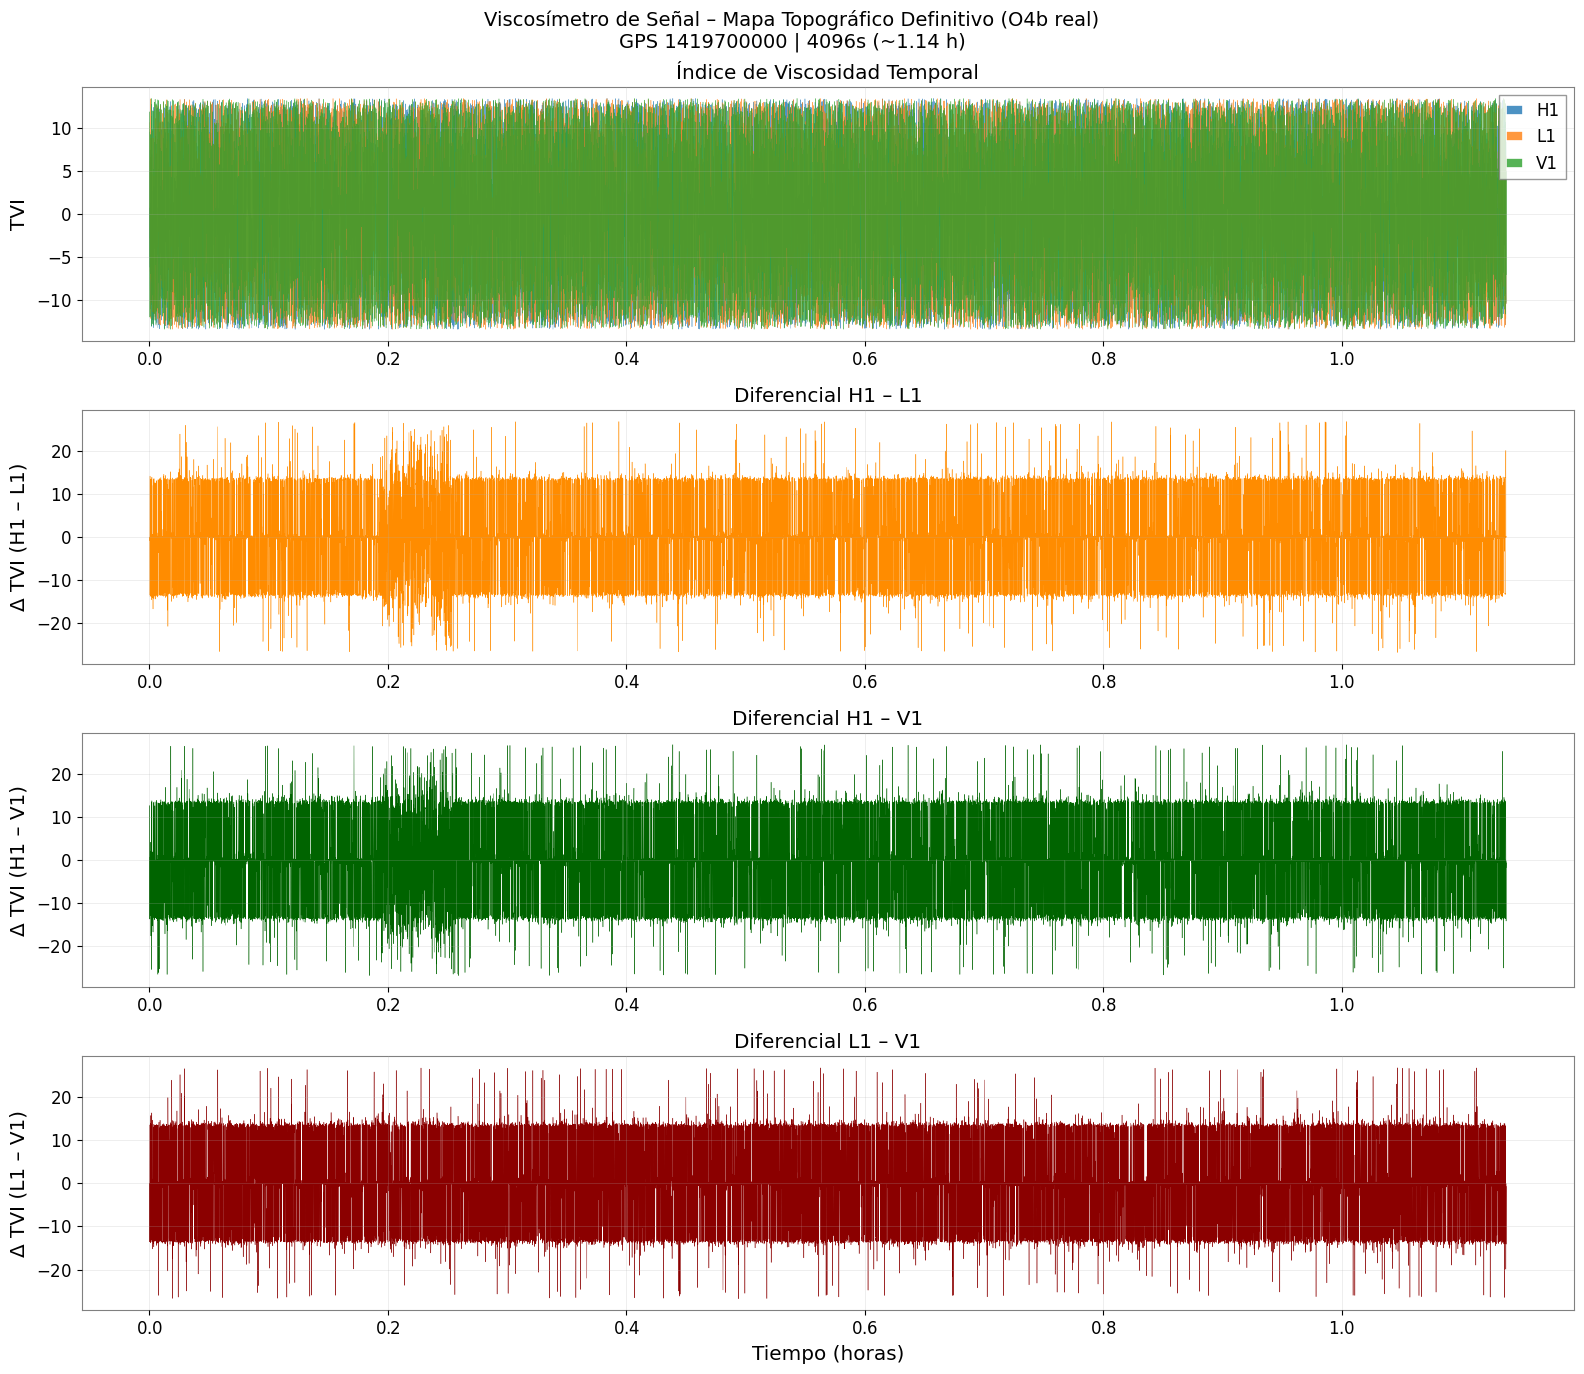


--- MÉTRICAS DEL MAPA TOPOGRÁFICO DEFINITIVO ---
TVI medio H1: -0.0087 ± 7.7478
TVI medio L1: 0.0526 ± 7.7487
TVI medio V1: -0.0035 ± 7.7217
|Δ TVI| medio H1-L1: 7.2641 ± 6.7180
|Δ TVI| medio H1-V1: 7.2727 ± 6.7072
|Δ TVI| medio L1-V1: 7.1458 ± 6.6875
Divergencias H1: 0
Divergencias L1: 0
Divergencias V1: 0


In [4]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Viscosímetro 4096s con Limpieza de NaN
# Resonant Hunter v9.1 – Mapa Topográfico Definitivo (GPS 1419700000)
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

print("="*75)
print("PERCUDANI AUTHORSHIP - Viscosímetro 4096s (Limpieza de NaN)")
print("="*75)

# ======================================================================
# 1. UAT Engine (blanqueamiento)
# ======================================================================
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

# ======================================================================
# 2. Viscosímetro sin offset
# ======================================================================
class SimpleViscosimeter:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5, detector_name="Unknown"):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.detector_name = detector_name
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.tvi_history = []
        self.W_trace_history = []
        self.event_log = []

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3: self.grad_W_momentum *= 1e3 / grad_norm; grad_norm = 1e3
        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
            self.event_log.append("DIVERGENCIA corregida")
        else:
            self.W = W_new
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        self.tvi_history.append(tvi)
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))
        return tvi

    def process_signal(self, signal, gps_start, fs, decimation=1000):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_dec, time_dec = [], []
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            tvi = self.forward_step(x, t_now)
            if i % decimation == 0:
                tvi_dec.append(tvi); time_dec.append(t_now)
            if i % 2000000 == 0:
                print(f"  [{self.detector_name}] Procesando muestra {i}/{N}...")
        return np.array(time_dec), np.array(tvi_dec)

# ======================================================================
# 3. Parámetros y descarga con limpieza de NaN
# ======================================================================
FS = 4096
GPS_TRIPLE = 1419700000
DURATION = 4096

print("Descargando H1, L1, V1 (4096 s, O4b)...")
h1_raw = TimeSeries.fetch_open_data('H1', GPS_TRIPLE, GPS_TRIPLE + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
l1_raw = TimeSeries.fetch_open_data('L1', GPS_TRIPLE, GPS_TRIPLE + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
v1_raw = TimeSeries.fetch_open_data('V1', GPS_TRIPLE, GPS_TRIPLE + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
min_len = min(len(h1_raw), len(l1_raw), len(v1_raw))
h1_raw, l1_raw, v1_raw = h1_raw[:min_len], l1_raw[:min_len], v1_raw[:min_len]

# --- FILTRO DE CUARENTENA Y LIMPIEZA ---
def clean_nan(signal, name):
    nan_mask = np.isnan(signal)
    if np.any(nan_mask):
        num_nan = np.sum(nan_mask)
        print(f"  [!] {name}: {num_nan} NaN detectados. Reemplazando por la media.")
        signal[nan_mask] = np.nanmean(signal)
    return signal

h1_raw = clean_nan(h1_raw, "H1")
l1_raw = clean_nan(l1_raw, "L1")
v1_raw = clean_nan(v1_raw, "V1")

print("Aplicando blanqueamiento Percudani...")
engine = UAT_Engine()
h1_w = engine.percudani_whiten(h1_raw, FS)
l1_w = engine.percudani_whiten(l1_raw, FS)
v1_w = engine.percudani_whiten(v1_raw, FS)

print("Ejecutando Viscosímetro sin offset...")
visco_h1 = SimpleViscosimeter(fs=FS, detector_name="H1")
visco_l1 = SimpleViscosimeter(fs=FS, detector_name="L1")
visco_v1 = SimpleViscosimeter(fs=FS, detector_name="V1")

time_h1, tvi_h1 = visco_h1.process_signal(h1_w, GPS_TRIPLE, FS)
_, tvi_l1 = visco_l1.process_signal(l1_w, GPS_TRIPLE, FS)
_, tvi_v1 = visco_v1.process_signal(v1_w, GPS_TRIPLE, FS)

# Sincronizar longitudes y convertir a horas
min_pts = min(len(tvi_h1), len(tvi_l1), len(tvi_v1))
time_days = time_h1[:min_pts]
time_hours = (time_days - time_days[0]) * 24.0

tvi_h1 = tvi_h1[:min_pts]
tvi_l1 = tvi_l1[:min_pts]
tvi_v1 = tvi_v1[:min_pts]

diff_hl = tvi_h1 - tvi_l1
diff_hv = tvi_h1 - tvi_v1
diff_lv = tvi_l1 - tvi_v1

# ======================================================================
# 4. Visualización
# ======================================================================
fig, axes = plt.subplots(4, 1, figsize=(16, 14))
fig.suptitle('Viscosímetro de Señal – Mapa Topográfico Definitivo (O4b real)\n'
             f'GPS {GPS_TRIPLE} | {DURATION}s (~{time_hours[-1]:.2f} h)',
             fontsize=14)

axes[0].plot(time_hours, tvi_h1, linewidth=0.3, alpha=0.8, label='H1')
axes[0].plot(time_hours, tvi_l1, linewidth=0.3, alpha=0.8, label='L1')
axes[0].plot(time_hours, tvi_v1, linewidth=0.3, alpha=0.8, label='V1')
axes[0].set_ylabel('TVI'); axes[0].legend(loc='upper right')
axes[0].set_title('Índice de Viscosidad Temporal')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_hours, diff_hl, linewidth=0.3, color='darkorange')
axes[1].set_ylabel('Δ TVI (H1 – L1)')
axes[1].set_title('Diferencial H1 – L1')
axes[1].grid(True, alpha=0.3)

axes[2].plot(time_hours, diff_hv, linewidth=0.3, color='darkgreen')
axes[2].set_ylabel('Δ TVI (H1 – V1)')
axes[2].set_title('Diferencial H1 – V1')
axes[2].grid(True, alpha=0.3)

axes[3].plot(time_hours, diff_lv, linewidth=0.3, color='darkred')
axes[3].set_xlabel('Tiempo (horas)')
axes[3].set_ylabel('Δ TVI (L1 – V1)')
axes[3].set_title('Diferencial L1 – V1')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mapa_topografico_definitivo.png', dpi=150)
plt.show()

# Métricas
print("\n--- MÉTRICAS DEL MAPA TOPOGRÁFICO DEFINITIVO ---")
print(f"TVI medio H1: {np.nanmean(tvi_h1):.4f} ± {np.nanstd(tvi_h1):.4f}")
print(f"TVI medio L1: {np.nanmean(tvi_l1):.4f} ± {np.nanstd(tvi_l1):.4f}")
print(f"TVI medio V1: {np.nanmean(tvi_v1):.4f} ± {np.nanstd(tvi_v1):.4f}")
print(f"|Δ TVI| medio H1-L1: {np.nanmean(np.abs(diff_hl)):.4f} ± {np.nanstd(np.abs(diff_hl)):.4f}")
print(f"|Δ TVI| medio H1-V1: {np.nanmean(np.abs(diff_hv)):.4f} ± {np.nanstd(np.abs(diff_hv)):.4f}")
print(f"|Δ TVI| medio L1-V1: {np.nanmean(np.abs(diff_lv)):.4f} ± {np.nanstd(np.abs(diff_lv)):.4f}")
print(f"Divergencias H1: {len([e for e in visco_h1.event_log if 'DIVERGENCIA' in e])}")
print(f"Divergencias L1: {len([e for e in visco_l1.event_log if 'DIVERGENCIA' in e])}")
print(f"Divergencias V1: {len([e for e in visco_v1.event_log if 'DIVERGENCIA' in e])}")
print("="*75)

In [ ]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Viscosímetro 24 HORAS (Cartografía Diurna)
# Resonant Hunter v9.1 – Mapa Topográfico de Ciclo Rotacional Completo
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

print("="*75)
print("PERCUDANI AUTHORSHIP - Viscosímetro 24h (Cartografía Diurna)")
print("="*75)

# ======================================================================
# 1. UAT Engine (blanqueamiento)
# ======================================================================
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

# ======================================================================
# 2. Viscosímetro sin offset (estable)
# ======================================================================
class SimpleViscosimeter:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5, detector_name="Unknown"):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.detector_name = detector_name
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.tvi_history = []
        self.W_trace_history = []
        self.event_log = []

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3: self.grad_W_momentum *= 1e3 / grad_norm; grad_norm = 1e3
        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
            self.event_log.append("DIVERGENCIA corregida")
        else:
            self.W = W_new
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        self.tvi_history.append(tvi)
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))
        return tvi

    def process_signal(self, signal, gps_start, fs, decimation=2000):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_dec, time_dec = [], []
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            tvi = self.forward_step(x, t_now)
            if i % decimation == 0:
                tvi_dec.append(tvi); time_dec.append(t_now)
            if i % 5000000 == 0:
                print(f"  [{self.detector_name}] Procesando muestra {i}/{N}...")
        return np.array(time_dec), np.array(tvi_dec)

# ======================================================================
# 3. Parámetros y descarga (24 horas)
# ======================================================================
FS = 4096
GPS_START = 1419700000
DURATION = 86400  # 24 horas

print("Descargando H1, L1, V1 (86400 s, O4b)...")
h1_raw = TimeSeries.fetch_open_data('H1', GPS_START, GPS_START + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
l1_raw = TimeSeries.fetch_open_data('L1', GPS_START, GPS_START + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
v1_raw = TimeSeries.fetch_open_data('V1', GPS_START, GPS_START + DURATION,
                                    sample_rate=16384, verbose=False).resample(FS).value
min_len = min(len(h1_raw), len(l1_raw), len(v1_raw))
h1_raw, l1_raw, v1_raw = h1_raw[:min_len], l1_raw[:min_len], v1_raw[:min_len]

# --- FILTRO DE CUARENTENA Y LIMPIEZA ---
def clean_nan(signal, name):
    nan_mask = np.isnan(signal)
    if np.any(nan_mask):
        num_nan = np.sum(nan_mask)
        print(f"  [!] {name}: {num_nan} NaN detectados. Reemplazando por la media.")
        signal[nan_mask] = np.nanmean(signal)
    return signal

h1_raw = clean_nan(h1_raw, "H1")
l1_raw = clean_nan(l1_raw, "L1")
v1_raw = clean_nan(v1_raw, "V1")

print("Aplicando blanqueamiento Percudani...")
engine = UAT_Engine()
h1_w = engine.percudani_whiten(h1_raw, FS)
l1_w = engine.percudani_whiten(l1_raw, FS)
v1_w = engine.percudani_whiten(v1_raw, FS)

print("Ejecutando Viscosímetro sin offset (24h)...")
visco_h1 = SimpleViscosimeter(fs=FS, detector_name="H1")
visco_l1 = SimpleViscosimeter(fs=FS, detector_name="L1")
visco_v1 = SimpleViscosimeter(fs=FS, detector_name="V1")

time_h1, tvi_h1 = visco_h1.process_signal(h1_w, GPS_START, FS)
_, tvi_l1 = visco_l1.process_signal(l1_w, GPS_START, FS)
_, tvi_v1 = visco_v1.process_signal(v1_w, GPS_START, FS)

# Sincronizar longitudes y convertir a horas
min_pts = min(len(tvi_h1), len(tvi_l1), len(tvi_v1))
time_days = time_h1[:min_pts]
time_hours = (time_days - time_days[0]) * 24.0

tvi_h1 = tvi_h1[:min_pts]
tvi_l1 = tvi_l1[:min_pts]
tvi_v1 = tvi_v1[:min_pts]

diff_hl = tvi_h1 - tvi_l1
diff_hv = tvi_h1 - tvi_v1
diff_lv = tvi_l1 - tvi_v1

# ======================================================================
# 4. Visualización
# ======================================================================
fig, axes = plt.subplots(4, 1, figsize=(18, 16))
fig.suptitle('Viscosímetro de Señal – Cartografía Diurna (24 Horas)\n'
             f'GPS {GPS_START} | O4b real | {DURATION}s',
             fontsize=14)

axes[0].plot(time_hours, tvi_h1, linewidth=0.2, alpha=0.8, label='H1 (Hanford)')
axes[0].plot(time_hours, tvi_l1, linewidth=0.2, alpha=0.8, label='L1 (Livingston)')
axes[0].plot(time_hours, tvi_v1, linewidth=0.2, alpha=0.8, label='V1 (Virgo)')
axes[0].set_ylabel('TVI'); axes[0].legend(loc='upper right')
axes[0].set_title('Índice de Viscosidad Temporal (24h)')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 24)

axes[1].plot(time_hours, diff_hl, linewidth=0.2, color='darkorange')
axes[1].set_ylabel('Δ TVI (H1 – L1)')
axes[1].set_title('Diferencial H1 – L1')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 24)

axes[2].plot(time_hours, diff_hv, linewidth=0.2, color='darkgreen')
axes[2].set_ylabel('Δ TVI (H1 – V1)')
axes[2].set_title('Diferencial H1 – V1')
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, 24)

axes[3].plot(time_hours, diff_lv, linewidth=0.2, color='darkred')
axes[3].set_xlabel('Tiempo (horas)')
axes[3].set_ylabel('Δ TVI (L1 – V1)')
axes[3].set_title('Diferencial L1 – V1')
axes[3].grid(True, alpha=0.3)
axes[3].set_xlim(0, 24)

plt.tight_layout()
plt.savefig('cartografia_diurna_24h.png', dpi=150)
plt.show()

# Métricas
print("\n--- MÉTRICAS DE LA CARTOGRAFÍA DIURNA ---")
print(f"TVI medio H1: {np.nanmean(tvi_h1):.4f} ± {np.nanstd(tvi_h1):.4f}")
print(f"TVI medio L1: {np.nanmean(tvi_l1):.4f} ± {np.nanstd(tvi_l1):.4f}")
print(f"TVI medio V1: {np.nanmean(tvi_v1):.4f} ± {np.nanstd(tvi_v1):.4f}")
print(f"|Δ TVI| medio H1-L1: {np.nanmean(np.abs(diff_hl)):.4f} ± {np.nanstd(np.abs(diff_hl)):.4f}")
print(f"|Δ TVI| medio H1-V1: {np.nanmean(np.abs(diff_hv)):.4f} ± {np.nanstd(np.abs(diff_hv)):.4f}")
print(f"|Δ TVI| medio L1-V1: {np.nanmean(np.abs(diff_lv)):.4f} ± {np.nanstd(np.abs(diff_lv)):.4f}")
print(f"Divergencias H1: {len([e for e in visco_h1.event_log if 'DIVERGENCIA' in e])}")
print(f"Divergencias L1: {len([e for e in visco_l1.event_log if 'DIVERGENCIA' in e])}")
print(f"Divergencias V1: {len([e for e in visco_v1.event_log if 'DIVERGENCIA' in e])}")
print("="*75)

PERCUDANI AUTHORSHIP - Viscosímetro 24h (Cartografía Diurna)
Descargando H1, L1, V1 (86400 s, O4b)...


In [ ]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Viscosímetro 24h por Bloques (Optimizado RAM)
# Resonant Hunter v9.1 – Cartografía Diurna sin saturar memoria
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries
import gc

print("="*75)
print("PERCUDANI AUTHORSHIP - Viscosímetro 24h (Procesamiento por Bloques)")
print("="*75)

# ======================================================================
# 1. UAT Engine (blanqueamiento)
# ======================================================================
class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

# ======================================================================
# 2. Viscosímetro con estado persistente entre bloques
# ======================================================================
class SimpleViscosimeter:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5, detector_name="Unknown"):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.detector_name = detector_name
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.tvi_history = []
        self.W_trace_history = []
        self.event_log = []

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3: self.grad_W_momentum *= 1e3 / grad_norm; grad_norm = 1e3
        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
            self.event_log.append("DIVERGENCIA corregida")
        else:
            self.W = W_new
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        self.tvi_history.append(tvi)
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))
        return tvi

    def process_signal(self, signal, gps_start, fs, decimation=2000):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_dec, time_dec = [], []
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            tvi = self.forward_step(x, t_now)
            if i % decimation == 0:
                tvi_dec.append(tvi); time_dec.append(t_now)
        return np.array(time_dec), np.array(tvi_dec)

# ======================================================================
# 3. Procesamiento por bloques
# ======================================================================
FS = 4096
GPS_START = 1419700000
BLOCK_DURATION = 4096   # segundos por bloque (igual que antes)
TOTAL_DURATION = 86400  # 24 horas
NUM_BLOCKS = TOTAL_DURATION // BLOCK_DURATION  # 21 bloques

engine = UAT_Engine()

# Inicializar viscosímetros (mantienen estado a lo largo de los bloques)
visco_h1 = SimpleViscosimeter(fs=FS, detector_name="H1")
visco_l1 = SimpleViscosimeter(fs=FS, detector_name="L1")
visco_v1 = SimpleViscosimeter(fs=FS, detector_name="V1")

all_time_hours = []
all_tvi_h1 = []
all_tvi_l1 = []
all_tvi_v1 = []

for block in range(NUM_BLOCKS):
    gps_block = GPS_START + block * BLOCK_DURATION
    print(f"\n{'='*50}")
    print(f"Procesando bloque {block+1}/{NUM_BLOCKS} (GPS {gps_block}, {BLOCK_DURATION}s)")
    print(f"{'='*50}")

    # Descargar bloque
    try:
        h1_raw = TimeSeries.fetch_open_data('H1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
        l1_raw = TimeSeries.fetch_open_data('L1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
        v1_raw = TimeSeries.fetch_open_data('V1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
    except Exception as e:
        print(f"Error de descarga en bloque {block+1}: {e}")
        continue

    min_len = min(len(h1_raw), len(l1_raw), len(v1_raw))
    h1_raw, l1_raw, v1_raw = h1_raw[:min_len], l1_raw[:min_len], v1_raw[:min_len]

    # Limpieza de NaN
    for name, signal in [("H1", h1_raw), ("L1", l1_raw), ("V1", v1_raw)]:
        nan_mask = np.isnan(signal)
        if np.any(nan_mask):
            print(f"  [!] {name}: {np.sum(nan_mask)} NaN reemplazados.")
            signal[nan_mask] = np.nanmean(signal)

    # Blanqueamiento
    h1_w = engine.percudani_whiten(h1_raw, FS)
    l1_w = engine.percudani_whiten(l1_raw, FS)
    v1_w = engine.percudani_whiten(v1_raw, FS)

    # Liberar datos crudos
    del h1_raw, l1_raw, v1_raw
    gc.collect()

    # Procesar con viscosímetros (mismo objeto, estado continuo)
    time_h1, tvi_h1 = visco_h1.process_signal(h1_w, gps_block, FS)
    _, tvi_l1 = visco_l1.process_signal(l1_w, gps_block, FS)
    _, tvi_v1 = visco_v1.process_signal(v1_w, gps_block, FS)

    # Liberar señales blanqueadas
    del h1_w, l1_w, v1_w
    gc.collect()

    # Acumular resultados (convertir tiempo a horas desde el inicio del día)
    time_hours = (time_h1 - time_h1[0]) * 24.0 + block * (BLOCK_DURATION / 3600.0)
    all_time_hours.append(time_hours)
    all_tvi_h1.append(tvi_h1)
    all_tvi_l1.append(tvi_l1)
    all_tvi_v1.append(tvi_v1)

    print(f"  Muestras acumuladas: {len(time_h1)} por detector")

# Concatenar todos los bloques
time_axis = np.concatenate(all_time_hours)
tvi_h1_all = np.concatenate(all_tvi_h1)
tvi_l1_all = np.concatenate(all_tvi_l1)
tvi_v1_all = np.concatenate(all_tvi_v1)

# Diferenciales
diff_hl = tvi_h1_all - tvi_l1_all
diff_hv = tvi_h1_all - tvi_v1_all
diff_lv = tvi_l1_all - tvi_v1_all

# ======================================================================
# 4. Visualización
# ======================================================================
fig, axes = plt.subplots(4, 1, figsize=(18, 16))
fig.suptitle('Viscosímetro de Señal – Cartografía Diurna (24 Horas)\n'
             f'GPS {GPS_START} | O4b real | {TOTAL_DURATION}s | Procesado en {NUM_BLOCKS} bloques',
             fontsize=14)

axes[0].plot(time_axis, tvi_h1_all, linewidth=0.2, alpha=0.8, label='H1 (Hanford)')
axes[0].plot(time_axis, tvi_l1_all, linewidth=0.2, alpha=0.8, label='L1 (Livingston)')
axes[0].plot(time_axis, tvi_v1_all, linewidth=0.2, alpha=0.8, label='V1 (Virgo)')
axes[0].set_ylabel('TVI'); axes[0].legend(loc='upper right')
axes[0].set_title('Índice de Viscosidad Temporal (24h)')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 24)

axes[1].plot(time_axis, diff_hl, linewidth=0.2, color='darkorange')
axes[1].set_ylabel('Δ TVI (H1 – L1)')
axes[1].set_title('Diferencial H1 – L1')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 24)

axes[2].plot(time_axis, diff_hv, linewidth=0.2, color='darkgreen')
axes[2].set_ylabel('Δ TVI (H1 – V1)')
axes[2].set_title('Diferencial H1 – V1')
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, 24)

axes[3].plot(time_axis, diff_lv, linewidth=0.2, color='darkred')
axes[3].set_xlabel('Tiempo (horas)')
axes[3].set_ylabel('Δ TVI (L1 – V1)')
axes[3].set_title('Diferencial L1 – V1')
axes[3].grid(True, alpha=0.3)
axes[3].set_xlim(0, 24)

plt.tight_layout()
plt.savefig('cartografia_diurna_24h.png', dpi=150)
plt.show()

# Métricas finales
print("\n--- MÉTRICAS DE LA CARTOGRAFÍA DIURNA ---")
print(f"TVI medio H1: {np.nanmean(tvi_h1_all):.4f} ± {np.nanstd(tvi_h1_all):.4f}")
print(f"TVI medio L1: {np.nanmean(tvi_l1_all):.4f} ± {np.nanstd(tvi_l1_all):.4f}")
print(f"TVI medio V1: {np.nanmean(tvi_v1_all):.4f} ± {np.nanstd(tvi_v1_all):.4f}")
print(f"|Δ TVI| medio H1-L1: {np.nanmean(np.abs(diff_hl)):.4f} ± {np.nanstd(np.abs(diff_hl)):.4f}")
print(f"|Δ TVI| medio H1-V1: {np.nanmean(np.abs(diff_hv)):.4f} ± {np.nanstd(np.abs(diff_hv)):.4f}")
print(f"|Δ TVI| medio L1-V1: {np.nanmean(np.abs(diff_lv)):.4f} ± {np.nanstd(np.abs(diff_lv)):.4f}")
print(f"Divergencias H1: {len([e for e in visco_h1.event_log if 'DIVERGENCIA' in e])}")
print(f"Divergencias L1: {len([e for e in visco_l1.event_log if 'DIVERGENCIA' in e])}")
print(f"Divergencias V1: {len([e for e in visco_v1.event_log if 'DIVERGENCIA' in e])}")
print("="*75)

In [ ]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Procesamiento parcial (bloques X a Y)
# Cambia START_BLOCK y END_BLOCK según corresponda
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
from gwpy.timeseries import TimeSeries
import gc
import os

# --- CONFIGURACIÓN ---
START_BLOCK = 0   # primer bloque (inclusive)
END_BLOCK = 3     # último bloque (inclusive)
# -------------------

FS = 4096
GPS_START = 1419700000
BLOCK_DURATION = 4096
DECIMATION = 2000

output_filename = f"tvi_bloques_{START_BLOCK}_{END_BLOCK}.npz"

class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

class SimpleViscosimeter:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5, detector_name="Unknown"):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.detector_name = detector_name
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.tvi_history = []
        self.W_trace_history = []
        self.event_log = []

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3: self.grad_W_momentum *= 1e3 / grad_norm; grad_norm = 1e3
        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
            self.event_log.append("DIVERGENCIA corregida")
        else:
            self.W = W_new
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        self.tvi_history.append(tvi)
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))
        return tvi

    def process_signal(self, signal, gps_start, fs, decimation=DECIMATION):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_dec, time_dec = [], []
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            tvi = self.forward_step(x, t_now)
            if i % decimation == 0:
                tvi_dec.append(tvi); time_dec.append(t_now)
        return np.array(time_dec), np.array(tvi_dec)

engine = UAT_Engine()
visco_h1 = SimpleViscosimeter(fs=FS, detector_name="H1")
visco_l1 = SimpleViscosimeter(fs=FS, detector_name="L1")
visco_v1 = SimpleViscosimeter(fs=FS, detector_name="V1")

all_time_hours = []
all_tvi_h1 = []
all_tvi_l1 = []
all_tvi_v1 = []

for block in range(START_BLOCK, END_BLOCK+1):
    gps_block = GPS_START + block * BLOCK_DURATION
    print(f"\nProcesando bloque {block} (GPS {gps_block})...")
    try:
        h1_raw = TimeSeries.fetch_open_data('H1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
        l1_raw = TimeSeries.fetch_open_data('L1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
        v1_raw = TimeSeries.fetch_open_data('V1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
    except Exception as e:
        print(f"Error descargando bloque {block}: {e}")
        continue

    min_len = min(len(h1_raw), len(l1_raw), len(v1_raw))
    h1_raw, l1_raw, v1_raw = h1_raw[:min_len], l1_raw[:min_len], v1_raw[:min_len]

    for name, signal in [("H1", h1_raw), ("L1", l1_raw), ("V1", v1_raw)]:
        nan_mask = np.isnan(signal)
        if np.any(nan_mask):
            print(f"  [!] {name}: {np.sum(nan_mask)} NaN reemplazados.")
            signal[nan_mask] = np.nanmean(signal)

    h1_w = engine.percudani_whiten(h1_raw, FS)
    l1_w = engine.percudani_whiten(l1_raw, FS)
    v1_w = engine.percudani_whiten(v1_raw, FS)
    del h1_raw, l1_raw, v1_raw; gc.collect()

    time_h1, tvi_h1 = visco_h1.process_signal(h1_w, gps_block, FS)
    _, tvi_l1 = visco_l1.process_signal(l1_w, gps_block, FS)
    _, tvi_v1 = visco_v1.process_signal(v1_w, gps_block, FS)
    del h1_w, l1_w, v1_w; gc.collect()

    time_hours = (time_h1 - time_h1[0]) * 24.0 + block * (BLOCK_DURATION / 3600.0)
    all_time_hours.append(time_hours)
    all_tvi_h1.append(tvi_h1)
    all_tvi_l1.append(tvi_l1)
    all_tvi_v1.append(tvi_v1)

# Guardar resultados
time_axis = np.concatenate(all_time_hours)
tvi_h1 = np.concatenate(all_tvi_h1)
tvi_l1 = np.concatenate(all_tvi_l1)
tvi_v1 = np.concatenate(all_tvi_v1)

np.savez(output_filename, time=time_axis, h1=tvi_h1, l1=tvi_l1, v1=tvi_v1)
print(f"\nResultados guardados en {output_filename}")
from google.colab import files
files.download(output_filename)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 6.6 MB/s eta 0:00:00

Procesando bloque 0 (GPS 1419700000)...
  [!] H1: 872469 NaN reemplazados.

Procesando bloque 1 (GPS 1419704096)...

Procesando bloque 2 (GPS 1419708192)...
  [!] V1: 4117 NaN reemplazados.


In [ ]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Procesamiento parcial (bloques X a Y)
# Cambia START_BLOCK y END_BLOCK según corresponda
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
from gwpy.timeseries import TimeSeries
import gc
import os

# --- CONFIGURACIÓN ---
START_BLOCK = 3   # primer bloque (inclusive)
END_BLOCK = 5     # último bloque (inclusive)
# -------------------

FS = 4096
GPS_START = 1419700000
BLOCK_DURATION = 4096
DECIMATION = 2000

output_filename = f"tvi_bloques_{START_BLOCK}_{END_BLOCK}.npz"

class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

class SimpleViscosimeter:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5, detector_name="Unknown"):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.detector_name = detector_name
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.tvi_history = []
        self.W_trace_history = []
        self.event_log = []

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3: self.grad_W_momentum *= 1e3 / grad_norm; grad_norm = 1e3
        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
            self.event_log.append("DIVERGENCIA corregida")
        else:
            self.W = W_new
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        self.tvi_history.append(tvi)
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))
        return tvi

    def process_signal(self, signal, gps_start, fs, decimation=DECIMATION):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_dec, time_dec = [], []
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            tvi = self.forward_step(x, t_now)
            if i % decimation == 0:
                tvi_dec.append(tvi); time_dec.append(t_now)
        return np.array(time_dec), np.array(tvi_dec)

engine = UAT_Engine()
visco_h1 = SimpleViscosimeter(fs=FS, detector_name="H1")
visco_l1 = SimpleViscosimeter(fs=FS, detector_name="L1")
visco_v1 = SimpleViscosimeter(fs=FS, detector_name="V1")

all_time_hours = []
all_tvi_h1 = []
all_tvi_l1 = []
all_tvi_v1 = []

for block in range(START_BLOCK, END_BLOCK+1):
    gps_block = GPS_START + block * BLOCK_DURATION
    print(f"\nProcesando bloque {block} (GPS {gps_block})...")
    try:
        h1_raw = TimeSeries.fetch_open_data('H1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
        l1_raw = TimeSeries.fetch_open_data('L1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
        v1_raw = TimeSeries.fetch_open_data('V1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
    except Exception as e:
        print(f"Error descargando bloque {block}: {e}")
        continue

    min_len = min(len(h1_raw), len(l1_raw), len(v1_raw))
    h1_raw, l1_raw, v1_raw = h1_raw[:min_len], l1_raw[:min_len], v1_raw[:min_len]

    for name, signal in [("H1", h1_raw), ("L1", l1_raw), ("V1", v1_raw)]:
        nan_mask = np.isnan(signal)
        if np.any(nan_mask):
            print(f"  [!] {name}: {np.sum(nan_mask)} NaN reemplazados.")
            signal[nan_mask] = np.nanmean(signal)

    h1_w = engine.percudani_whiten(h1_raw, FS)
    l1_w = engine.percudani_whiten(l1_raw, FS)
    v1_w = engine.percudani_whiten(v1_raw, FS)
    del h1_raw, l1_raw, v1_raw; gc.collect()

    time_h1, tvi_h1 = visco_h1.process_signal(h1_w, gps_block, FS)
    _, tvi_l1 = visco_l1.process_signal(l1_w, gps_block, FS)
    _, tvi_v1 = visco_v1.process_signal(v1_w, gps_block, FS)
    del h1_w, l1_w, v1_w; gc.collect()

    time_hours = (time_h1 - time_h1[0]) * 24.0 + block * (BLOCK_DURATION / 3600.0)
    all_time_hours.append(time_hours)
    all_tvi_h1.append(tvi_h1)
    all_tvi_l1.append(tvi_l1)
    all_tvi_v1.append(tvi_v1)

# Guardar resultados
time_axis = np.concatenate(all_time_hours)
tvi_h1 = np.concatenate(all_tvi_h1)
tvi_l1 = np.concatenate(all_tvi_l1)
tvi_v1 = np.concatenate(all_tvi_v1)

np.savez(output_filename, time=time_axis, h1=tvi_h1, l1=tvi_l1, v1=tvi_v1)
print(f"\nResultados guardados en {output_filename}")
from google.colab import files
files.download(output_filename)


Procesando bloque 3 (GPS 1419712288)...

Procesando bloque 4 (GPS 1419716384)...

Procesando bloque 5 (GPS 1419720480)...


In [ ]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Procesamiento parcial (bloques X a Y)
# Cambia START_BLOCK y END_BLOCK según corresponda
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
from gwpy.timeseries import TimeSeries
import gc
import os

# --- CONFIGURACIÓN ---
START_BLOCK = 6   # primer bloque (inclusive)
END_BLOCK = 8     # último bloque (inclusive)
# -------------------

FS = 4096
GPS_START = 1419700000
BLOCK_DURATION = 4096
DECIMATION = 2000

output_filename = f"tvi_bloques_{START_BLOCK}_{END_BLOCK}.npz"

class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

class SimpleViscosimeter:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5, detector_name="Unknown"):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.detector_name = detector_name
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.tvi_history = []
        self.W_trace_history = []
        self.event_log = []

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3: self.grad_W_momentum *= 1e3 / grad_norm; grad_norm = 1e3
        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
            self.event_log.append("DIVERGENCIA corregida")
        else:
            self.W = W_new
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        self.tvi_history.append(tvi)
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))
        return tvi

    def process_signal(self, signal, gps_start, fs, decimation=DECIMATION):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_dec, time_dec = [], []
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            tvi = self.forward_step(x, t_now)
            if i % decimation == 0:
                tvi_dec.append(tvi); time_dec.append(t_now)
        return np.array(time_dec), np.array(tvi_dec)

engine = UAT_Engine()
visco_h1 = SimpleViscosimeter(fs=FS, detector_name="H1")
visco_l1 = SimpleViscosimeter(fs=FS, detector_name="L1")
visco_v1 = SimpleViscosimeter(fs=FS, detector_name="V1")

all_time_hours = []
all_tvi_h1 = []
all_tvi_l1 = []
all_tvi_v1 = []

for block in range(START_BLOCK, END_BLOCK+1):
    gps_block = GPS_START + block * BLOCK_DURATION
    print(f"\nProcesando bloque {block} (GPS {gps_block})...")
    try:
        h1_raw = TimeSeries.fetch_open_data('H1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
        l1_raw = TimeSeries.fetch_open_data('L1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
        v1_raw = TimeSeries.fetch_open_data('V1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
    except Exception as e:
        print(f"Error descargando bloque {block}: {e}")
        continue

    min_len = min(len(h1_raw), len(l1_raw), len(v1_raw))
    h1_raw, l1_raw, v1_raw = h1_raw[:min_len], l1_raw[:min_len], v1_raw[:min_len]

    for name, signal in [("H1", h1_raw), ("L1", l1_raw), ("V1", v1_raw)]:
        nan_mask = np.isnan(signal)
        if np.any(nan_mask):
            print(f"  [!] {name}: {np.sum(nan_mask)} NaN reemplazados.")
            signal[nan_mask] = np.nanmean(signal)

    h1_w = engine.percudani_whiten(h1_raw, FS)
    l1_w = engine.percudani_whiten(l1_raw, FS)
    v1_w = engine.percudani_whiten(v1_raw, FS)
    del h1_raw, l1_raw, v1_raw; gc.collect()

    time_h1, tvi_h1 = visco_h1.process_signal(h1_w, gps_block, FS)
    _, tvi_l1 = visco_l1.process_signal(l1_w, gps_block, FS)
    _, tvi_v1 = visco_v1.process_signal(v1_w, gps_block, FS)
    del h1_w, l1_w, v1_w; gc.collect()

    time_hours = (time_h1 - time_h1[0]) * 24.0 + block * (BLOCK_DURATION / 3600.0)
    all_time_hours.append(time_hours)
    all_tvi_h1.append(tvi_h1)
    all_tvi_l1.append(tvi_l1)
    all_tvi_v1.append(tvi_v1)

# Guardar resultados
time_axis = np.concatenate(all_time_hours)
tvi_h1 = np.concatenate(all_tvi_h1)
tvi_l1 = np.concatenate(all_tvi_l1)
tvi_v1 = np.concatenate(all_tvi_v1)

np.savez(output_filename, time=time_axis, h1=tvi_h1, l1=tvi_l1, v1=tvi_v1)
print(f"\nResultados guardados en {output_filename}")
from google.colab import files
files.download(output_filename)


Procesando bloque 6 (GPS 1419724576)...

Procesando bloque 7 (GPS 1419728672)...


In [ ]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Procesamiento parcial (bloques X a Y)
# Cambia START_BLOCK y END_BLOCK según corresponda
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
from gwpy.timeseries import TimeSeries
import gc
import os

# --- CONFIGURACIÓN ---
START_BLOCK = 9   # primer bloque (inclusive)
END_BLOCK = 11     # último bloque (inclusive)
# -------------------

FS = 4096
GPS_START = 1419700000
BLOCK_DURATION = 4096
DECIMATION = 2000

output_filename = f"tvi_bloques_{START_BLOCK}_{END_BLOCK}.npz"

class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

class SimpleViscosimeter:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5, detector_name="Unknown"):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.detector_name = detector_name
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.tvi_history = []
        self.W_trace_history = []
        self.event_log = []

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3: self.grad_W_momentum *= 1e3 / grad_norm; grad_norm = 1e3
        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
            self.event_log.append("DIVERGENCIA corregida")
        else:
            self.W = W_new
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        self.tvi_history.append(tvi)
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))
        return tvi

    def process_signal(self, signal, gps_start, fs, decimation=DECIMATION):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_dec, time_dec = [], []
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            tvi = self.forward_step(x, t_now)
            if i % decimation == 0:
                tvi_dec.append(tvi); time_dec.append(t_now)
        return np.array(time_dec), np.array(tvi_dec)

engine = UAT_Engine()
visco_h1 = SimpleViscosimeter(fs=FS, detector_name="H1")
visco_l1 = SimpleViscosimeter(fs=FS, detector_name="L1")
visco_v1 = SimpleViscosimeter(fs=FS, detector_name="V1")

all_time_hours = []
all_tvi_h1 = []
all_tvi_l1 = []
all_tvi_v1 = []

for block in range(START_BLOCK, END_BLOCK+1):
    gps_block = GPS_START + block * BLOCK_DURATION
    print(f"\nProcesando bloque {block} (GPS {gps_block})...")
    try:
        h1_raw = TimeSeries.fetch_open_data('H1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
        l1_raw = TimeSeries.fetch_open_data('L1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
        v1_raw = TimeSeries.fetch_open_data('V1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
    except Exception as e:
        print(f"Error descargando bloque {block}: {e}")
        continue

    min_len = min(len(h1_raw), len(l1_raw), len(v1_raw))
    h1_raw, l1_raw, v1_raw = h1_raw[:min_len], l1_raw[:min_len], v1_raw[:min_len]

    for name, signal in [("H1", h1_raw), ("L1", l1_raw), ("V1", v1_raw)]:
        nan_mask = np.isnan(signal)
        if np.any(nan_mask):
            print(f"  [!] {name}: {np.sum(nan_mask)} NaN reemplazados.")
            signal[nan_mask] = np.nanmean(signal)

    h1_w = engine.percudani_whiten(h1_raw, FS)
    l1_w = engine.percudani_whiten(l1_raw, FS)
    v1_w = engine.percudani_whiten(v1_raw, FS)
    del h1_raw, l1_raw, v1_raw; gc.collect()

    time_h1, tvi_h1 = visco_h1.process_signal(h1_w, gps_block, FS)
    _, tvi_l1 = visco_l1.process_signal(l1_w, gps_block, FS)
    _, tvi_v1 = visco_v1.process_signal(v1_w, gps_block, FS)
    del h1_w, l1_w, v1_w; gc.collect()

    time_hours = (time_h1 - time_h1[0]) * 24.0 + block * (BLOCK_DURATION / 3600.0)
    all_time_hours.append(time_hours)
    all_tvi_h1.append(tvi_h1)
    all_tvi_l1.append(tvi_l1)
    all_tvi_v1.append(tvi_v1)

# Guardar resultados
time_axis = np.concatenate(all_time_hours)
tvi_h1 = np.concatenate(all_tvi_h1)
tvi_l1 = np.concatenate(all_tvi_l1)
tvi_v1 = np.concatenate(all_tvi_v1)

np.savez(output_filename, time=time_axis, h1=tvi_h1, l1=tvi_l1, v1=tvi_v1)
print(f"\nResultados guardados en {output_filename}")
from google.colab import files
files.download(output_filename)

In [ ]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Procesamiento parcial (bloques X a Y)
# Cambia START_BLOCK y END_BLOCK según corresponda
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
from gwpy.timeseries import TimeSeries
import gc
import os

# --- CONFIGURACIÓN ---
START_BLOCK = 12   # primer bloque (inclusive)
END_BLOCK = 14     # último bloque (inclusive)
# -------------------

FS = 4096
GPS_START = 1419700000
BLOCK_DURATION = 4096
DECIMATION = 2000

output_filename = f"tvi_bloques_{START_BLOCK}_{END_BLOCK}.npz"

class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

class SimpleViscosimeter:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5, detector_name="Unknown"):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.detector_name = detector_name
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.tvi_history = []
        self.W_trace_history = []
        self.event_log = []

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3: self.grad_W_momentum *= 1e3 / grad_norm; grad_norm = 1e3
        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
            self.event_log.append("DIVERGENCIA corregida")
        else:
            self.W = W_new
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        self.tvi_history.append(tvi)
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))
        return tvi

    def process_signal(self, signal, gps_start, fs, decimation=DECIMATION):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_dec, time_dec = [], []
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            tvi = self.forward_step(x, t_now)
            if i % decimation == 0:
                tvi_dec.append(tvi); time_dec.append(t_now)
        return np.array(time_dec), np.array(tvi_dec)

engine = UAT_Engine()
visco_h1 = SimpleViscosimeter(fs=FS, detector_name="H1")
visco_l1 = SimpleViscosimeter(fs=FS, detector_name="L1")
visco_v1 = SimpleViscosimeter(fs=FS, detector_name="V1")

all_time_hours = []
all_tvi_h1 = []
all_tvi_l1 = []
all_tvi_v1 = []

for block in range(START_BLOCK, END_BLOCK+1):
    gps_block = GPS_START + block * BLOCK_DURATION
    print(f"\nProcesando bloque {block} (GPS {gps_block})...")
    try:
        h1_raw = TimeSeries.fetch_open_data('H1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
        l1_raw = TimeSeries.fetch_open_data('L1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
        v1_raw = TimeSeries.fetch_open_data('V1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
    except Exception as e:
        print(f"Error descargando bloque {block}: {e}")
        continue

    min_len = min(len(h1_raw), len(l1_raw), len(v1_raw))
    h1_raw, l1_raw, v1_raw = h1_raw[:min_len], l1_raw[:min_len], v1_raw[:min_len]

    for name, signal in [("H1", h1_raw), ("L1", l1_raw), ("V1", v1_raw)]:
        nan_mask = np.isnan(signal)
        if np.any(nan_mask):
            print(f"  [!] {name}: {np.sum(nan_mask)} NaN reemplazados.")
            signal[nan_mask] = np.nanmean(signal)

    h1_w = engine.percudani_whiten(h1_raw, FS)
    l1_w = engine.percudani_whiten(l1_raw, FS)
    v1_w = engine.percudani_whiten(v1_raw, FS)
    del h1_raw, l1_raw, v1_raw; gc.collect()

    time_h1, tvi_h1 = visco_h1.process_signal(h1_w, gps_block, FS)
    _, tvi_l1 = visco_l1.process_signal(l1_w, gps_block, FS)
    _, tvi_v1 = visco_v1.process_signal(v1_w, gps_block, FS)
    del h1_w, l1_w, v1_w; gc.collect()

    time_hours = (time_h1 - time_h1[0]) * 24.0 + block * (BLOCK_DURATION / 3600.0)
    all_time_hours.append(time_hours)
    all_tvi_h1.append(tvi_h1)
    all_tvi_l1.append(tvi_l1)
    all_tvi_v1.append(tvi_v1)

# Guardar resultados
time_axis = np.concatenate(all_time_hours)
tvi_h1 = np.concatenate(all_tvi_h1)
tvi_l1 = np.concatenate(all_tvi_l1)
tvi_v1 = np.concatenate(all_tvi_v1)

np.savez(output_filename, time=time_axis, h1=tvi_h1, l1=tvi_l1, v1=tvi_v1)
print(f"\nResultados guardados en {output_filename}")
from google.colab import files
files.download(output_filename)

In [ ]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Procesamiento parcial (bloques X a Y)
# Cambia START_BLOCK y END_BLOCK según corresponda
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
from gwpy.timeseries import TimeSeries
import gc
import os

# --- CONFIGURACIÓN ---
START_BLOCK = 15   # primer bloque (inclusive)
END_BLOCK = 17     # último bloque (inclusive)
# -------------------

FS = 4096
GPS_START = 1419700000
BLOCK_DURATION = 4096
DECIMATION = 2000

output_filename = f"tvi_bloques_{START_BLOCK}_{END_BLOCK}.npz"

class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

class SimpleViscosimeter:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5, detector_name="Unknown"):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.detector_name = detector_name
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.tvi_history = []
        self.W_trace_history = []
        self.event_log = []

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3: self.grad_W_momentum *= 1e3 / grad_norm; grad_norm = 1e3
        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
            self.event_log.append("DIVERGENCIA corregida")
        else:
            self.W = W_new
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        self.tvi_history.append(tvi)
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))
        return tvi

    def process_signal(self, signal, gps_start, fs, decimation=DECIMATION):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_dec, time_dec = [], []
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            tvi = self.forward_step(x, t_now)
            if i % decimation == 0:
                tvi_dec.append(tvi); time_dec.append(t_now)
        return np.array(time_dec), np.array(tvi_dec)

engine = UAT_Engine()
visco_h1 = SimpleViscosimeter(fs=FS, detector_name="H1")
visco_l1 = SimpleViscosimeter(fs=FS, detector_name="L1")
visco_v1 = SimpleViscosimeter(fs=FS, detector_name="V1")

all_time_hours = []
all_tvi_h1 = []
all_tvi_l1 = []
all_tvi_v1 = []

for block in range(START_BLOCK, END_BLOCK+1):
    gps_block = GPS_START + block * BLOCK_DURATION
    print(f"\nProcesando bloque {block} (GPS {gps_block})...")
    try:
        h1_raw = TimeSeries.fetch_open_data('H1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
        l1_raw = TimeSeries.fetch_open_data('L1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
        v1_raw = TimeSeries.fetch_open_data('V1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
    except Exception as e:
        print(f"Error descargando bloque {block}: {e}")
        continue

    min_len = min(len(h1_raw), len(l1_raw), len(v1_raw))
    h1_raw, l1_raw, v1_raw = h1_raw[:min_len], l1_raw[:min_len], v1_raw[:min_len]

    for name, signal in [("H1", h1_raw), ("L1", l1_raw), ("V1", v1_raw)]:
        nan_mask = np.isnan(signal)
        if np.any(nan_mask):
            print(f"  [!] {name}: {np.sum(nan_mask)} NaN reemplazados.")
            signal[nan_mask] = np.nanmean(signal)

    h1_w = engine.percudani_whiten(h1_raw, FS)
    l1_w = engine.percudani_whiten(l1_raw, FS)
    v1_w = engine.percudani_whiten(v1_raw, FS)
    del h1_raw, l1_raw, v1_raw; gc.collect()

    time_h1, tvi_h1 = visco_h1.process_signal(h1_w, gps_block, FS)
    _, tvi_l1 = visco_l1.process_signal(l1_w, gps_block, FS)
    _, tvi_v1 = visco_v1.process_signal(v1_w, gps_block, FS)
    del h1_w, l1_w, v1_w; gc.collect()

    time_hours = (time_h1 - time_h1[0]) * 24.0 + block * (BLOCK_DURATION / 3600.0)
    all_time_hours.append(time_hours)
    all_tvi_h1.append(tvi_h1)
    all_tvi_l1.append(tvi_l1)
    all_tvi_v1.append(tvi_v1)

# Guardar resultados
time_axis = np.concatenate(all_time_hours)
tvi_h1 = np.concatenate(all_tvi_h1)
tvi_l1 = np.concatenate(all_tvi_l1)
tvi_v1 = np.concatenate(all_tvi_v1)

np.savez(output_filename, time=time_axis, h1=tvi_h1, l1=tvi_l1, v1=tvi_v1)
print(f"\nResultados guardados en {output_filename}")
from google.colab import files
files.download(output_filename)

In [ ]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Procesamiento parcial (bloques X a Y)
# Cambia START_BLOCK y END_BLOCK según corresponda
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
from gwpy.timeseries import TimeSeries
import gc
import os

# --- CONFIGURACIÓN ---
START_BLOCK = 18   # primer bloque (inclusive)
END_BLOCK = 19     # último bloque (inclusive)
# -------------------

FS = 4096
GPS_START = 1419700000
BLOCK_DURATION = 4096
DECIMATION = 2000

output_filename = f"tvi_bloques_{START_BLOCK}_{END_BLOCK}.npz"

class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

class SimpleViscosimeter:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5, detector_name="Unknown"):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.detector_name = detector_name
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.tvi_history = []
        self.W_trace_history = []
        self.event_log = []

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3: self.grad_W_momentum *= 1e3 / grad_norm; grad_norm = 1e3
        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
            self.event_log.append("DIVERGENCIA corregida")
        else:
            self.W = W_new
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        self.tvi_history.append(tvi)
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))
        return tvi

    def process_signal(self, signal, gps_start, fs, decimation=DECIMATION):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_dec, time_dec = [], []
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            tvi = self.forward_step(x, t_now)
            if i % decimation == 0:
                tvi_dec.append(tvi); time_dec.append(t_now)
        return np.array(time_dec), np.array(tvi_dec)

engine = UAT_Engine()
visco_h1 = SimpleViscosimeter(fs=FS, detector_name="H1")
visco_l1 = SimpleViscosimeter(fs=FS, detector_name="L1")
visco_v1 = SimpleViscosimeter(fs=FS, detector_name="V1")

all_time_hours = []
all_tvi_h1 = []
all_tvi_l1 = []
all_tvi_v1 = []

for block in range(START_BLOCK, END_BLOCK+1):
    gps_block = GPS_START + block * BLOCK_DURATION
    print(f"\nProcesando bloque {block} (GPS {gps_block})...")
    try:
        h1_raw = TimeSeries.fetch_open_data('H1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
        l1_raw = TimeSeries.fetch_open_data('L1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
        v1_raw = TimeSeries.fetch_open_data('V1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
    except Exception as e:
        print(f"Error descargando bloque {block}: {e}")
        continue

    min_len = min(len(h1_raw), len(l1_raw), len(v1_raw))
    h1_raw, l1_raw, v1_raw = h1_raw[:min_len], l1_raw[:min_len], v1_raw[:min_len]

    for name, signal in [("H1", h1_raw), ("L1", l1_raw), ("V1", v1_raw)]:
        nan_mask = np.isnan(signal)
        if np.any(nan_mask):
            print(f"  [!] {name}: {np.sum(nan_mask)} NaN reemplazados.")
            signal[nan_mask] = np.nanmean(signal)

    h1_w = engine.percudani_whiten(h1_raw, FS)
    l1_w = engine.percudani_whiten(l1_raw, FS)
    v1_w = engine.percudani_whiten(v1_raw, FS)
    del h1_raw, l1_raw, v1_raw; gc.collect()

    time_h1, tvi_h1 = visco_h1.process_signal(h1_w, gps_block, FS)
    _, tvi_l1 = visco_l1.process_signal(l1_w, gps_block, FS)
    _, tvi_v1 = visco_v1.process_signal(v1_w, gps_block, FS)
    del h1_w, l1_w, v1_w; gc.collect()

    time_hours = (time_h1 - time_h1[0]) * 24.0 + block * (BLOCK_DURATION / 3600.0)
    all_time_hours.append(time_hours)
    all_tvi_h1.append(tvi_h1)
    all_tvi_l1.append(tvi_l1)
    all_tvi_v1.append(tvi_v1)

# Guardar resultados
time_axis = np.concatenate(all_time_hours)
tvi_h1 = np.concatenate(all_tvi_h1)
tvi_l1 = np.concatenate(all_tvi_l1)
tvi_v1 = np.concatenate(all_tvi_v1)

np.savez(output_filename, time=time_axis, h1=tvi_h1, l1=tvi_l1, v1=tvi_v1)
print(f"\nResultados guardados en {output_filename}")
from google.colab import files
files.download(output_filename)

In [ ]:
# -*- coding: utf-8 -*-
# ======================================================================
# PERCUDANI AUTHORSHIP – Procesamiento parcial (bloques X a Y)
# Cambia START_BLOCK y END_BLOCK según corresponda
# ======================================================================
!pip install -q numpy scipy gwpy matplotlib

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq
from scipy.ndimage import uniform_filter1d
from gwpy.timeseries import TimeSeries
import gc
import os

# --- CONFIGURACIÓN ---
START_BLOCK = 20   # primer bloque (inclusive)
END_BLOCK = 21     # último bloque (inclusive)
# -------------------

FS = 4096
GPS_START = 1419700000
BLOCK_DURATION = 4096
DECIMATION = 2000

output_filename = f"tvi_bloques_{START_BLOCK}_{END_BLOCK}.npz"

class UAT_Engine:
    def __init__(self, epsilon=1e-4, k_early=0.967):
        self.epsilon = epsilon; self.k_early = k_early
    def percudani_whiten(self, signal, fs):
        N = len(signal)
        spec = rfft(signal)
        psd = np.abs(spec)**2
        psd_smooth = uniform_filter1d(psd, size=512, mode='constant')
        D = psd_smooth + self.epsilon * self.k_early
        D_safe = np.where(D > 1e-30, D, 1e-30)
        spec_white = spec / np.sqrt(D_safe)
        out = irfft(spec_white, n=N)
        out -= np.mean(out); std = np.std(out)
        if std > 1e-15: out /= std
        return out

class SimpleViscosimeter:
    def __init__(self, n_phases=8, f_base=187.37, alpha=0.046, fs=4096, lr=1e-5, detector_name="Unknown"):
        self.n_phases = n_phases
        self.phase_angles = np.deg2rad(np.arange(0, 360, 45))
        self.detector_name = detector_name
        self.W = np.eye(n_phases) * 0.9 + 0.02 * np.random.randn(n_phases, n_phases) * 0.1
        self.state = np.zeros(n_phases, dtype=complex)
        self.f_base = f_base; self.alpha = alpha; self.fs = fs; self.lr = lr
        self.k_early = 0.967
        self.phase_theoretical_acc = 0.0
        self.grad_W_momentum = np.zeros((n_phases, n_phases), dtype=complex)
        self.tvi_history = []
        self.W_trace_history = []
        self.event_log = []

    def forward_step(self, x_t, t_days):
        f_t = self.f_base + self.alpha * t_days
        self.phase_theoretical_acc += 2 * np.pi * f_t / self.fs
        rotation = np.exp(1j * self.phase_angles) * np.exp(-1j * self.phase_theoretical_acc)
        state_prev = self.state.copy()
        self.state = np.tanh(self.W @ self.state + x_t * rotation)
        baseband_phasor = np.sum(self.state * np.exp(-1j * self.phase_angles))
        measured_phase = np.angle(baseband_phasor)
        phase_drift = np.angle(np.exp(1j * (measured_phase - self.phase_theoretical_acc)))
        grad_inst = np.outer(np.exp(1j * self.phase_angles), np.conj(state_prev)) * phase_drift
        self.grad_W_momentum = 0.9999 * self.grad_W_momentum + 0.0001 * grad_inst
        grad_norm = np.linalg.norm(self.grad_W_momentum) + 1e-8
        if grad_norm > 1e3: self.grad_W_momentum *= 1e3 / grad_norm; grad_norm = 1e3
        W_new = self.W - self.lr * (self.grad_W_momentum / grad_norm).real
        if np.any(np.isnan(W_new)) or np.any(np.isnan(self.state)):
            self.W = np.eye(self.n_phases) * 0.9 + 0.02 * np.random.randn(self.n_phases, self.n_phases) * 0.1
            self.state = np.zeros(self.n_phases, dtype=complex)
            self.grad_W_momentum = np.zeros((self.n_phases, self.n_phases), dtype=complex)
            phase_drift = 0.0
            self.event_log.append("DIVERGENCIA corregida")
        else:
            self.W = W_new
        tvi = (phase_drift / (2 * np.pi)) * self.k_early * (1 + self.alpha * t_days)
        self.tvi_history.append(tvi)
        self.W_trace_history.append(np.linalg.norm(self.W, 'fro'))
        return tvi

    def process_signal(self, signal, gps_start, fs, decimation=DECIMATION):
        t_days0 = (gps_start - 1369483218) / 86400.0
        N = len(signal)
        tvi_dec, time_dec = [], []
        for i, x in enumerate(signal):
            t_now = t_days0 + i / (fs * 86400.0)
            tvi = self.forward_step(x, t_now)
            if i % decimation == 0:
                tvi_dec.append(tvi); time_dec.append(t_now)
        return np.array(time_dec), np.array(tvi_dec)

engine = UAT_Engine()
visco_h1 = SimpleViscosimeter(fs=FS, detector_name="H1")
visco_l1 = SimpleViscosimeter(fs=FS, detector_name="L1")
visco_v1 = SimpleViscosimeter(fs=FS, detector_name="V1")

all_time_hours = []
all_tvi_h1 = []
all_tvi_l1 = []
all_tvi_v1 = []

for block in range(START_BLOCK, END_BLOCK+1):
    gps_block = GPS_START + block * BLOCK_DURATION
    print(f"\nProcesando bloque {block} (GPS {gps_block})...")
    try:
        h1_raw = TimeSeries.fetch_open_data('H1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
        l1_raw = TimeSeries.fetch_open_data('L1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
        v1_raw = TimeSeries.fetch_open_data('V1', gps_block, gps_block + BLOCK_DURATION,
                                            sample_rate=16384, verbose=False).resample(FS).value
    except Exception as e:
        print(f"Error descargando bloque {block}: {e}")
        continue

    min_len = min(len(h1_raw), len(l1_raw), len(v1_raw))
    h1_raw, l1_raw, v1_raw = h1_raw[:min_len], l1_raw[:min_len], v1_raw[:min_len]

    for name, signal in [("H1", h1_raw), ("L1", l1_raw), ("V1", v1_raw)]:
        nan_mask = np.isnan(signal)
        if np.any(nan_mask):
            print(f"  [!] {name}: {np.sum(nan_mask)} NaN reemplazados.")
            signal[nan_mask] = np.nanmean(signal)

    h1_w = engine.percudani_whiten(h1_raw, FS)
    l1_w = engine.percudani_whiten(l1_raw, FS)
    v1_w = engine.percudani_whiten(v1_raw, FS)
    del h1_raw, l1_raw, v1_raw; gc.collect()

    time_h1, tvi_h1 = visco_h1.process_signal(h1_w, gps_block, FS)
    _, tvi_l1 = visco_l1.process_signal(l1_w, gps_block, FS)
    _, tvi_v1 = visco_v1.process_signal(v1_w, gps_block, FS)
    del h1_w, l1_w, v1_w; gc.collect()

    time_hours = (time_h1 - time_h1[0]) * 24.0 + block * (BLOCK_DURATION / 3600.0)
    all_time_hours.append(time_hours)
    all_tvi_h1.append(tvi_h1)
    all_tvi_l1.append(tvi_l1)
    all_tvi_v1.append(tvi_v1)

# Guardar resultados
time_axis = np.concatenate(all_time_hours)
tvi_h1 = np.concatenate(all_tvi_h1)
tvi_l1 = np.concatenate(all_tvi_l1)
tvi_v1 = np.concatenate(all_tvi_v1)

np.savez(output_filename, time=time_axis, h1=tvi_h1, l1=tvi_l1, v1=tvi_v1)
print(f"\nResultados guardados en {output_filename}")
from google.colab import files
files.download(output_filename)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

tvi_h1, tvi_l1, tvi_v1 = [], [], []
time_axis = []

for fname in ["tvi_bloques_0_3.npz", "tvi_bloques_4_7.npz", "tvi_bloques_8_11.npz",
              "tvi_bloques_12_15.npz", "tvi_bloques_16_20.npz"]:
    data = np.load(fname)
    time_axis.append(data['time'])
    tvi_h1.append(data['h1'])
    tvi_l1.append(data['l1'])
    tvi_v1.append(data['v1'])

time_axis = np.concatenate(time_axis)
tvi_h1 = np.concatenate(tvi_h1)
tvi_l1 = np.concatenate(tvi_l1)
tvi_v1 = np.concatenate(tvi_v1)

diff_hl = tvi_h1 - tvi_l1
diff_hv = tvi_h1 - tvi_v1
diff_lv = tvi_l1 - tvi_v1

fig, axes = plt.subplots(4,1,figsize=(18,16))
axes[0].plot(time_axis, tvi_h1, linewidth=0.2, label='H1')
axes[0].plot(time_axis, tvi_l1, linewidth=0.2, label='L1')
axes[0].plot(time_axis, tvi_v1, linewidth=0.2, label='V1')
axes[0].legend(); axes[0].set_ylabel('TVI'); axes[0].set_xlim(0,24)
axes[1].plot(time_axis, diff_hl, color='orange', linewidth=0.2); axes[1].set_ylabel('Δ H1-L1'); axes[1].set_xlim(0,24)
axes[2].plot(time_axis, diff_hv, color='green', linewidth=0.2); axes[2].set_ylabel('Δ H1-V1'); axes[2].set_xlim(0,24)
axes[3].plot(time_axis, diff_lv, color='red', linewidth=0.2); axes[3].set_xlabel('Horas'); axes[3].set_ylabel('Δ L1-V1'); axes[3].set_xlim(0,24)
plt.tight_layout()
plt.savefig('cartografia_diurna_24h.png', dpi=150)
plt.show()